# This Model Is Made By Eng/Abdelatef Osama

# **Installs**

In [1]:
!pip install lightgbm imbalanced-learn pytorch-tabnet catboost scikeras -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00


# **Import**

In [2]:
import time, os, io, zipfile, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.interpolate import interp1d
from sklearn.model_selection import GroupKFold, RandomizedSearchCV, train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, log_loss, precision_recall_curve, precision_score, recall_score,
                             average_precision_score, f1_score, roc_curve, auc, RocCurveDisplay)
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.base import clone as sklearn_clone
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, label_binarize
from sklearn.feature_selection import mutual_info_classif
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin
import seaborn as sns
import shap
import joblib
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Dense, Dropout, BatchNormalization,
                                     LSTM, Conv1D, MaxPooling1D)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from pytorch_tabnet.tab_model import TabNetClassifier

import random
import warnings

warnings.filterwarnings('ignore')

# **Constants**

In [3]:
PARK_ZIP = "/content/Clean Dataset – Parkinson’s Group.zip"
CTRL_ZIP = "/content/Clean Dataset – Control Group.zip"
FS = 66.67
WINDOW_SIZE = int(round(FS * 1.0))   # 1 second
LOWCUT = 0.5
HIGHCUT = 20.0
RANDOM_STATE = 42
SIGNAL_COLS = ["AX", "AY", "AZ", "GX", "GY", "GZ"]
all_models_metrics = {}

# **Signal Processing Functions**

In [4]:
def bandpass(x, fs=FS, low=LOWCUT, high=HIGHCUT, order=4):
    nyq = fs / 2
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return filtfilt(b, a, x)

def resample_df(df, fs=FS):
    t = (df["T"].values - df["T"].values[0]) / 1000.0
    new_t = np.arange(0, t[-1], 1/fs)
    out = pd.DataFrame({"T": new_t * 1000})
    for c in SIGNAL_COLS:
        f = interp1d(t, df[c].values, kind="linear", fill_value="extrapolate")
        out[c] = f(new_t)
    return out

def fft_top2(x, fs=FS):
    x = x - np.mean(x)
    freqs = np.fft.rfftfreq(len(x), d=1/fs)
    mag = np.abs(np.fft.rfft(x))
    mask = (freqs >= LOWCUT) & (freqs <= HIGHCUT)
    freqs, mag = freqs[mask], mag[mask]
    idx = np.argsort(mag)[::-1]
    i1 = idx[0]
    i2 = idx[1] if len(idx) > 1 else idx[0]
    return freqs[i1], mag[i1], freqs[i2], mag[i2]

def extract_features(win):
    feats = {}
    for c in SIGNAL_COLS:
        x = win[c].values
        f1, a1, f2, a2 = fft_top2(x)
        feats[f"{c}_mean"] = np.mean(x)
        feats[f"{c}_std"] = np.std(x)
        feats[f"{c}_median"] = np.median(x)
        feats[f"{c}_q1"] = np.percentile(x, 25)
        feats[f"{c}_q3"] = np.percentile(x, 75)
        feats[f"{c}_min"] = np.min(x)
        feats[f"{c}_max"] = np.max(x)
        feats[f"{c}_peak1_freq"] = f1
        feats[f"{c}_peak1_amp"] = a1
        feats[f"{c}_peak2_freq"] = f2
        feats[f"{c}_peak2_amp"] = a2
    return feats

# **Data Loading Function (3 classes)**

In [5]:
def extract_cd_from_filename(filename):
    basename = os.path.splitext(os.path.basename(filename))[0]
    if basename.startswith("ID") and len(basename) >= 4:
        return basename[2:4]   # characters 3 and 4 (0-index: 2,3)
    return "01"  # default

def load_zip_features(zip_path, default_label):
    rows = []
    with zipfile.ZipFile(zip_path, "r") as z:
        files = [f for f in z.namelist() if f.lower().endswith(".csv")]
        for file in files:
            df = pd.read_csv(io.BytesIO(z.read(file)))
            df.columns = ["T","AX","AY","AZ","GX","GY","GZ"]
            df = resample_df(df)
            for c in SIGNAL_COLS:
                df[c] = bandpass(df[c].values)
            file_id = os.path.splitext(os.path.basename(file))[0]
            cd = extract_cd_from_filename(file)
            # Determine final label: 0=Non-Tremor, 1=Tremor, 2=Voluntary
            if cd == "02":
                final_label = 2   # Voluntary
            else:  # cd "01" or "03" -> use original label (0=Control, 1=Parkinson)
                final_label = default_label
            for start in range(0, len(df) - WINDOW_SIZE + 1, WINDOW_SIZE):
                win = df.iloc[start:start + WINDOW_SIZE]
                feats = extract_features(win)
                feats["file_id"] = file_id
                feats["label"] = final_label
                rows.append(feats)
    return pd.DataFrame(rows)

# Load data
park_features = load_zip_features(PARK_ZIP, 1)
ctrl_features = load_zip_features(CTRL_ZIP, 0)
feature_df = pd.concat([park_features, ctrl_features], ignore_index=True)
feature_df = feature_df.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

# Separate features and labels
X = feature_df.drop(columns=["file_id", "label"])
y = feature_df["label"].values
groups = feature_df["file_id"].values
cv = GroupKFold(n_splits=4)

print("Dataset shape:", X.shape)
print("Class distribution:", dict(zip(*np.unique(y, return_counts=True))))
print("Number of unique files:", feature_df["file_id"].nunique())

Dataset shape: (10310, 66)
Class distribution: {np.int64(0): np.int64(4583), np.int64(1): np.int64(4772), np.int64(2): np.int64(955)}
Number of unique files: 116


# **Visualization Functions**

In [ ]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

def plot_class_distribution(y):
    plt.figure(figsize=(8, 5))
    sns.countplot(x=y, palette=['#3498db', '#e74c3c', '#2ecc71'])
    plt.title('Class Distribution (0=Non-Tremor, 1=Tremor, 2=Voluntary)')
    plt.xlabel('Label')
    plt.ylabel('Count')
    plt.xticks([0,1,2], ['Non-Tremor', 'Tremor', 'Voluntary'])
    counts = pd.Series(y).value_counts().sort_index()
    for i, count in enumerate(counts):
        plt.text(i, count + 50, str(count), ha='center', fontsize=12)
    plt.show()

def plot_correlation_heatmap(feature_df, title="Feature Correlation"):
    numeric_cols = feature_df.select_dtypes(include=[np.number]).columns
    numeric_cols = numeric_cols.drop('label')
    corr = feature_df[numeric_cols].corr()
    plt.figure(figsize=(16, 12))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, square=True,
                linewidths=0.3, cbar_kws={"shrink": .8})
    plt.title(title)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def plot_key_features_boxplot(feature_df):
    key_features = [col for col in ['AY_std', 'GY_std', 'AY_mean', 'GY_mean', 'AX_std', 'GX_std']
                    if col in feature_df.columns]
    if len(key_features) == 0:
        print("No matching key features found in dataset")
        return
    plt.figure(figsize=(14, 6))
    melted = pd.melt(feature_df, id_vars=['label'], value_vars=key_features)
    sns.boxplot(x='variable', y='value', hue='label', data=melted,
                palette=['#3498db', '#e74c3c', '#2ecc71'])
    plt.title('Key Features Distribution (Non-Tremor vs Tremor vs Voluntary)')
    plt.xticks(rotation=45)
    plt.legend(title='Class', labels=['Non-Tremor', 'Tremor', 'Voluntary'])
    plt.tight_layout()
    plt.show()

def plot_frequency_features(feature_df):
    freq_features = [col for col in feature_df.columns if "freq" in col]
    if len(freq_features) == 0:
        print("No frequency features found in dataset")
        return
    plt.figure(figsize=(14, 6))
    melted = pd.melt(feature_df, id_vars=['label'], value_vars=freq_features)
    n_classes = len(melted['label'].unique())
    palette = sns.color_palette("Set2", n_classes)
    ax = sns.boxplot(x='variable', y='value', hue='label', data=melted, palette=palette)
    plt.title("Frequency Features Distribution")
    plt.xticks(rotation=45)
    class_names = {0: 'Non-Tremor', 1: 'Tremor', 2: 'Voluntary'}
    handles, labels = ax.get_legend_handles_labels()
    new_labels = [class_names[int(l)] for l in labels if int(l) in class_names]
    ax.legend(handles=handles, labels=new_labels, title='Class')
    plt.tight_layout()
    plt.show()

def plot_time_signals(df, file_id, fs=FS):
    sample = df[df["file_id"] == file_id].copy()
    if len(sample) == 0:
        print("File not found")
        return
    axes = SIGNAL_COLS
    t = np.arange(len(sample)) / fs
    plt.figure(figsize=(14, 8))
    for i, col in enumerate(axes):
        plt.subplot(3, 2, i+1)
        plt.plot(t, sample[col].values, linewidth=1)
        plt.title(f"{col} - Time Domain")
        plt.xlabel("Time (sec)")
        plt.ylabel("Amplitude")
        plt.grid()
    plt.suptitle(f"Time Domain Signals - {file_id}", fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_fft_signals(df, file_id, fs=FS):
    sample = df[df["file_id"] == file_id]
    if len(sample) == 0:
        print("File not found")
        return
    plt.figure(figsize=(14, 6))
    for col in ["AY", "GY"]:
        x = sample[col].values
        x = x - np.mean(x)
        freqs = np.fft.rfftfreq(len(x), d=1/fs)
        fft_vals = np.abs(np.fft.rfft(x))
        mask = (freqs >= LOWCUT) & (freqs <= HIGHCUT)
        plt.plot(freqs[mask], fft_vals[mask], label=col)
    plt.title(f"Frequency Domain (FFT) - {file_id}")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.legend()
    plt.grid()
    plt.show()

def compare_signals(df, park_id, ctrl_id):
    p = df[df["file_id"] == park_id]
    c = df[df["file_id"] == ctrl_id]
    t_p = np.arange(len(p)) / FS
    t_c = np.arange(len(c)) / FS
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.plot(t_p, p["AY"], color="red")
    plt.title("Parkinson - AY")
    plt.grid()
    plt.subplot(1, 2, 2)
    plt.plot(t_c, c["AY"], color="blue")
    plt.title("Control - AY")
    plt.grid()
    plt.suptitle("Signal Comparison (AY Axis)")
    plt.show()

def load_raw_signal(zip_path, label):
    rows = []
    with zipfile.ZipFile(zip_path, "r") as z:
        files = [f for f in z.namelist() if f.endswith(".csv")]
        for file in files:
            df = pd.read_csv(io.BytesIO(z.read(file)))
            df.columns = ["T","AX","AY","AZ","GX","GY","GZ"]
            file_id = os.path.splitext(file)[0]
            df["file_id"] = file_id
            df["label"] = label
            rows.append(df)
    return pd.concat(rows, ignore_index=True)

def plot_top_features(feature_df, top_n=15):
    X_temp = feature_df.drop(columns=["label", "file_id"])
    y_temp = feature_df["label"]
    mi = mutual_info_classif(X_temp, y_temp, random_state=RANDOM_STATE)
    mi_series = pd.Series(mi, index=X_temp.columns)
    mi_series = mi_series.sort_values(ascending=False).head(top_n)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=mi_series.values, y=mi_series.index, palette="viridis")
    plt.title("Top Important Features (Mutual Information)")
    plt.xlabel("Importance Score")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()

def plot_dominant_freq_kde(feature_df):
    freq_cols = [c for c in feature_df.columns if "peak1_freq" in c]
    if len(freq_cols) == 0:
        print("No frequency columns found")
        return
    plt.figure(figsize=(12, 6))
    for col in freq_cols:
        sns.kdeplot(data=feature_df[feature_df["label"] == 1][col], label=f"PD - {col}", fill=True, alpha=0.3)
        sns.kdeplot(data=feature_df[feature_df["label"] == 0][col], label=f"Control - {col}", fill=True, alpha=0.3)
        sns.kdeplot(data=feature_df[feature_df["label"] == 2][col], label=f"Voluntary - {col}", fill=True, alpha=0.3)
    plt.title("Distribution of Dominant Frequencies (KDE)")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()


BLOCK 1: Class Distribution (Non-Tremor / Tremor / Voluntary)


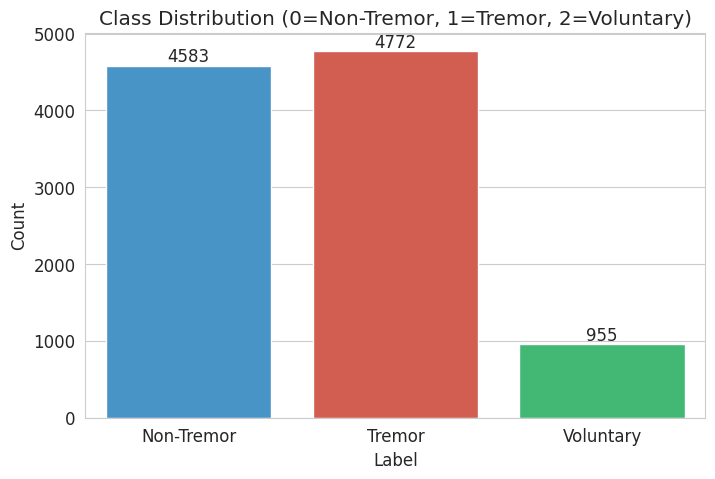

In [ ]:
print("\n" + "="*60)
print("BLOCK 1: Class Distribution (Non-Tremor / Tremor / Voluntary)")
print("="*60)
plot_class_distribution(y)


BLOCK 2: Feature Correlation Heatmap


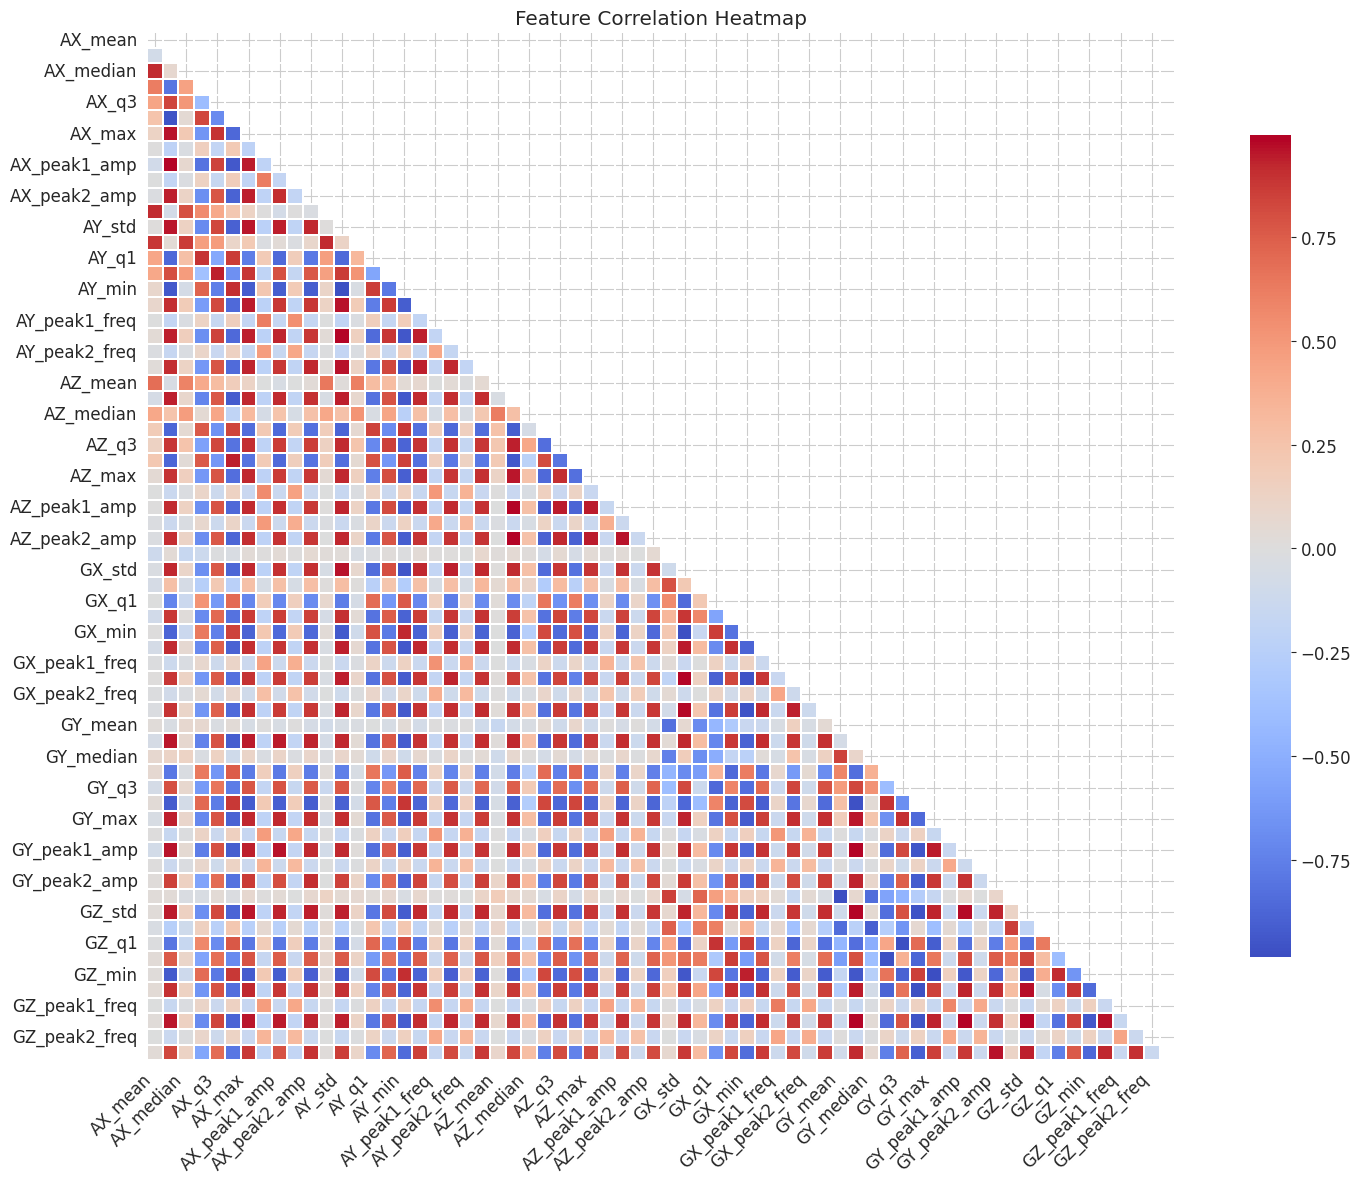

In [ ]:
print("\n" + "="*60)
print("BLOCK 2: Feature Correlation Heatmap")
print("="*60)
plot_correlation_heatmap(feature_df, "Feature Correlation Heatmap")


BLOCK 3: Key Features Boxplot (AY_std, GY_std, etc.)


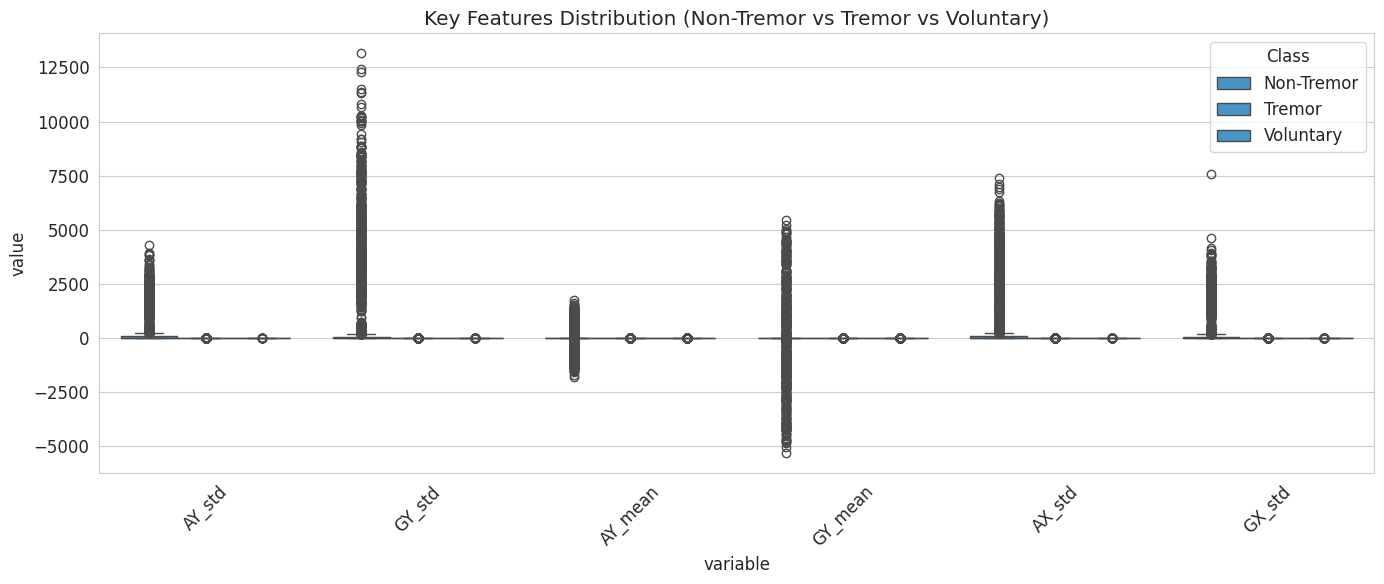

In [ ]:
print("\n" + "="*60)
print("BLOCK 3: Key Features Boxplot (AY_std, GY_std, etc.)")
print("="*60)
plot_key_features_boxplot(feature_df)


BLOCK 4: Frequency Features Boxplot


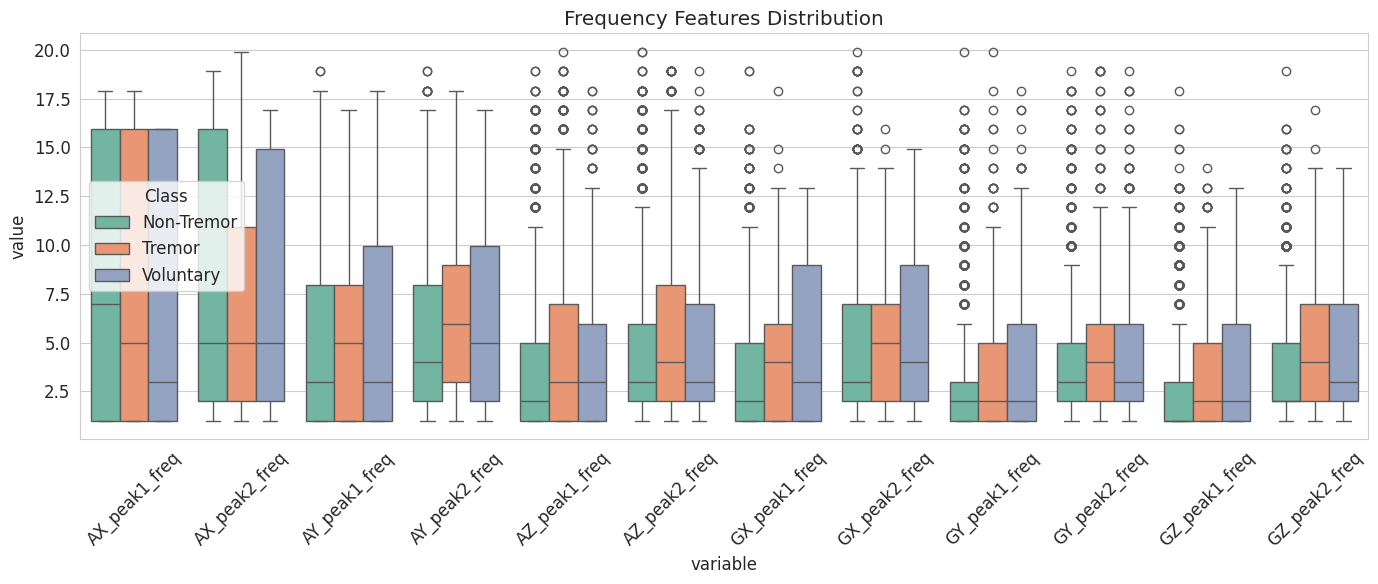

In [ ]:
print("\n" + "="*60)
print("BLOCK 4: Frequency Features Boxplot")
print("="*60)
plot_frequency_features(feature_df)


BLOCK 5: Dominant Frequency KDE (Peak1 Frequency)


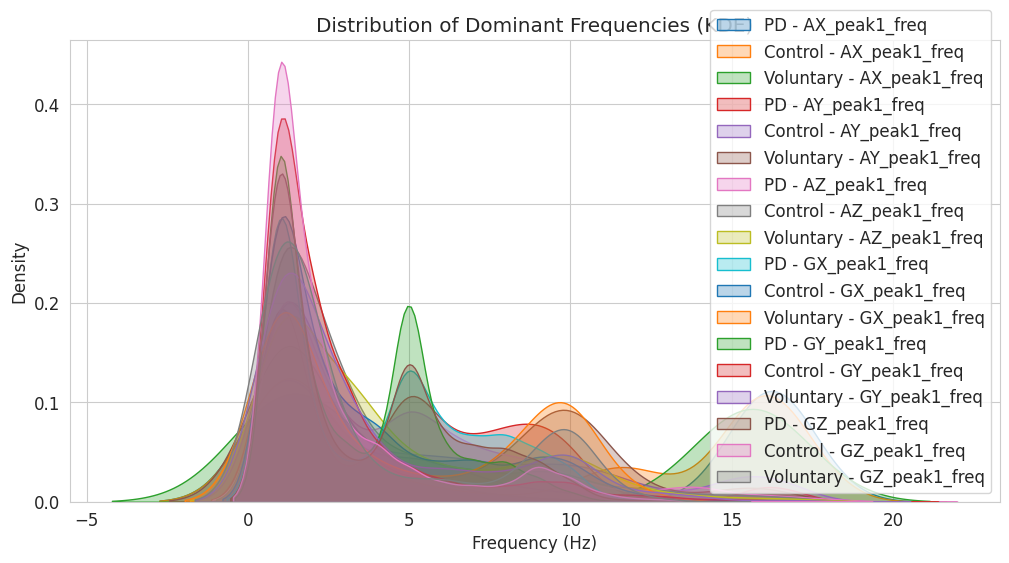

In [ ]:
print("\n" + "="*60)
print("BLOCK 5: Dominant Frequency KDE (Peak1 Frequency)")
print("="*60)
plot_dominant_freq_kde(feature_df)


BLOCK 6: Loading Raw Signals and Plotting Time Domain
Selected Parkinson file: Clean Dataset – Parkinson’s Group/ID07010201
Selected Control file: Clean Dataset – Control Group/ID01010100


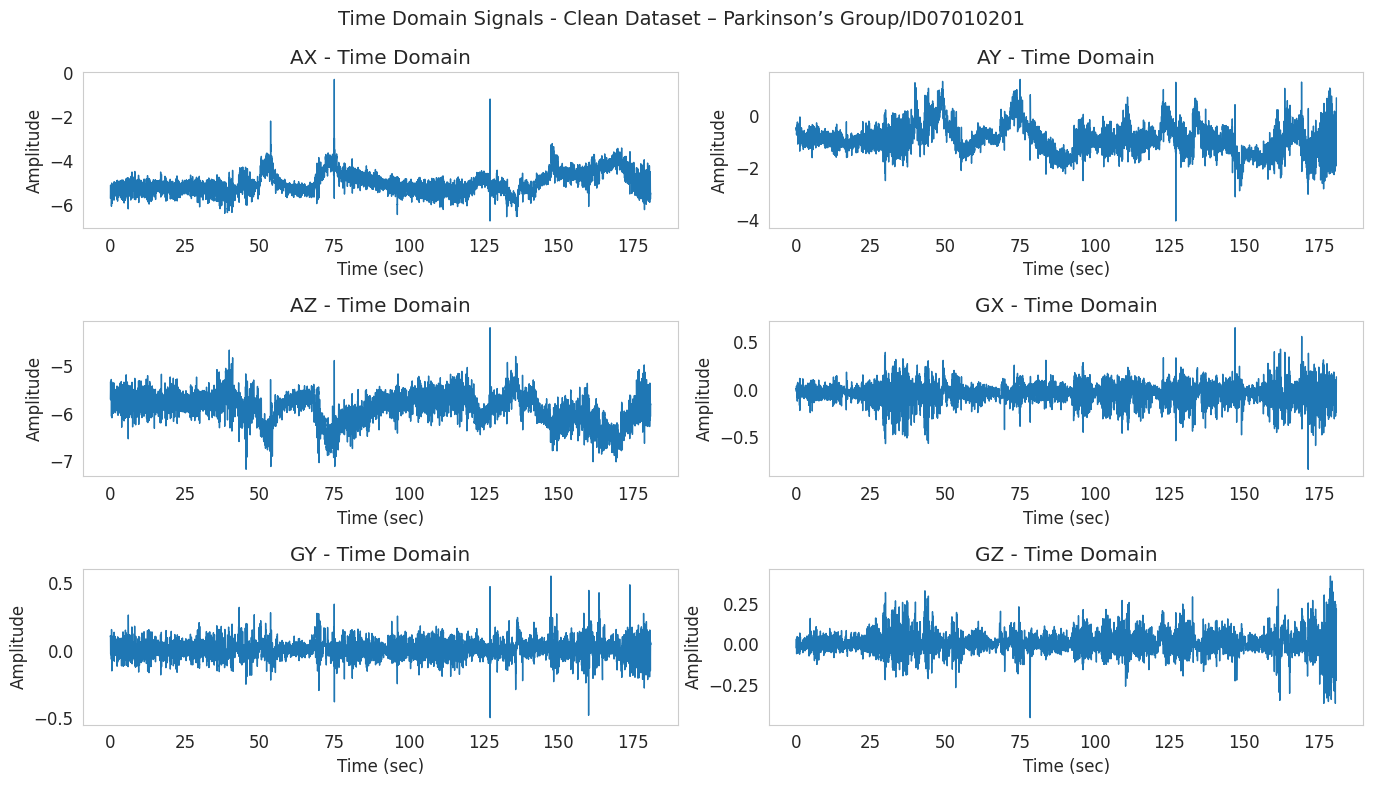

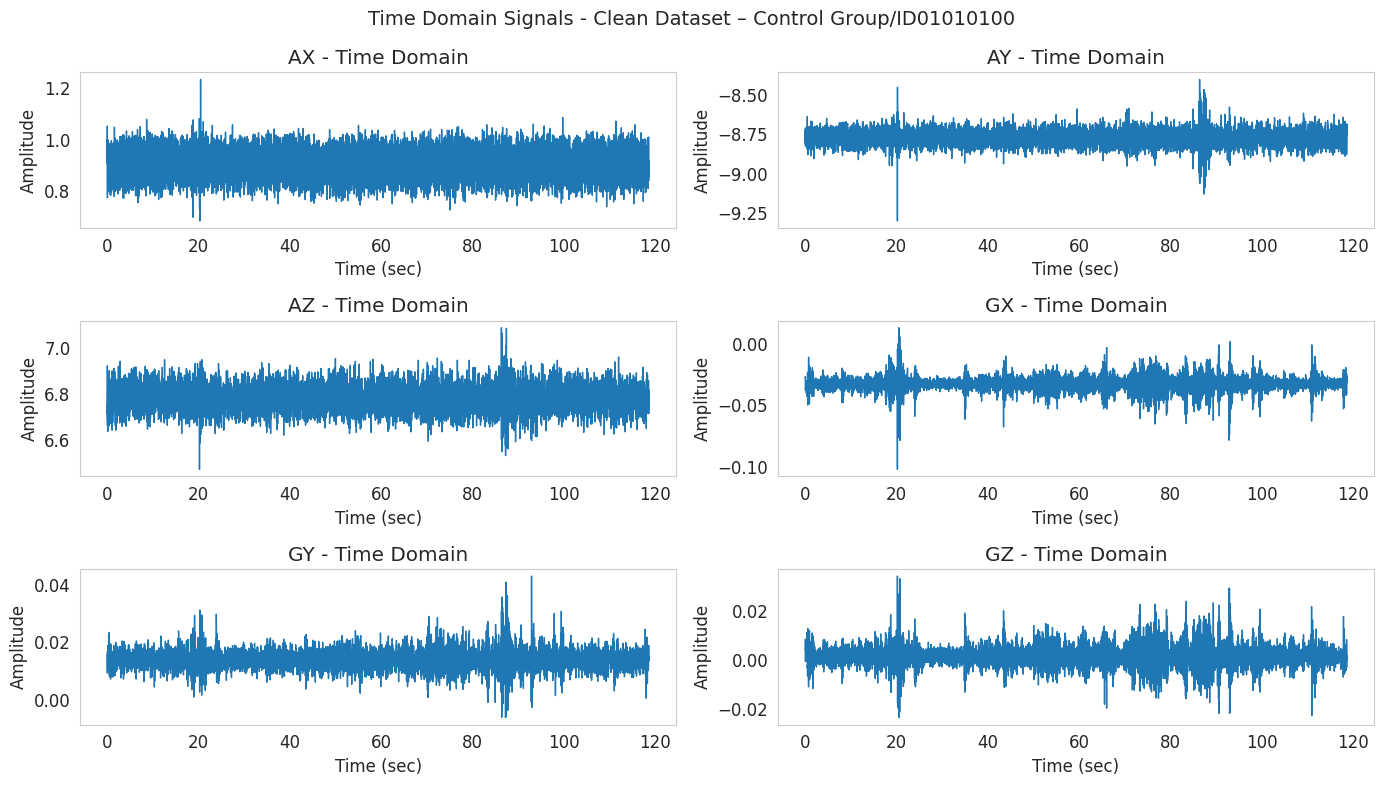

In [ ]:
print("\n" + "="*60)
print("BLOCK 6: Loading Raw Signals and Plotting Time Domain")
print("="*60)

# Load raw signals (only once, reuse for blocks 6-7)
raw_park = load_raw_signal(PARK_ZIP, 1)
raw_ctrl = load_raw_signal(CTRL_ZIP, 0)
raw_df = pd.concat([raw_park, raw_ctrl], ignore_index=True)

# Get first file IDs for Parkinson and Control
park_id = raw_df[raw_df["label"] == 1]["file_id"].unique()[0]
ctrl_id = raw_df[raw_df["label"] == 0]["file_id"].unique()[0]

print(f"Selected Parkinson file: {park_id}")
print(f"Selected Control file: {ctrl_id}")

# Plot time signals
plot_time_signals(raw_df, park_id)
plot_time_signals(raw_df, ctrl_id)


BLOCK 7: FFT for Parkinson and Signal Comparison (AY axis)


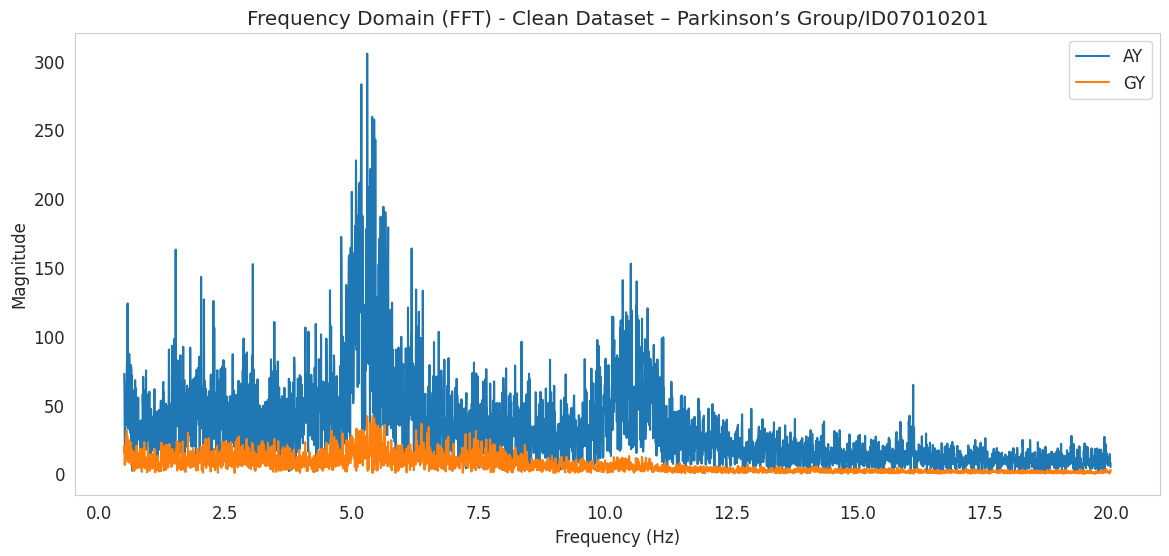

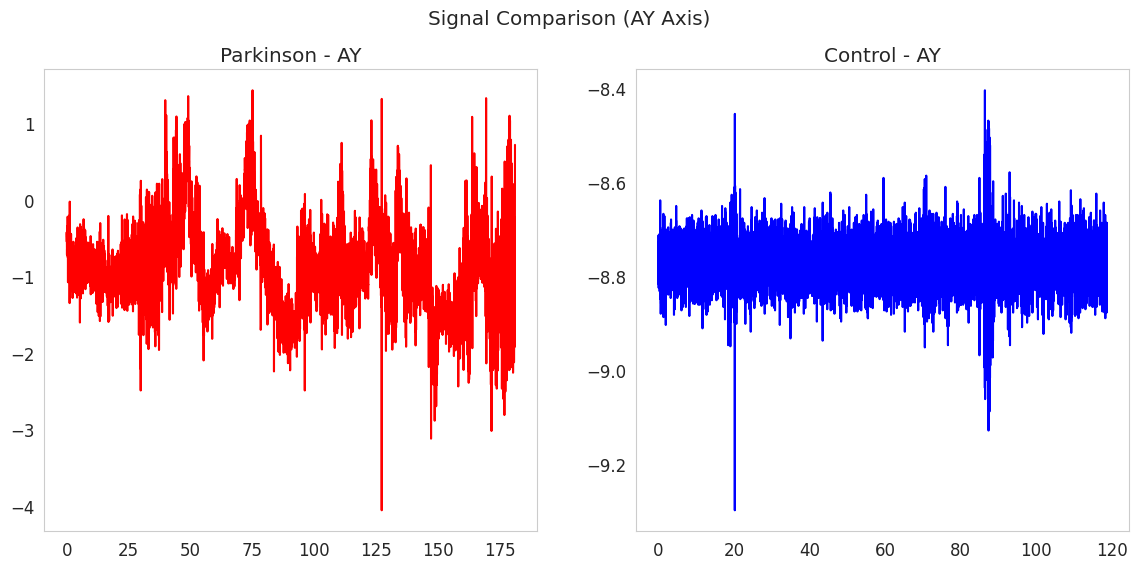

In [ ]:
print("\n" + "="*60)
print("BLOCK 7: FFT for Parkinson and Signal Comparison (AY axis)")
print("="*60)

plot_fft_signals(raw_df, park_id)
compare_signals(raw_df, park_id, ctrl_id)


BLOCK 8: Top 15 Features by Mutual Information


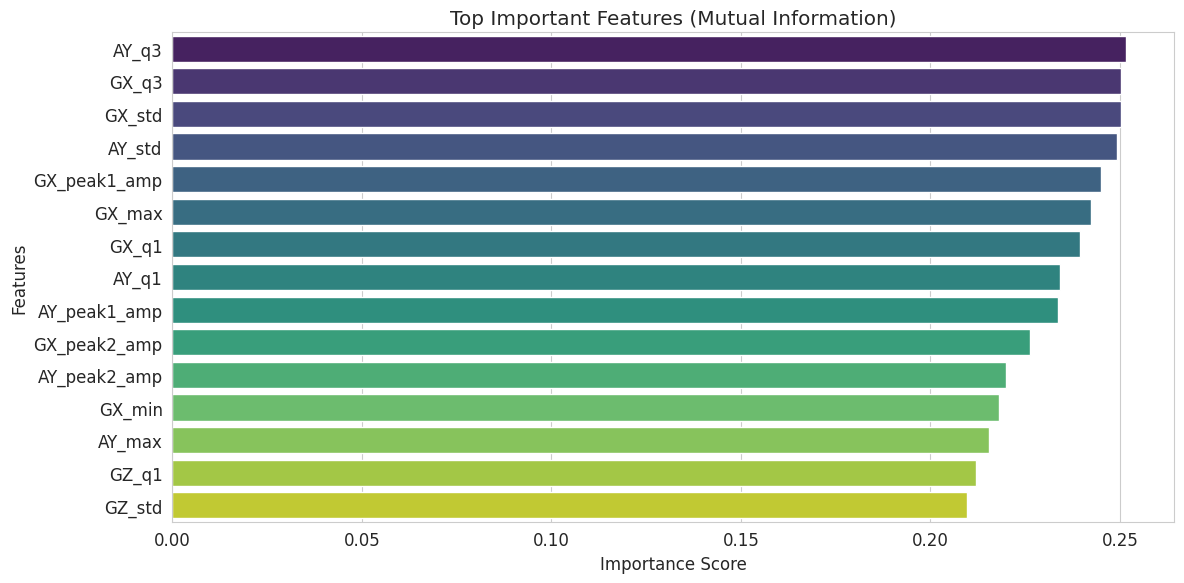

In [ ]:
print("\n" + "="*60)
print("BLOCK 8: Top 15 Features by Mutual Information")
print("="*60)
plot_top_features(feature_df, top_n=15)

# **Evaluation Functions**

In [6]:
def evaluate_model(model, X, y, groups, title="Model", training_time=None, history=None):
    y_true_all = np.full(len(y), -1)
    y_pred_all = np.full(len(y), -1)
    y_proba_all = None
    model_copy = None

    for train_idx, test_idx in cv.split(X, y, groups):
        X_train = X.iloc[train_idx] if hasattr(X, "iloc") else X[train_idx]
        X_test = X.iloc[test_idx] if hasattr(X, "iloc") else X[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]
        model_copy = clone_model(model)
        model_copy.fit(X_train, y_train)
        y_pred = model_copy.predict(X_test)
        if y_pred.ndim > 1:
            y_pred = y_pred.ravel()
        y_pred_all[test_idx] = y_pred
        y_true_all[test_idx] = y_test
        if hasattr(model_copy, "predict_proba"):
            proba = model_copy.predict_proba(X_test)
            if y_proba_all is None:
                y_proba_all = np.zeros((len(y), proba.shape[1]))
            y_proba_all[test_idx] = proba

    valid = (y_true_all != -1)
    y_true_all = y[valid]
    y_pred_all = y_pred_all[valid]
    y_proba_all = y_proba_all[valid] if y_proba_all is not None else None

    # ----- WINDOW LEVEL -----
    print(f"\n===== {title} | WINDOW LEVEL =====")
    print(classification_report(y_true_all, y_pred_all,
                                target_names=["Non-Tremor","Tremor","Voluntary"]))
    cm = confusion_matrix(y_true_all, y_pred_all)
    cm_percent = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=["Non-Tremor","Tremor","Voluntary"],
                yticklabels=["Non-Tremor","Tremor","Voluntary"])
    plt.title(f"{title} - Window Level Confusion Matrix (%)")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    if y_proba_all is not None:
        plot_multiclass_roc(y_true_all, y_proba_all, ["Non-Tremor","Tremor","Voluntary"], level="Window")
        plot_precision_recall_curves(y_true_all, y_proba_all, ["Non-Tremor","Tremor","Voluntary"], level="Window")
        acc, loss, precision, recall, f1, fnr = calculate_metrics(y_true_all, y_pred_all, y_proba_all)
        print(f"\n===== {title} | WINDOW LEVEL METRICS =====")
        print(f"Accuracy: {acc:.4f} | Log Loss: {loss:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | FNR: {fnr:.4f}")

    # ----- FILE LEVEL (Majority voting and average probabilities) -----
    vote_df = pd.DataFrame({"file_id": groups[valid], "y_true": y[valid], "y_pred": y_pred_all})
    if y_proba_all is not None:
        vote_df['proba'] = list(y_proba_all)
    file_pred = vote_df.groupby("file_id")["y_pred"].agg(lambda x: x.mode().iloc[0])
    file_true = vote_df.groupby("file_id")["y_true"].agg(lambda x: x.mode().iloc[0])
    if y_proba_all is not None:
        file_proba = vote_df.groupby("file_id")["proba"].apply(lambda x: np.mean(np.vstack(x), axis=0)).values
        file_proba = np.vstack(file_proba)
    else:
        file_proba = None

    print(f"\n===== {title} | FILE LEVEL =====")
    print(classification_report(file_true, file_pred,
                                target_names=["Non-Tremor","Tremor","Voluntary"]))
    cm_file = confusion_matrix(file_true, file_pred)
    cm_file_percent = cm_file.astype('float') / cm_file.sum(axis=1, keepdims=True) * 100
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_file_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=["Non-Tremor","Tremor","Voluntary"],
                yticklabels=["Non-Tremor","Tremor","Voluntary"])
    plt.title(f"{title} - File Level Confusion Matrix (%)")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    if file_proba is not None:
        plot_multiclass_roc(file_true, file_proba, ["Non-Tremor","Tremor","Voluntary"], level="File")
        plot_precision_recall_curves(file_true, file_proba, ["Non-Tremor","Tremor","Voluntary"], level="File")
        acc_f, loss_f, precision_f, recall_f, f1_f, fnr_f = calculate_metrics(file_true, file_pred, file_proba)
        print(f"\n===== {title} | FILE LEVEL METRICS =====")
        print(f"Accuracy: {acc_f:.4f} | Log Loss: {loss_f:.4f} | Precision: {precision_f:.4f} | Recall: {recall_f:.4f} | F1: {f1_f:.4f} | FNR: {fnr_f:.4f}")
    else:
        acc_f = accuracy_score(file_true, file_pred)
        precision_f = precision_score(file_true, file_pred, average='macro', zero_division=0)
        recall_f = recall_score(file_true, file_pred, average='macro', zero_division=0)
        f1_f = f1_score(file_true, file_pred, average='macro', zero_division=0)
        fnr_f = 1 - recall_f
        loss_f = np.nan
        print(f"\n===== {title} | FILE LEVEL METRICS (no probabilities) =====")
        print(f"Accuracy: {acc_f:.4f} | Precision: {precision_f:.4f} | Recall: {recall_f:.4f} | F1: {f1_f:.4f} | FNR: {fnr_f:.4f}")

    # Store metrics in global dictionary (both levels)
    if 'all_models_metrics' not in globals():
        global all_models_metrics
        all_models_metrics = {}
    all_models_metrics[f"{title}_window"] = {
        'Accuracy': acc, 'Loss': loss, 'Precision': precision,
        'Recall': recall, 'F1': f1, 'FNR': fnr,
        'Training Time': training_time
    }
    all_models_metrics[f"{title}_file"] = {
        'Accuracy': acc_f, 'Loss': loss_f, 'Precision': precision_f,
        'Recall': recall_f, 'F1': f1_f, 'FNR': fnr_f,
        'Training Time': training_time
    }

    if history is not None:
        plot_training_history(history, title, level="Window")

    X_file, y_file, _ = get_file_level_features(X, y, groups)
    if "MLP" in title or "LSTM" in title or "TabNet" in title or "CNN+LSTM" in title:
        X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(X_file, y_file, test_size=0.2, random_state=RANDOM_STATE)

        if "MLP" in title:
            def build_keras_mlp(input_dim):
                model = Sequential([
                    Input(shape=(input_dim,)),
                    Dense(256, activation='relu'), BatchNormalization(), Dropout(0.3),
                    Dense(128, activation='relu'), BatchNormalization(), Dropout(0.3),
                    Dense(64, activation='relu'), Dropout(0.2),
                    Dense(3, activation='softmax')
                ])
                model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
                return model
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_f)
            X_val_scaled = scaler.transform(X_val_f)
            file_model = build_keras_mlp(X_train_scaled.shape[1])
            hist_file = file_model.fit(X_train_scaled, y_train_f, validation_data=(X_val_scaled, y_val_f),
                                       epochs=100, batch_size=64, verbose=0,
                                       callbacks=[EarlyStopping(patience=10, restore_best_weights=True)])
            plot_training_history(hist_file, title, level="File")

        elif "LSTM" in title:
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_f)
            X_val_scaled = scaler.transform(X_val_f)
            X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
            X_val_reshaped = X_val_scaled.reshape(X_val_scaled.shape[0], 1, X_val_scaled.shape[1])
            model_file = Sequential([
                Input(shape=(1, X_train_scaled.shape[1])),
                LSTM(64), Dropout(0.3),
                Dense(32, activation='relu'), Dropout(0.3),
                Dense(3, activation='softmax')
            ])
            model_file.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
            hist_file = model_file.fit(X_train_reshaped, y_train_f, validation_data=(X_val_reshaped, y_val_f),
                                       epochs=50, batch_size=32, verbose=0,
                                       callbacks=[EarlyStopping(patience=5, restore_best_weights=True)])
            plot_training_history(hist_file, title, level="File")

        elif "TabNet" in title:
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_f)
            X_val_scaled = scaler.transform(X_val_f)
            mlp_file = MLPClassifier(hidden_layer_sizes=(100,50), activation='relu', max_iter=200,
                                     early_stopping=True, validation_fraction=0.2, random_state=RANDOM_STATE)
            mlp_file.fit(X_train_scaled, y_train_f)
            print(f"File-level training for {title} completed (no history plot available for TabNet/MLP).")

        elif "CNN+LSTM" in title:
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train_f)
            X_val_scaled = scaler.transform(X_val_f)
            X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
            X_val_reshaped = X_val_scaled.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)
            model_file = Sequential([
                Input(shape=(X_train_scaled.shape[1], 1)),
                Conv1D(64, 3, activation='relu', padding='same'), BatchNormalization(),
                Conv1D(32, 3, activation='relu', padding='same'), BatchNormalization(),
                MaxPooling1D(2, padding='same'),   # <-- أضف padding='same'
                LSTM(64, return_sequences=True), Dropout(0.3),
                LSTM(32), Dropout(0.3),
                Dense(64, activation='relu'),
                Dense(3, activation='softmax')
            ])
            model_file.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
            hist_file = model_file.fit(X_train_reshaped, y_train_f, validation_data=(X_val_reshaped, y_val_f),
                                       epochs=50, batch_size=32, verbose=0,
                                       callbacks=[EarlyStopping(patience=5, restore_best_weights=True)])
            plot_training_history(hist_file, title, level="File")

    return model_copy

In [7]:
def evaluate_cnn_lstm_model(model_builder, best_params, X, y, groups, title="CNN+LSTM", training_time=None):
    y_true_all = []
    y_pred_all = []
    y_proba_all = []
    all_groups = []

    for train_idx, test_idx in cv.split(X, y, groups):
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y[train_idx]
        y_test = y[test_idx]
        test_groups = groups[test_idx]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        X_train_scaled = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
        X_test_scaled = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

        model = model_builder(X_train_scaled.shape[1],
                              conv_filters=best_params["conv_filters"],
                              lstm_units=best_params["lstm_units"],
                              dropout=best_params["dropout"])
        model.fit(X_train_scaled, y_train, epochs=20, batch_size=64, verbose=0, validation_data=(X_test_scaled, y_test))

        y_pred = np.argmax(model.predict(X_test_scaled, verbose=0), axis=1)
        y_proba = model.predict(X_test_scaled, verbose=0)

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)
        y_proba_all.extend(y_proba)
        all_groups.extend(test_groups)

    y_true_all = np.array(y_true_all)
    y_pred_all = np.array(y_pred_all)
    y_proba_all = np.array(y_proba_all)
    all_groups = np.array(all_groups)

    # ----- WINDOW LEVEL -----
    print(f"\n===== {title} | WINDOW LEVEL =====")
    print(classification_report(y_true_all, y_pred_all,
                                target_names=["Non-Tremor","Tremor","Voluntary"]))
    cm = confusion_matrix(y_true_all, y_pred_all)
    cm_percent = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=["Non-Tremor","Tremor","Voluntary"],
                yticklabels=["Non-Tremor","Tremor","Voluntary"])
    plt.title(f"{title} - Window Level Confusion Matrix (%)")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    plot_multiclass_roc(y_true_all, y_proba_all, ["Non-Tremor","Tremor","Voluntary"], level="Window")
    plot_precision_recall_curves(y_true_all, y_proba_all, ["Non-Tremor","Tremor","Voluntary"], level="Window")
    acc, loss, precision, recall, f1, fnr = calculate_metrics(y_true_all, y_pred_all, y_proba_all)
    print(f"\n===== {title} | WINDOW LEVEL METRICS =====")
    print(f"Accuracy: {acc:.4f} | Log Loss: {loss:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f} | FNR: {fnr:.4f}")

    # ----- FILE LEVEL -----
    vote_df = pd.DataFrame({"file_id": all_groups, "y_true": y_true_all, "y_pred": y_pred_all})
    vote_df['proba'] = list(y_proba_all)
    file_pred = vote_df.groupby("file_id")["y_pred"].agg(lambda x: x.mode().iloc[0])
    file_true = vote_df.groupby("file_id")["y_true"].agg(lambda x: x.mode().iloc[0])
    file_proba = vote_df.groupby("file_id")["proba"].apply(lambda x: np.mean(np.vstack(x), axis=0)).values
    file_proba = np.vstack(file_proba)

    print(f"\n===== {title} | FILE LEVEL =====")
    print(classification_report(file_true, file_pred,
                                target_names=["Non-Tremor","Tremor","Voluntary"]))
    cm_file = confusion_matrix(file_true, file_pred)
    cm_file_percent = cm_file.astype('float') / cm_file.sum(axis=1, keepdims=True) * 100
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_file_percent, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=["Non-Tremor","Tremor","Voluntary"],
                yticklabels=["Non-Tremor","Tremor","Voluntary"])
    plt.title(f"{title} - File Level Confusion Matrix (%)")
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

    plot_multiclass_roc(file_true, file_proba, ["Non-Tremor","Tremor","Voluntary"], level="File")
    plot_precision_recall_curves(file_true, file_proba, ["Non-Tremor","Tremor","Voluntary"], level="File")
    acc_f, loss_f, precision_f, recall_f, f1_f, fnr_f = calculate_metrics(file_true, file_pred, file_proba)
    print(f"\n===== {title} | FILE LEVEL METRICS =====")
    print(f"Accuracy: {acc_f:.4f} | Log Loss: {loss_f:.4f} | Precision: {precision_f:.4f} | Recall: {recall_f:.4f} | F1: {f1_f:.4f} | FNR: {fnr_f:.4f}")

    if 'all_models_metrics' not in globals():
        global all_models_metrics
        all_models_metrics = {}
    all_models_metrics[f"{title}_window"] = {
        'Accuracy': acc, 'Loss': loss, 'Precision': precision,
        'Recall': recall, 'F1': f1, 'FNR': fnr,
        'Training Time': training_time
    }
    all_models_metrics[f"{title}_file"] = {
        'Accuracy': acc_f, 'Loss': loss_f, 'Precision': precision_f,
        'Recall': recall_f, 'F1': f1_f, 'FNR': fnr_f,
        'Training Time': training_time
    }

    X_file, y_file, _ = get_file_level_features(X, y, groups)
    X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(X_file, y_file, test_size=0.2, random_state=RANDOM_STATE)

    scaler_file = StandardScaler()
    X_train_scaled_f = scaler_file.fit_transform(X_train_f)
    X_val_scaled_f = scaler_file.transform(X_val_f)
    X_train_reshaped_f = X_train_scaled_f.reshape(X_train_scaled_f.shape[0], 1, X_train_scaled_f.shape[1])
    X_val_reshaped_f = X_val_scaled_f.reshape(X_val_scaled_f.shape[0], 1, X_val_scaled_f.shape[1])

    file_model = Sequential([
        Input(shape=(1, X_train_scaled_f.shape[1])),
        Conv1D(64, 3, activation='relu', padding='same'), BatchNormalization(),
        Conv1D(32, 3, activation='relu', padding='same'), BatchNormalization(),
        MaxPooling1D(2, padding='same'),
        LSTM(64, return_sequences=True), Dropout(0.3),
        LSTM(32), Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(3, activation='softmax')
    ])
    file_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    hist_file = file_model.fit(X_train_reshaped_f, y_train_f,
                               validation_data=(X_val_reshaped_f, y_val_f),
                               epochs=50, batch_size=32, verbose=0,
                               callbacks=[EarlyStopping(patience=5, restore_best_weights=True)])
    plot_training_history(hist_file, title, level="File")

In [8]:
def clone_model(model):
    """Return a fresh copy of the model (handles sklearn pipelines and custom deep models)."""

    # If it's a sklearn pipeline (has named_steps), try to clone normally
    if hasattr(model, 'named_steps'):
        try:
            return sklearn_clone(model)
        except Exception:
            pass
    # For LSTMClassifier3
    if hasattr(model, 'named_steps') and isinstance(model.named_steps.get('clf'), LSTMClassifier3):
        # Extract parameters and recreate
        clf = model.named_steps['clf']
        new_clf = LSTMClassifier3(units=clf.units, dropout=clf.dropout,
                                  batch_size=clf.batch_size, epochs=clf.epochs,
                                  optimizer=clf.optimizer)
        return Pipeline([('clf', new_clf)])

    # For TabNetWrapper3
    if hasattr(model, 'named_steps') and isinstance(model.named_steps.get('clf'), TabNetWrapper3):
        clf = model.named_steps['clf']
        new_clf = TabNetWrapper3(n_d=clf.n_d, n_a=clf.n_a, n_steps=clf.n_steps,
                                 gamma=clf.gamma, lr=clf.lr,
                                 max_epochs=clf.max_epochs, patience=clf.patience,
                                 seed=clf.seed)
        return Pipeline([('smote', model.named_steps.get('smote')), ('clf', new_clf)])


    # For MLP (sklearn pipeline), just clone
    try:
        return sklearn_clone(model)
    except:
        return model

In [9]:
def plot_multiclass_roc(y_true, y_pred_proba, class_names, level="Window"):
    """Plot ROC curves for each class (one-vs-rest)"""
    y_bin = label_binarize(y_true, classes=[0,1,2])
    n_classes = y_bin.shape[1]
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    plt.figure(figsize=(8,6))
    colors = ['green', 'red', 'blue']
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f'{class_names[i]} (AUC = {roc_auc[i]:.2f})')
    plt.plot([0,1],[0,1], 'k--', lw=1)
    plt.xlim([0.0,1.0])
    plt.ylim([0.0,1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Multiclass ROC Curves ({level} Level)')
    plt.legend(loc="lower right")
    plt.show()

In [10]:
def calculate_metrics(y_true, y_pred, y_proba):
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    fnr = 1 - recall
    loss = log_loss(y_true, y_proba, labels=[0,1,2])
    return acc, loss, precision, recall, f1, fnr

def plot_precision_recall_curves(y_true, y_proba, class_names, level="Window"):
    """Plot Precision-Recall curves for each class (one-vs-rest)"""
    n_classes = 3
    plt.figure(figsize=(8,6))
    for i in range(n_classes):
        precision_curve, recall_curve, _ = precision_recall_curve(y_true == i, y_proba[:, i])
        ap_score = average_precision_score(y_true == i, y_proba[:, i])
        plt.plot(recall_curve, precision_curve, lw=2, label=f'{class_names[i]} (AP = {ap_score:.2f})')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curves ({level} Level)')
    plt.legend(loc="lower left")
    plt.grid(True)
    plt.show()

def plot_training_history(history, title="Model", level="Window"):
    """Plot training and validation loss & accuracy if history contains them"""
    if history is None:
        return
    fig, axes = plt.subplots(1, 2, figsize=(14,4))
    # Loss
    if 'loss' in history.history:
        axes[0].plot(history.history['loss'], label='Train Loss')
        if 'val_loss' in history.history:
            axes[0].plot(history.history['val_loss'], label='Validation Loss')
        axes[0].set_title(f'{title} - Loss ({level} Level)')
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].legend()
    # Accuracy
    if 'accuracy' in history.history:
        axes[1].plot(history.history['accuracy'], label='Train Accuracy')
        if 'val_accuracy' in history.history:
            axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
        axes[1].set_title(f'{title} - Accuracy ({level} Level)')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].legend()
    plt.tight_layout()
    plt.show()

def get_file_level_features(X_window, y_window, groups_window):
    """
    Aggregate window-level features to file-level by taking mean of features per file.
    Returns:
        X_file: array of shape (n_files, n_features)
        y_file: array of shape (n_files,)
        file_ids: list of unique file IDs
    """
    df = pd.DataFrame(X_window)
    df['y'] = y_window
    df['group'] = groups_window
    # Group by file_id (group) and calculate mean of all features
    X_file = df.groupby('group').mean().drop(['y'], axis=1).values
    y_file = df.groupby('group')['y'].agg(lambda x: x.mode().iloc[0]).values
    file_ids = df.groupby('group').apply(lambda x: x.name).tolist()
    return X_file, y_file, file_ids

# **Randomized Search for ML Hyper-parameters**

In [11]:
def train_and_evaluate(model_pipeline, param_grid, X, y, groups, title):
    start_time = time.time()
    search = RandomizedSearchCV(model_pipeline, param_grid, n_iter=15,
                                scoring='f1_macro', cv=cv, random_state=RANDOM_STATE,
                                n_jobs=-1, verbose=1)
    search.fit(X, y, groups=groups)
    elapsed = time.time() - start_time
    print(f"Training time for {title}: {elapsed:.2f} seconds")
    best_est = search.best_estimator_
    evaluate_model(best_est, X, y, groups, title=title, training_time=elapsed)
    return best_est

# **Machine Learning Models**

Fitting 4 folds for each of 15 candidates, totalling 60 fits
Training time for LightGBM : 212.24 seconds

===== LightGBM  | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.84      0.87      0.86      4583
      Tremor       0.90      0.86      0.88      4772
   Voluntary       0.74      0.78      0.76       955

    accuracy                           0.86     10310
   macro avg       0.83      0.84      0.83     10310
weighted avg       0.86      0.86      0.86     10310



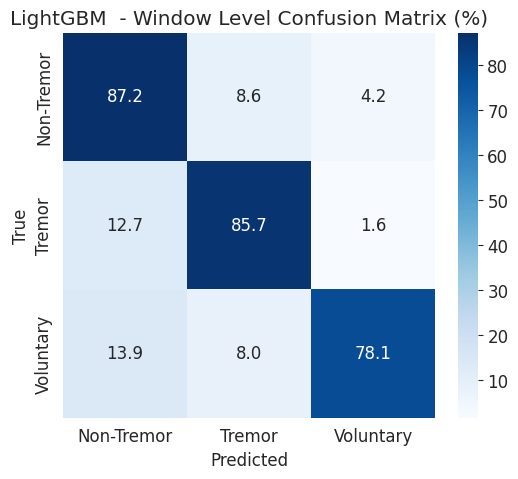

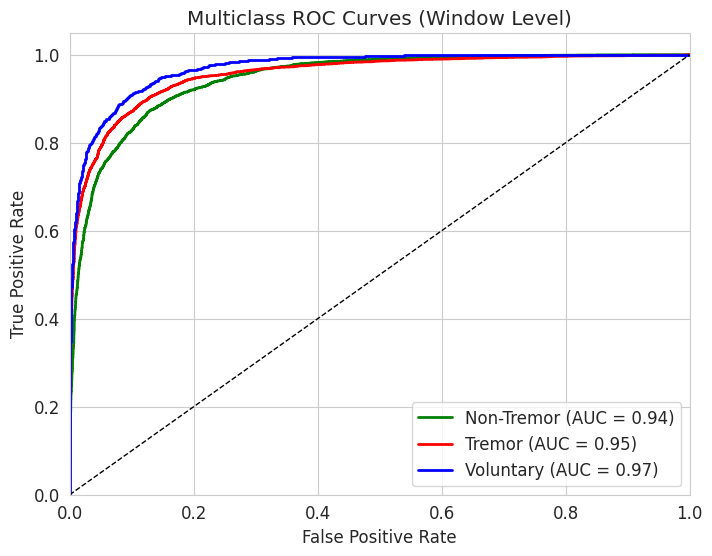

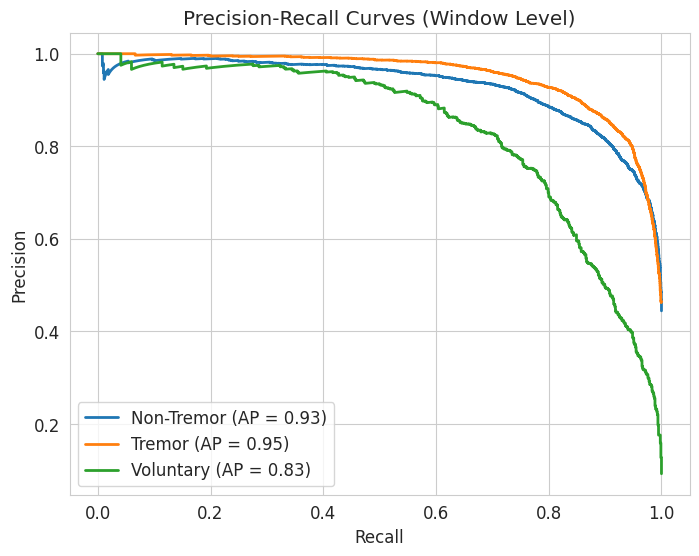


===== LightGBM  | WINDOW LEVEL METRICS =====
Accuracy: 0.8568 | Log Loss: 0.5674 | Precision: 0.8258 | Recall: 0.8369 | F1: 0.8309 | FNR: 0.1631

===== LightGBM  | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.96      0.97      0.97        71
      Tremor       0.93      0.93      0.93        29
   Voluntary       1.00      0.94      0.97        16

    accuracy                           0.96       116
   macro avg       0.96      0.95      0.95       116
weighted avg       0.96      0.96      0.96       116



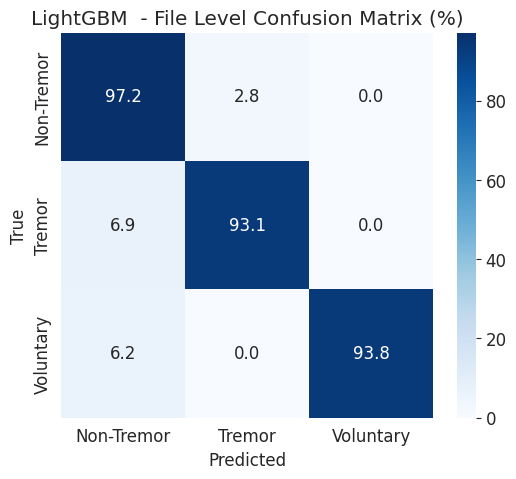

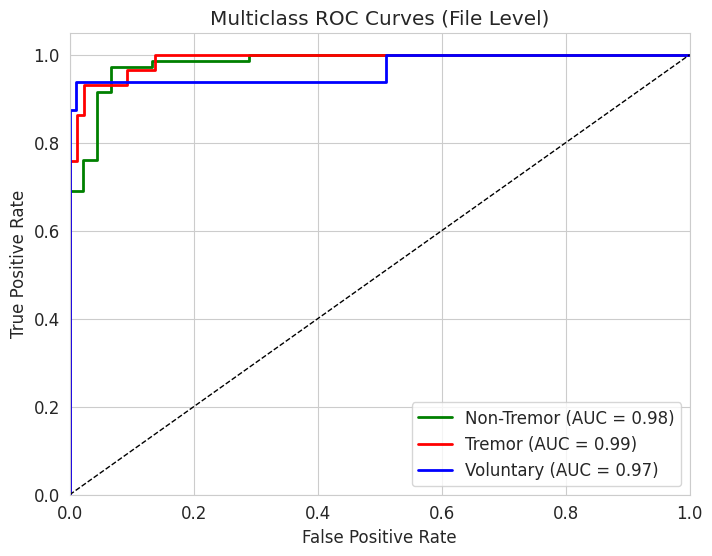

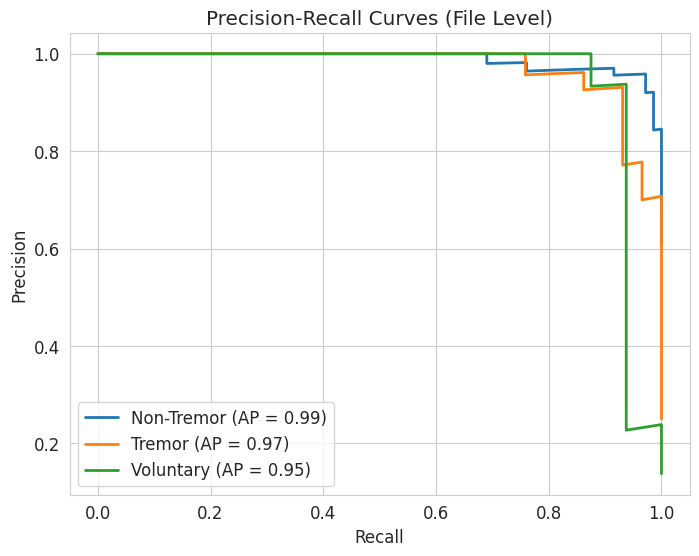


===== LightGBM  | FILE LEVEL METRICS =====
Accuracy: 0.9569 | Log Loss: 0.2408 | Precision: 0.9631 | Recall: 0.9468 | F1: 0.9546 | FNR: 0.0532


In [ ]:
# LightGBM
lgb_pipe = Pipeline([("smote", SMOTE(random_state=RANDOM_STATE)),
                     ("clf", LGBMClassifier(random_state=RANDOM_STATE, verbose=-1))])
lgb_params = {"clf__n_estimators": [100,200,300], "clf__learning_rate": [0.01,0.05,0.1],
              "clf__num_leaves": [15,31,63], "clf__max_depth": [-1,5,10]}
best_lgb = train_and_evaluate(lgb_pipe, lgb_params, X, y, groups, "LightGBM ")

Fitting 4 folds for each of 15 candidates, totalling 60 fits
Training time for CatBoost: 527.00 seconds

===== CatBoost | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.82      0.83      0.83      4583
      Tremor       0.89      0.83      0.86      4772
   Voluntary       0.62      0.78      0.69       955

    accuracy                           0.83     10310
   macro avg       0.78      0.81      0.79     10310
weighted avg       0.83      0.83      0.83     10310



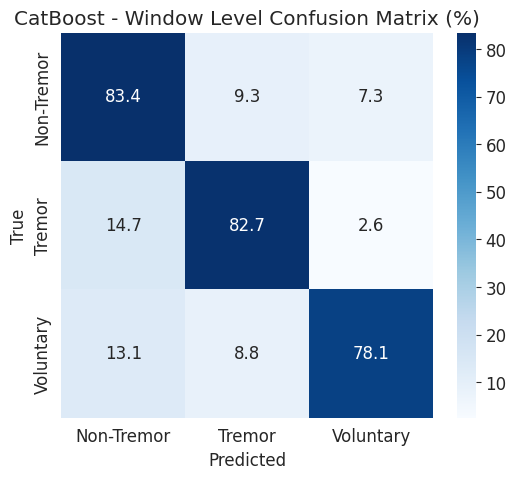

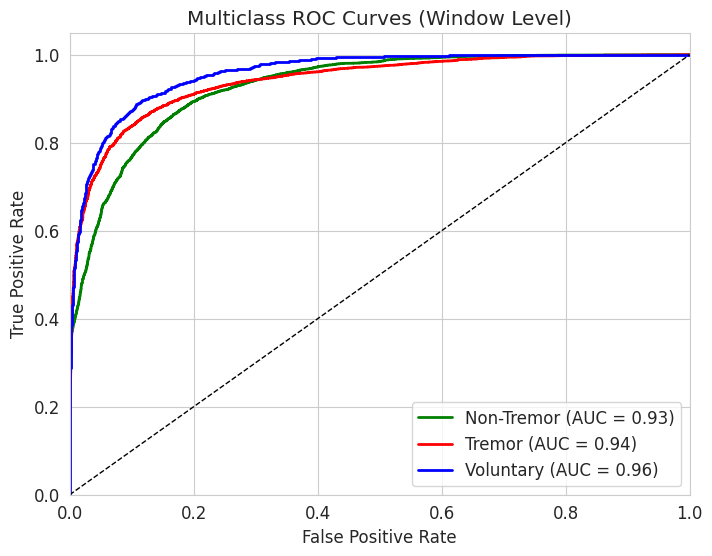

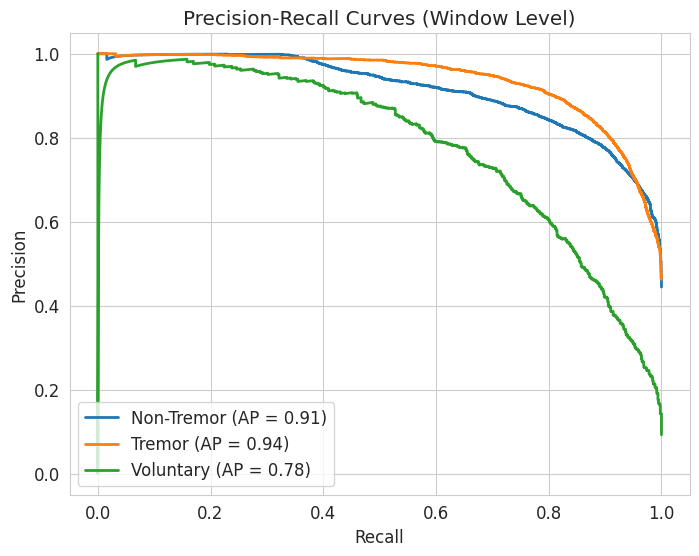


===== CatBoost | WINDOW LEVEL METRICS =====
Accuracy: 0.8260 | Log Loss: 0.4497 | Precision: 0.7757 | Recall: 0.8141 | F1: 0.7915 | FNR: 0.1859

===== CatBoost | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.96      0.96      0.96        71
      Tremor       0.90      0.93      0.92        29
   Voluntary       0.93      0.88      0.90        16

    accuracy                           0.94       116
   macro avg       0.93      0.92      0.93       116
weighted avg       0.94      0.94      0.94       116



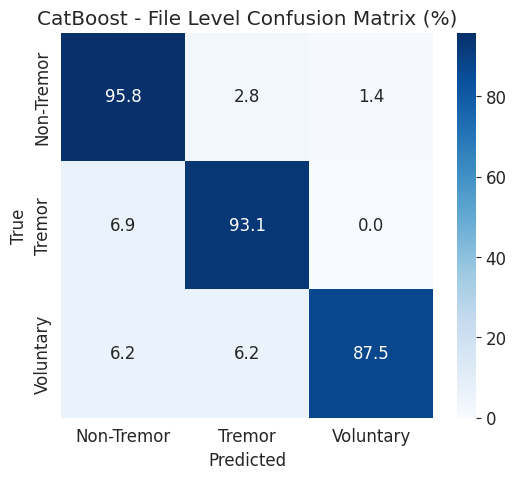

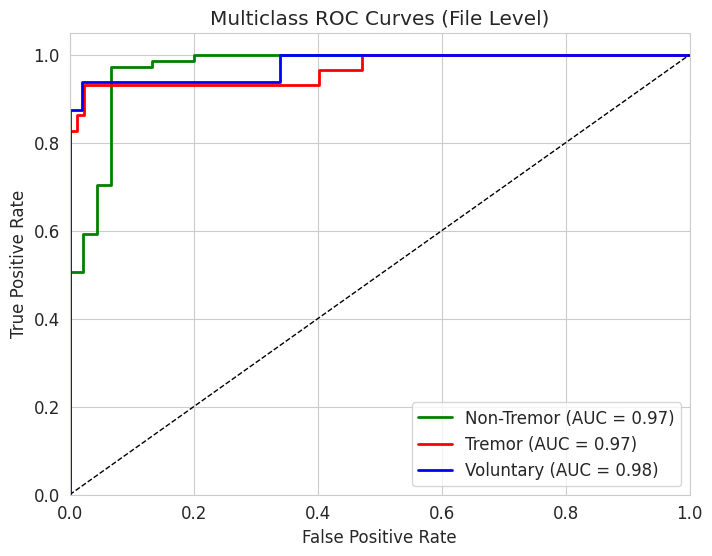

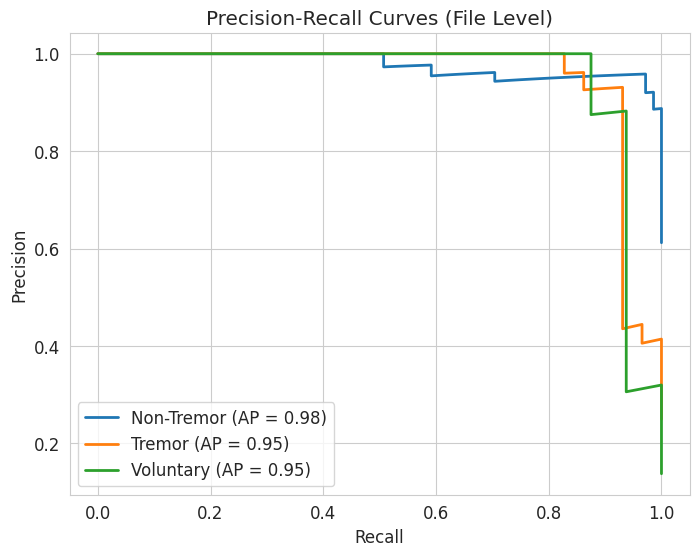


===== CatBoost | FILE LEVEL METRICS =====
Accuracy: 0.9397 | Log Loss: 0.3407 | Precision: 0.9304 | Recall: 0.9213 | F1: 0.9254 | FNR: 0.0787


In [ ]:
# CatBoost
cat_pipe = Pipeline([("smote", SMOTE(random_state=RANDOM_STATE)),
                     ("clf", CatBoostClassifier(random_state=RANDOM_STATE, verbose=0))])
cat_params = {"clf__iterations": [100,200,300], "clf__learning_rate": [0.01,0.05,0.1],
              "clf__depth": [4,6,8]}
best_cat = train_and_evaluate(cat_pipe, cat_params, X, y, groups, "CatBoost")

Fitting 4 folds for each of 15 candidates, totalling 60 fits
Training time for XGBoost (3-class): 248.96 seconds

===== XGBoost (3-class) | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.83      0.85      0.84      4583
      Tremor       0.89      0.84      0.86      4772
   Voluntary       0.65      0.77      0.71       955

    accuracy                           0.84     10310
   macro avg       0.79      0.82      0.80     10310
weighted avg       0.84      0.84      0.84     10310



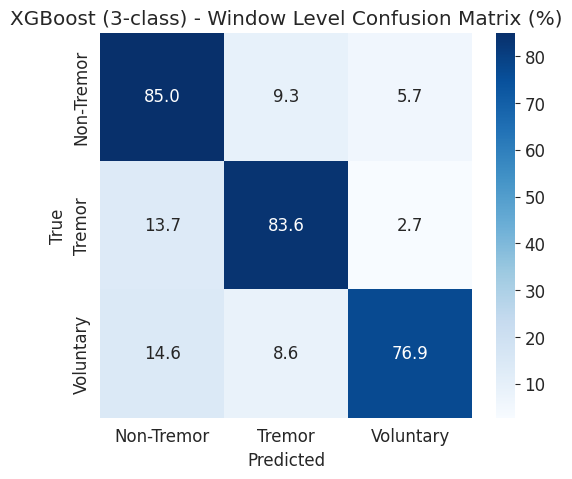

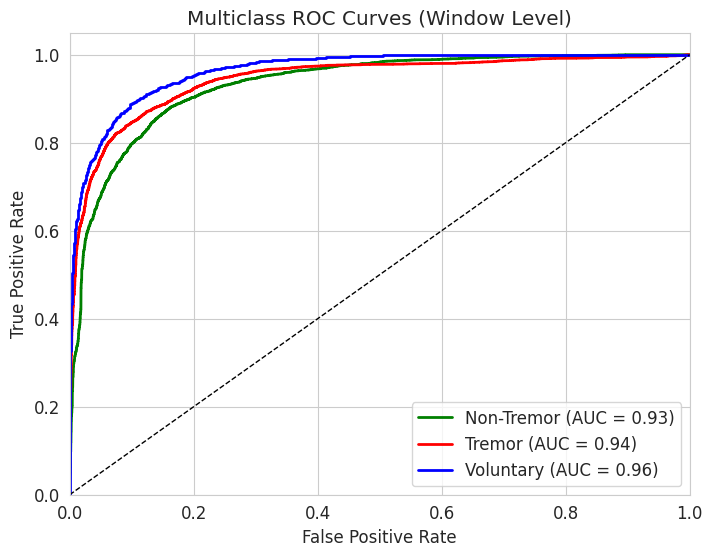

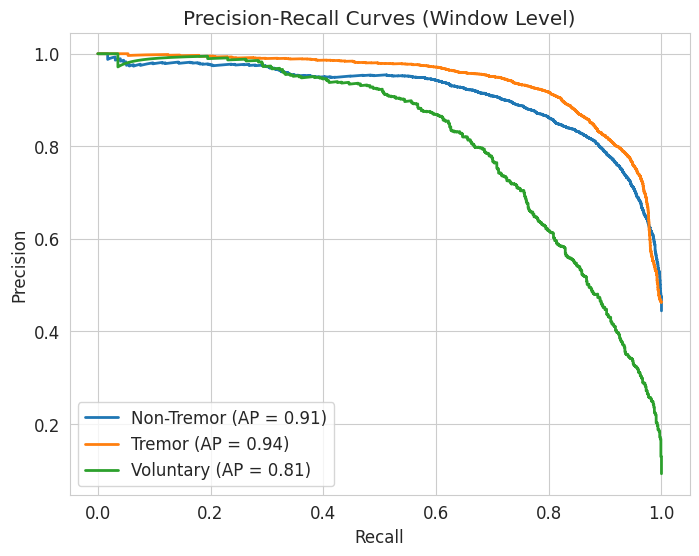


===== XGBoost (3-class) | WINDOW LEVEL METRICS =====
Accuracy: 0.8360 | Log Loss: 0.4745 | Precision: 0.7899 | Recall: 0.8182 | F1: 0.8022 | FNR: 0.1818

===== XGBoost (3-class) | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.96      0.96      0.96        71
      Tremor       0.93      0.93      0.93        29
   Voluntary       0.94      0.94      0.94        16

    accuracy                           0.95       116
   macro avg       0.94      0.94      0.94       116
weighted avg       0.95      0.95      0.95       116



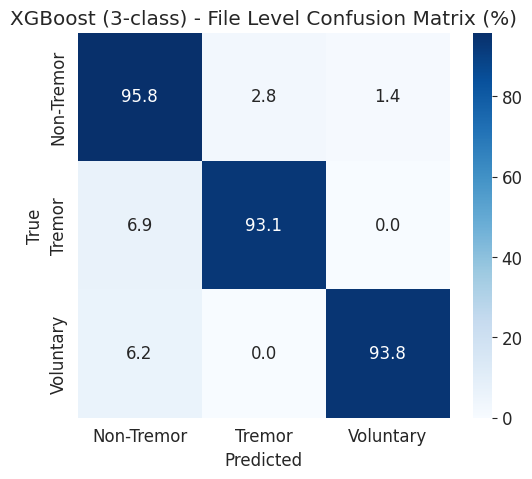

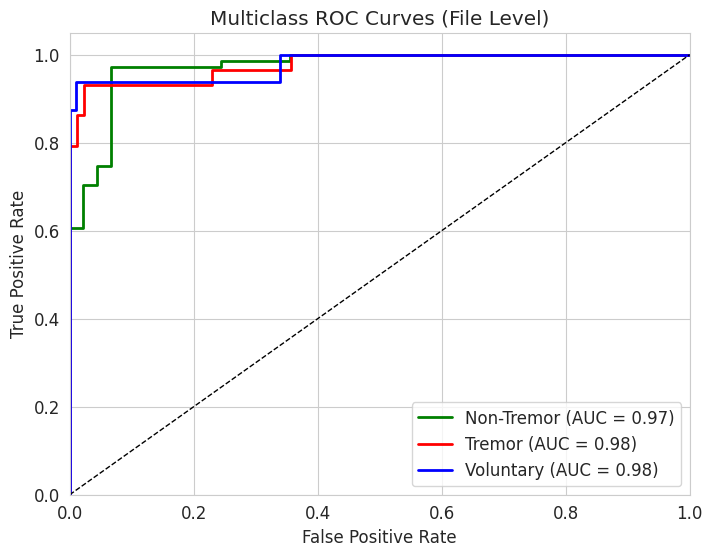

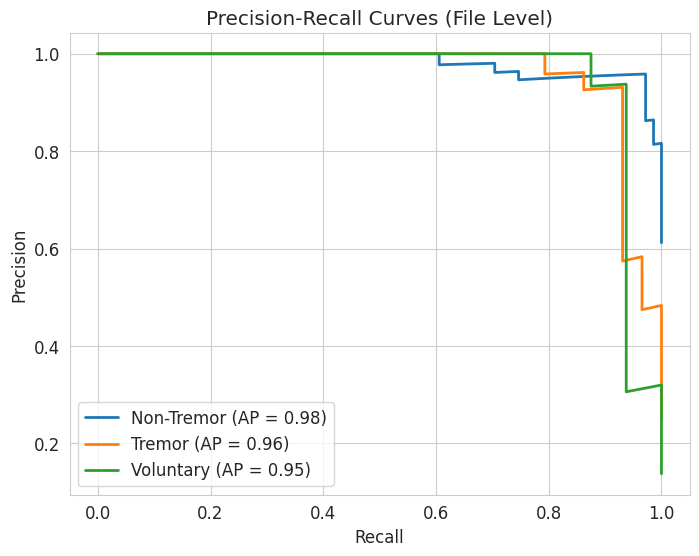


===== XGBoost (3-class) | FILE LEVEL METRICS =====
Accuracy: 0.9483 | Log Loss: 0.2842 | Precision: 0.9421 | Recall: 0.9421 | F1: 0.9421 | FNR: 0.0579


In [ ]:
# XGBoost
xgb_pipe = Pipeline([("smote", SMOTE(random_state=RANDOM_STATE)),
                     ("clf", XGBClassifier(random_state=RANDOM_STATE, eval_metric='logloss'))])
xgb_params = {"clf__n_estimators": [100,200,300], "clf__learning_rate": [0.01,0.05,0.1],
              "clf__max_depth": [3,5,7]}
best_xgb = train_and_evaluate(xgb_pipe, xgb_params, X, y, groups, "XGBoost (3-class)")

Fitting 4 folds for each of 9 candidates, totalling 36 fits
Training time for SVM: 1027.92 seconds

===== SVM | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.74      0.64      0.68      4583
      Tremor       0.76      0.63      0.69      4772
   Voluntary       0.19      0.48      0.27       955

    accuracy                           0.62     10310
   macro avg       0.56      0.58      0.55     10310
weighted avg       0.70      0.62      0.65     10310



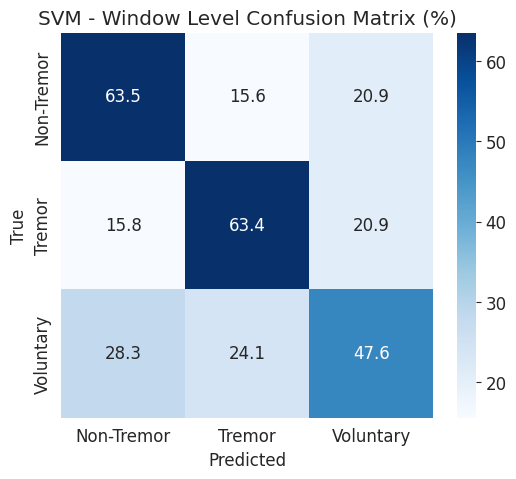

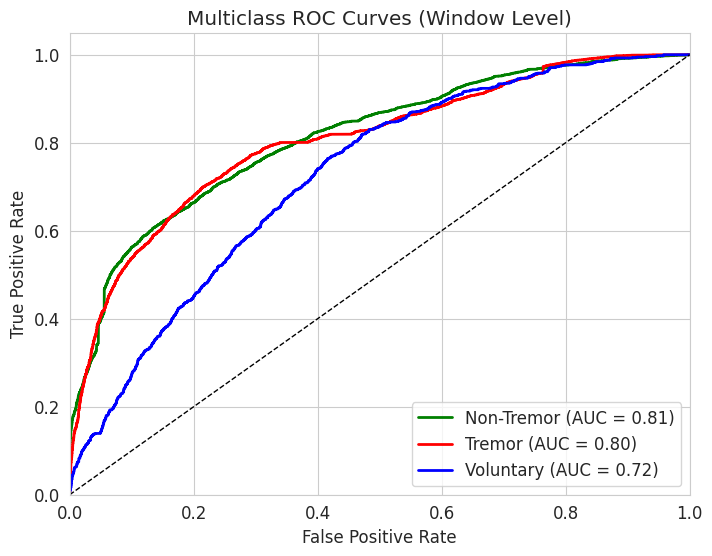

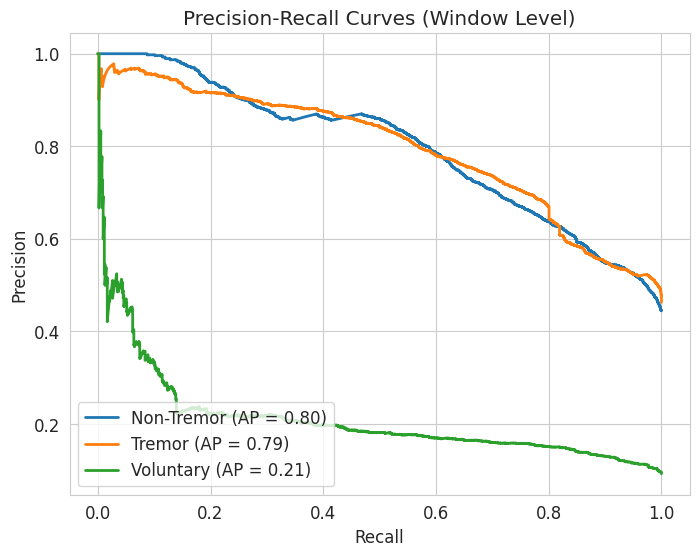


===== SVM | WINDOW LEVEL METRICS =====
Accuracy: 0.6199 | Log Loss: 0.8657 | Precision: 0.5638 | Recall: 0.5818 | F1: 0.5488 | FNR: 0.4182

===== SVM | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.90      0.75      0.82        71
      Tremor       0.84      0.90      0.87        29
   Voluntary       0.31      0.50      0.38        16

    accuracy                           0.75       116
   macro avg       0.68      0.71      0.69       116
weighted avg       0.80      0.75      0.77       116



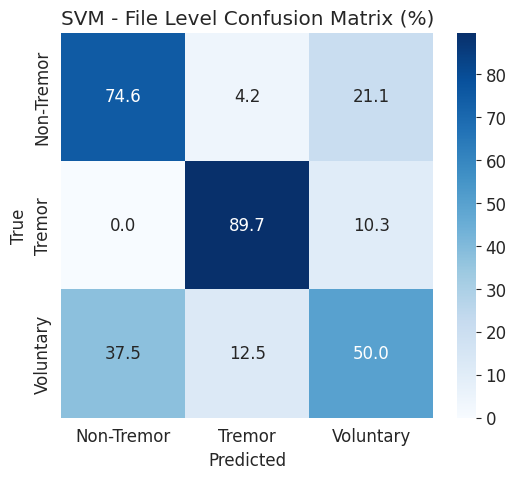

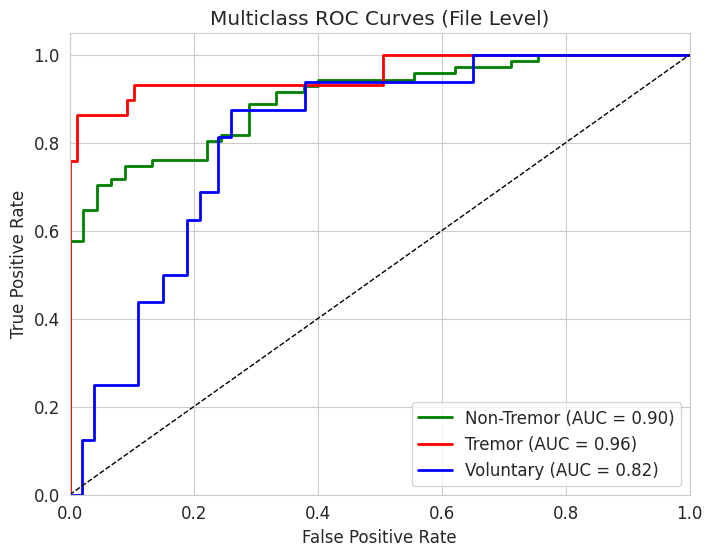

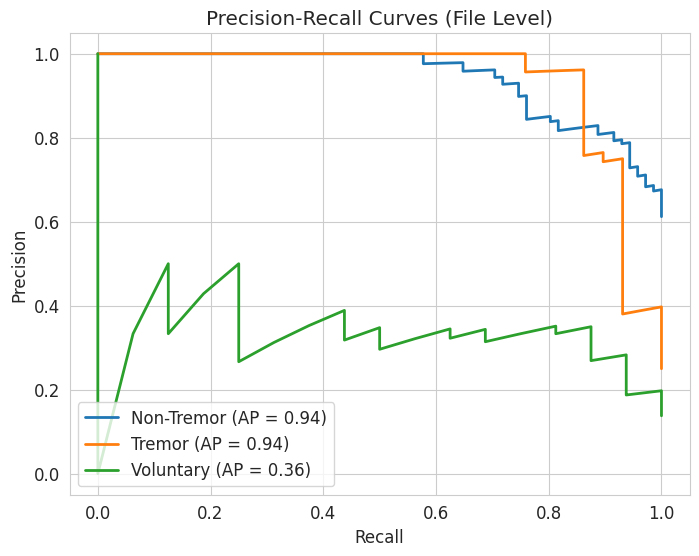


===== SVM | FILE LEVEL METRICS =====
Accuracy: 0.7500 | Log Loss: 0.6500 | Precision: 0.6816 | Recall: 0.7143 | F1: 0.6877 | FNR: 0.2857


In [ ]:
# SVM
svm_pipe = Pipeline([("scaler", StandardScaler()), ("smote", SMOTE(random_state=RANDOM_STATE)),
                     ("clf", SVC(probability=True))])
svm_params = {"clf__C": [0.1,1,10], "clf__gamma": ['scale',0.1,0.01]}
best_svm = train_and_evaluate(svm_pipe, svm_params, X, y, groups, "SVM")

Fitting 4 folds for each of 9 candidates, totalling 36 fits
Training time for Random Forest: 427.84 seconds

===== Random Forest | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.83      0.84      0.84      4583
      Tremor       0.87      0.84      0.86      4772
   Voluntary       0.69      0.74      0.71       955

    accuracy                           0.83     10310
   macro avg       0.80      0.81      0.80     10310
weighted avg       0.84      0.83      0.83     10310



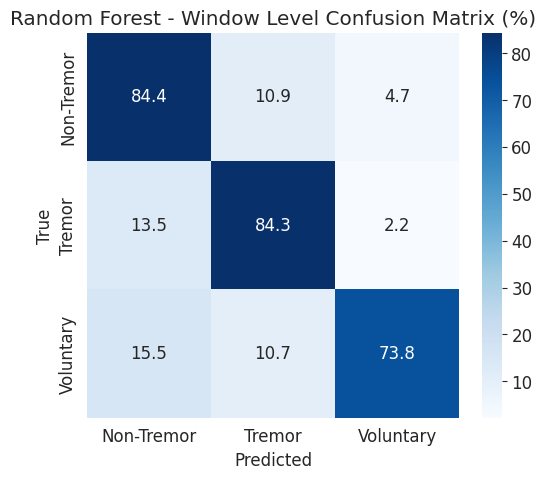

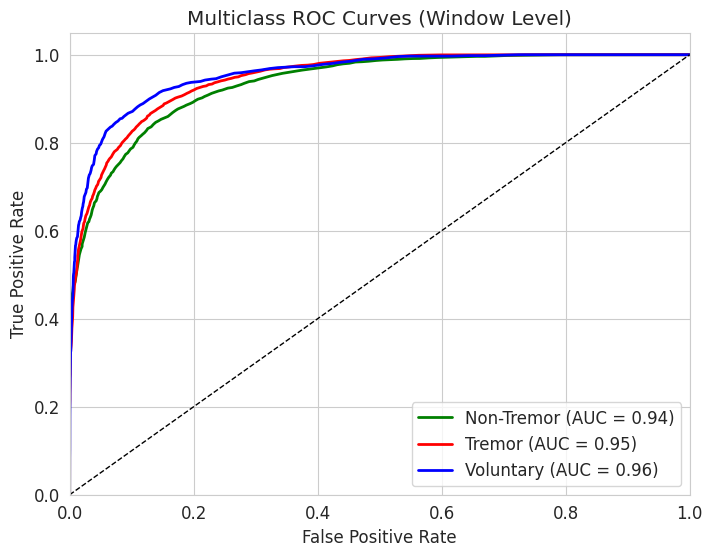

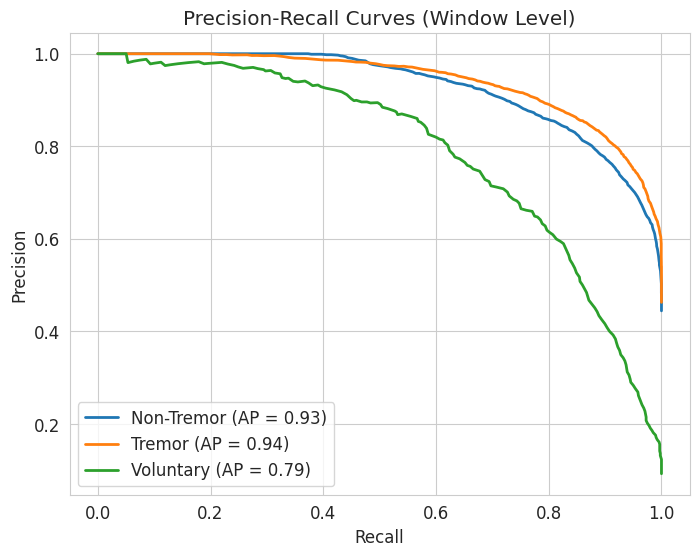


===== Random Forest | WINDOW LEVEL METRICS =====
Accuracy: 0.8335 | Log Loss: 0.4480 | Precision: 0.7952 | Recall: 0.8082 | F1: 0.8013 | FNR: 0.1918

===== Random Forest | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.96      0.94      0.95        71
      Tremor       0.84      0.93      0.89        29
   Voluntary       1.00      0.88      0.93        16

    accuracy                           0.93       116
   macro avg       0.93      0.92      0.92       116
weighted avg       0.93      0.93      0.93       116



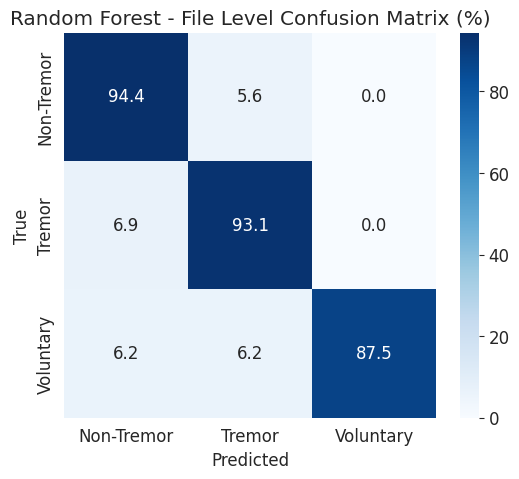

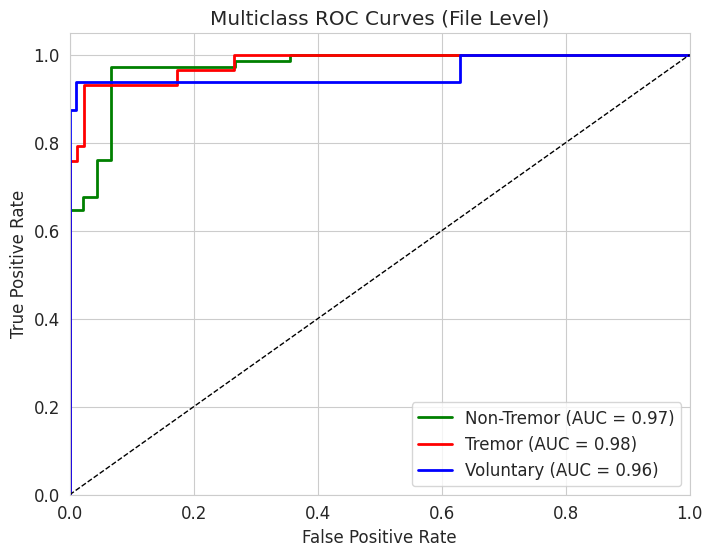

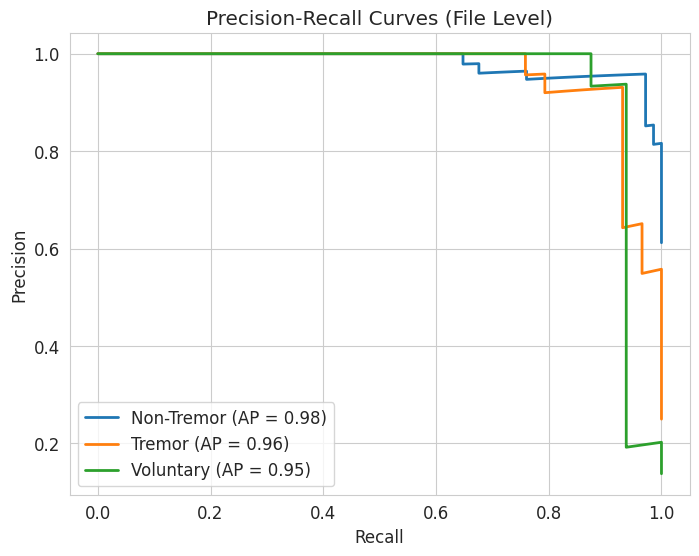


===== Random Forest | FILE LEVEL METRICS =====
Accuracy: 0.9310 | Log Loss: 0.4029 | Precision: 0.9336 | Recall: 0.9166 | F1: 0.9230 | FNR: 0.0834


In [ ]:
# Random Forest
rf_pipe = Pipeline([("smote", SMOTE(random_state=RANDOM_STATE)),
                    ("clf", RandomForestClassifier(random_state=RANDOM_STATE))])
rf_params = {"clf__n_estimators": [100,200,300], "clf__max_depth": [None,10,20]}
best_rf = train_and_evaluate(rf_pipe, rf_params, X, y, groups, "Random Forest")

Fitting 4 folds for each of 8 candidates, totalling 32 fits
Training time for KNN: 8.09 seconds

===== KNN | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.71      0.61      0.66      4583
      Tremor       0.76      0.62      0.68      4772
   Voluntary       0.20      0.50      0.28       955

    accuracy                           0.61     10310
   macro avg       0.56      0.58      0.54     10310
weighted avg       0.69      0.61      0.64     10310



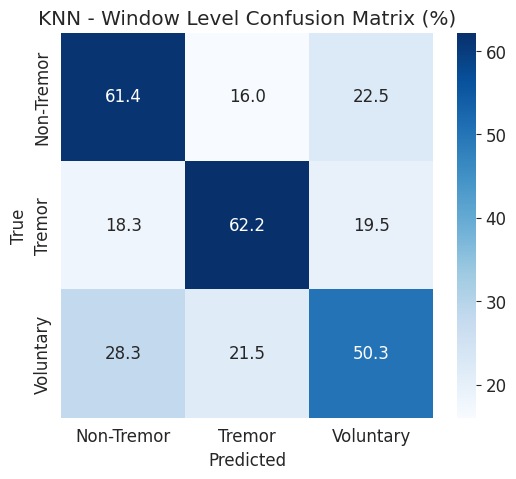

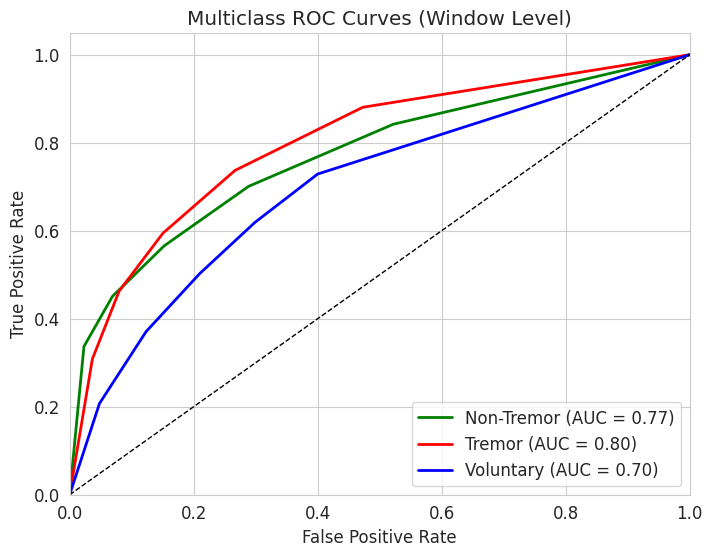

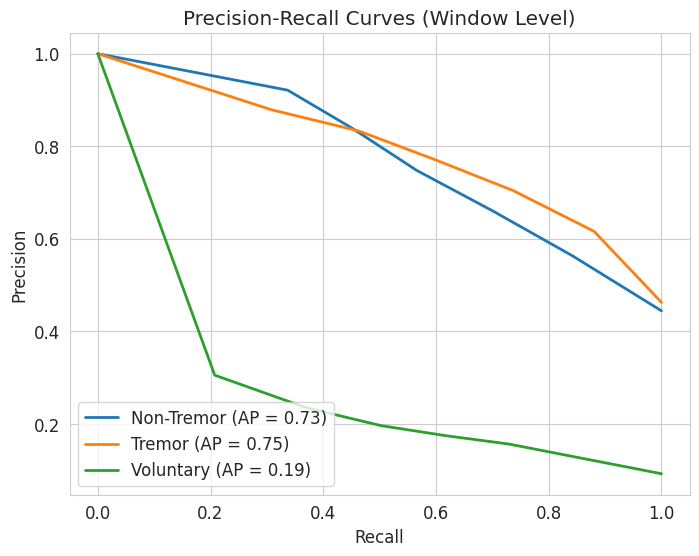


===== KNN | WINDOW LEVEL METRICS =====
Accuracy: 0.6076 | Log Loss: 5.8730 | Precision: 0.5557 | Recall: 0.5797 | F1: 0.5419 | FNR: 0.4203

===== KNN | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.97      0.86      0.91        71
      Tremor       0.85      0.97      0.90        29
   Voluntary       0.70      0.88      0.78        16

    accuracy                           0.89       116
   macro avg       0.84      0.90      0.86       116
weighted avg       0.90      0.89      0.89       116



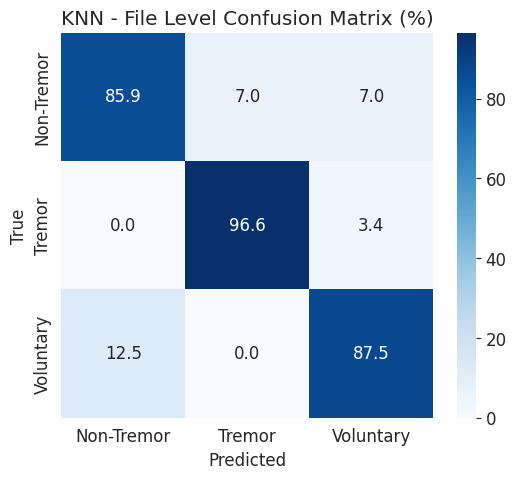

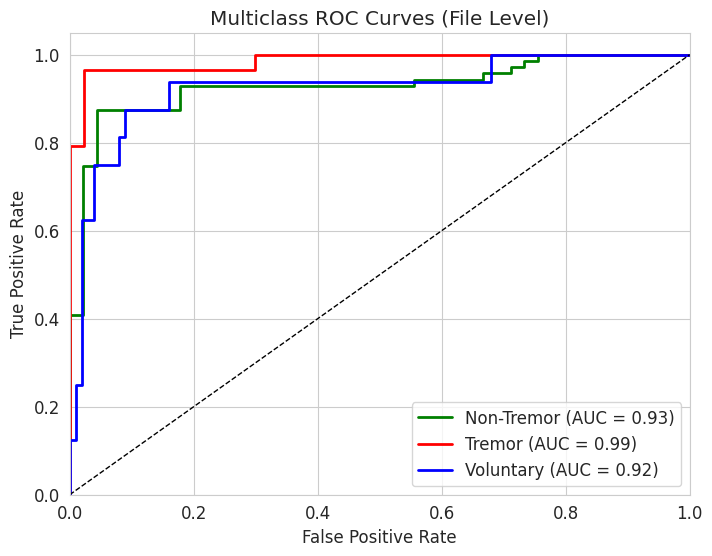

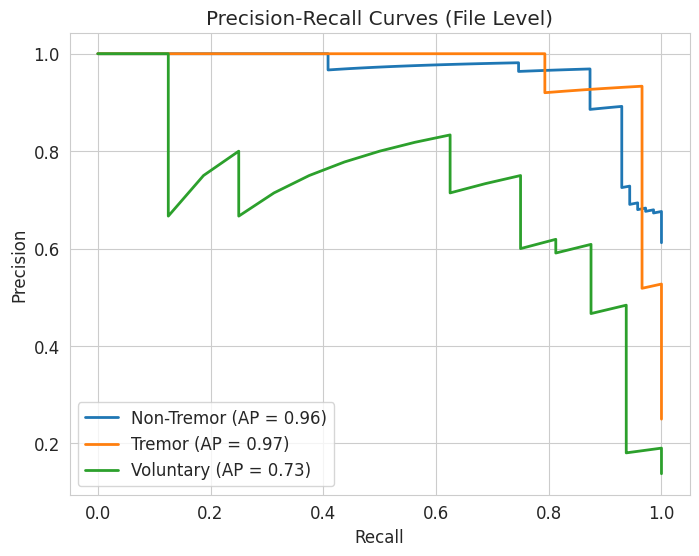


===== KNN | FILE LEVEL METRICS =====
Accuracy: 0.8879 | Log Loss: 0.6356 | Precision: 0.8389 | Recall: 0.8999 | F1: 0.8638 | FNR: 0.1001


In [ ]:
# KNN
knn_pipe = Pipeline([("scaler", StandardScaler()), ("smote", SMOTE(random_state=RANDOM_STATE)),
                     ("clf", KNeighborsClassifier())])
knn_params = {"clf__n_neighbors": [3,5,7,9], "clf__weights": ['uniform','distance']}
best_knn = train_and_evaluate(knn_pipe, knn_params, X, y, groups, "KNN")

Fitting 4 folds for each of 15 candidates, totalling 60 fits
Training time for Gradient Boosting: 16819.35 seconds

===== Gradient Boosting | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.82      0.85      0.84      4583
      Tremor       0.89      0.84      0.86      4772
   Voluntary       0.67      0.76      0.71       955

    accuracy                           0.84     10310
   macro avg       0.79      0.82      0.80     10310
weighted avg       0.84      0.84      0.84     10310



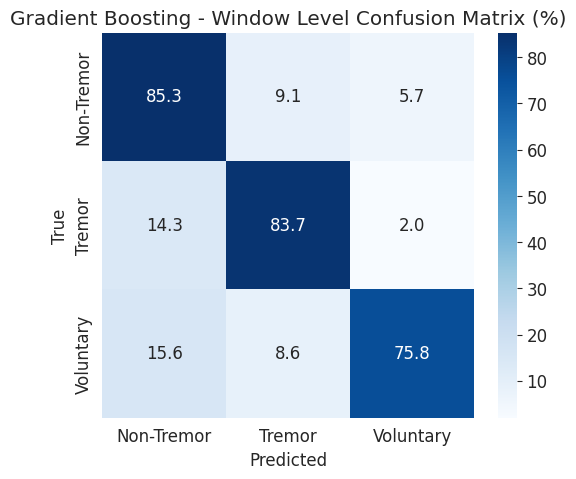

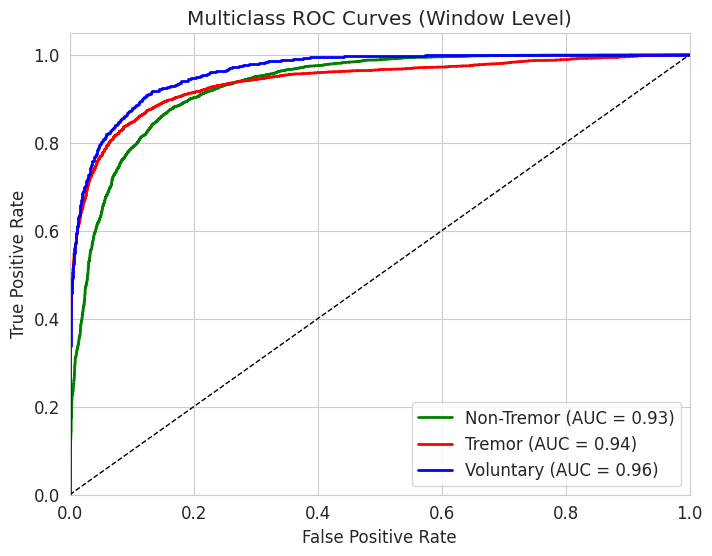

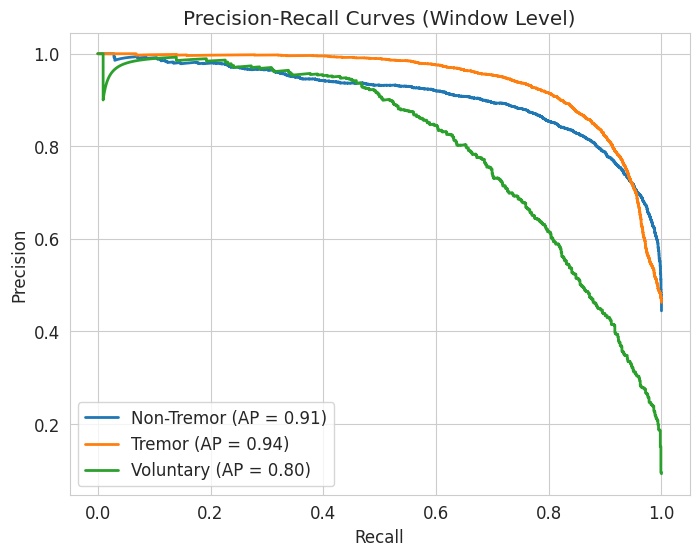


===== Gradient Boosting | WINDOW LEVEL METRICS =====
Accuracy: 0.8368 | Log Loss: 0.5258 | Precision: 0.7949 | Recall: 0.8160 | F1: 0.8042 | FNR: 0.1840

===== Gradient Boosting | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.96      0.96      0.96        71
      Tremor       0.90      0.93      0.92        29
   Voluntary       0.93      0.88      0.90        16

    accuracy                           0.94       116
   macro avg       0.93      0.92      0.93       116
weighted avg       0.94      0.94      0.94       116



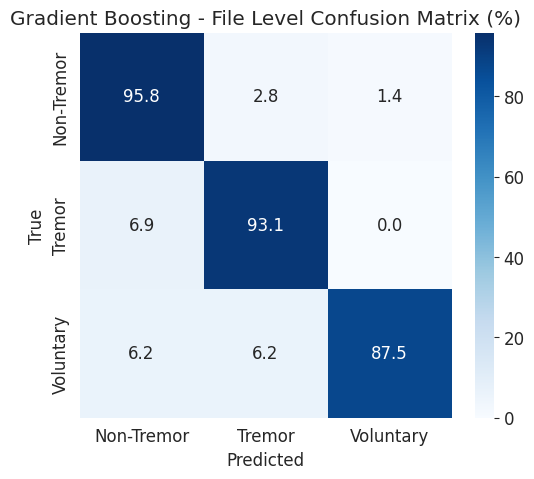

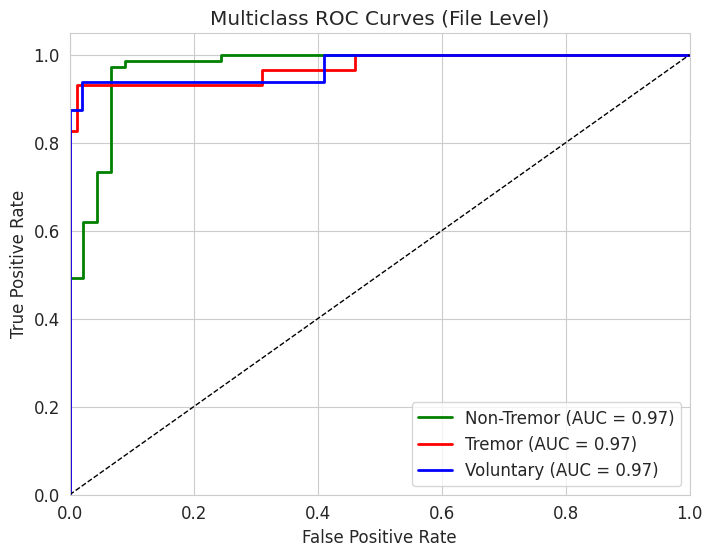

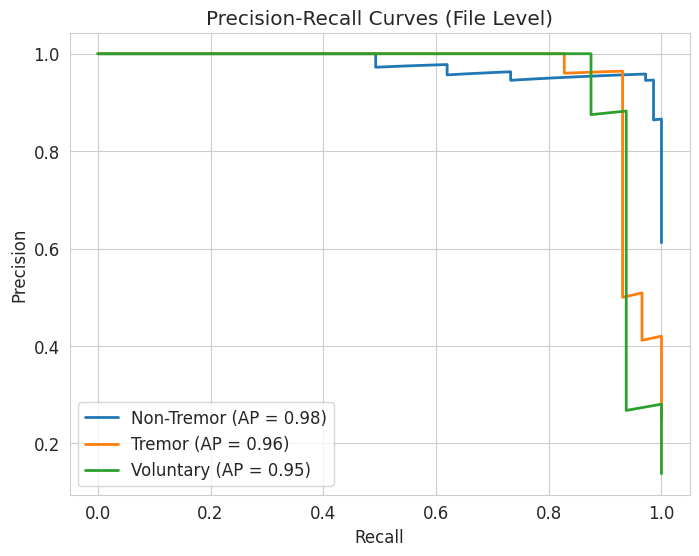


===== Gradient Boosting | FILE LEVEL METRICS =====
Accuracy: 0.9397 | Log Loss: 0.2819 | Precision: 0.9304 | Recall: 0.9213 | F1: 0.9254 | FNR: 0.0787


In [ ]:
# Gradient Boosting
gb_pipe = Pipeline([("smote", SMOTE(random_state=RANDOM_STATE)),
                    ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE))])
gb_params = {"clf__n_estimators": [100,200,300], "clf__learning_rate": [0.01,0.05,0.1],
             "clf__max_depth": [3,5,7]}
best_gb = train_and_evaluate(gb_pipe, gb_params, X, y, groups, "Gradient Boosting")

# **Accuracy & Loss curve Function for DL Models**

In [12]:
def train_final_and_plot(model_builder_or_pipeline, X_train, y_train, X_val, y_val, title, level="Window", **kwargs):
    """
    Train final model on train+val and plot curves (train/val loss & accuracy in same figure).
    """
    if title == "MLP":
        def build_keras_mlp(input_dim):
            model = Sequential([
                Input(shape=(input_dim,)),
                Dense(256, activation='relu'),
                BatchNormalization(),
                Dropout(0.3),
                Dense(128, activation='relu'),
                BatchNormalization(),
                Dropout(0.3),
                Dense(64, activation='relu'),
                Dropout(0.2),
                Dense(3, activation='softmax')
            ])
            model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
            return model

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)

        model = build_keras_mlp(X_train_scaled.shape[1])
        history = model.fit(X_train_scaled, y_train,
                            validation_data=(X_val_scaled, y_val),
                            epochs=100, batch_size=64, verbose=0,
                            callbacks=[EarlyStopping(patience=10, restore_best_weights=True)])
        plot_training_history(history, title, level=level)
        return model

    elif title == "LSTM":
        lstm_clf = LSTMClassifier3(units=kwargs['units'], dropout=kwargs['dropout'],
                                   batch_size=kwargs['batch_size'], epochs=kwargs['epochs'],
                                   optimizer=kwargs['optimizer'])
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], 1, X_train_scaled.shape[1])
        X_val_reshaped = X_val_scaled.reshape(X_val_scaled.shape[0], 1, X_val_scaled.shape[1])
        lstm_clf.model_ = lstm_clf.build_model(X_train_reshaped.shape[2])
        history = lstm_clf.model_.fit(X_train_reshaped, y_train,
                                      validation_data=(X_val_reshaped, y_val),
                                      epochs=kwargs['epochs'], batch_size=kwargs['batch_size'],
                                      verbose=0, callbacks=[EarlyStopping(patience=5, restore_best_weights=True)])
        plot_training_history(history, title, level=level)
        return lstm_clf

    elif title == "TabNet":
        tabnet_model = TabNetClassifier(
            n_d=kwargs['n_d'], n_a=kwargs['n_a'], n_steps=kwargs['n_steps'],
            gamma=kwargs['gamma'], optimizer_params=dict(lr=kwargs['lr']),
            mask_type='entmax', seed=RANDOM_STATE, verbose=0
        )
        X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
        y_train_np = y_train.values if hasattr(y_train, 'values') else y_train
        X_val_np = X_val.values if hasattr(X_val, 'values') else X_val
        y_val_np = y_val.values if hasattr(y_val, 'values') else y_val

        history = tabnet_model.fit(
            X_train_np, y_train_np,
            eval_set=[(X_val_np, y_val_np)],
            max_epochs=kwargs['max_epochs'], patience=kwargs['patience'],
            batch_size=256, virtual_batch_size=128,
            eval_metric=['logloss', 'accuracy']
        )

        hist_dict = {}
        if hasattr(history, 'history'):
            hist_dict = history.history
        else:
            hist_dict = getattr(tabnet_model, 'history_', {})

        class DummyHistory:
            def __init__(self, d):
                self.history = d
        dummy_hist = DummyHistory(hist_dict)

        plot_training_history(dummy_hist, title, level=level)
        return tabnet_model


    elif title == "CNN+LSTM":
        input_dim = X_train.shape[1]
        model = build_cnn_lstm_model(input_dim,
                                     conv_filters=kwargs['conv_filters'],
                                     lstm_units=kwargs['lstm_units'],
                                     dropout=kwargs['dropout'])
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_val_scaled = scaler.transform(X_val)
        X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
        X_val_reshaped = X_val_scaled.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)
        history = model.fit(X_train_reshaped, y_train,
                            validation_data=(X_val_reshaped, y_val),
                            epochs=kwargs['epochs'], batch_size=kwargs['batch_size'],
                            verbose=0, callbacks=[EarlyStopping(patience=5, restore_best_weights=True)])
        plot_training_history(history, title, level=level)
        return model

    else:
        return None

# **Deep Learning Models**

Training time for MLP: 91.09 seconds

===== MLP | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.73      0.65      0.69      4583
      Tremor       0.74      0.66      0.70      4772
   Voluntary       0.21      0.45      0.29       955

    accuracy                           0.63     10310
   macro avg       0.56      0.59      0.56     10310
weighted avg       0.69      0.63      0.65     10310



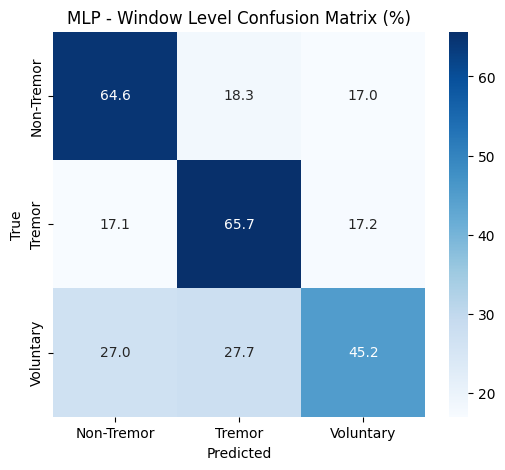

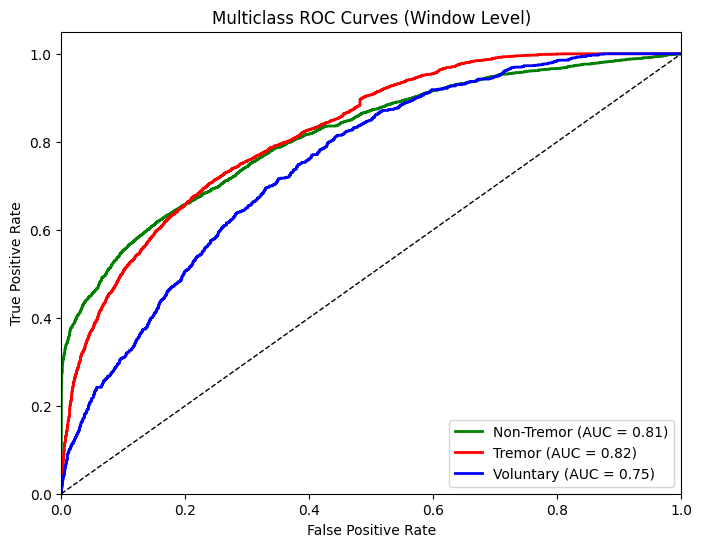

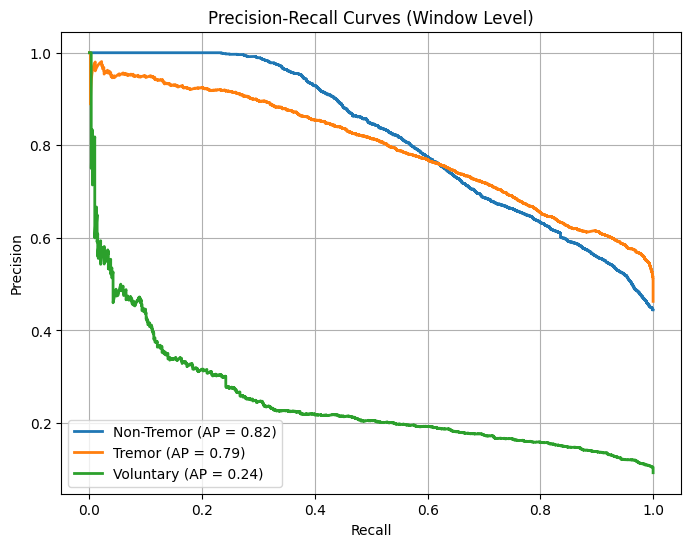


===== MLP | WINDOW LEVEL METRICS =====
Accuracy: 0.6331 | Log Loss: 1.0986 | Precision: 0.5618 | Recall: 0.5851 | F1: 0.5572 | FNR: 0.4149

===== MLP | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.93      0.70      0.80        71
      Tremor       0.68      0.90      0.78        29
   Voluntary       0.38      0.56      0.45        16

    accuracy                           0.73       116
   macro avg       0.66      0.72      0.68       116
weighted avg       0.79      0.73      0.75       116



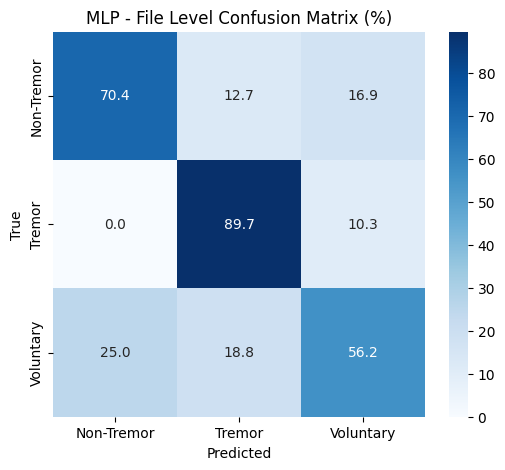

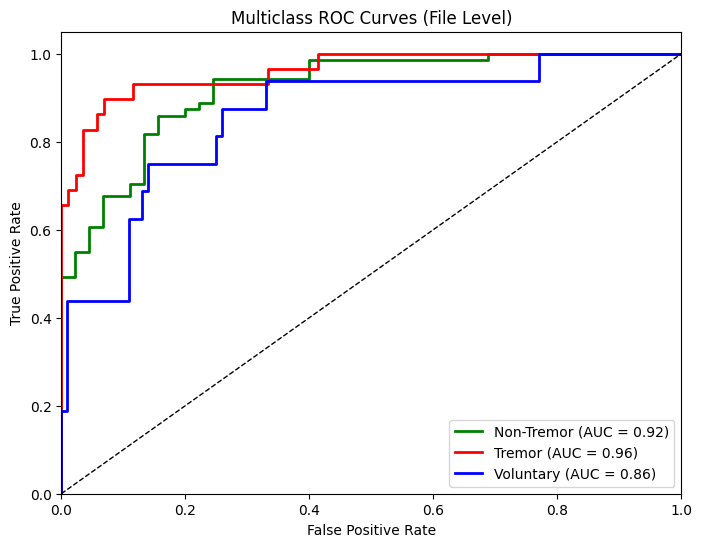

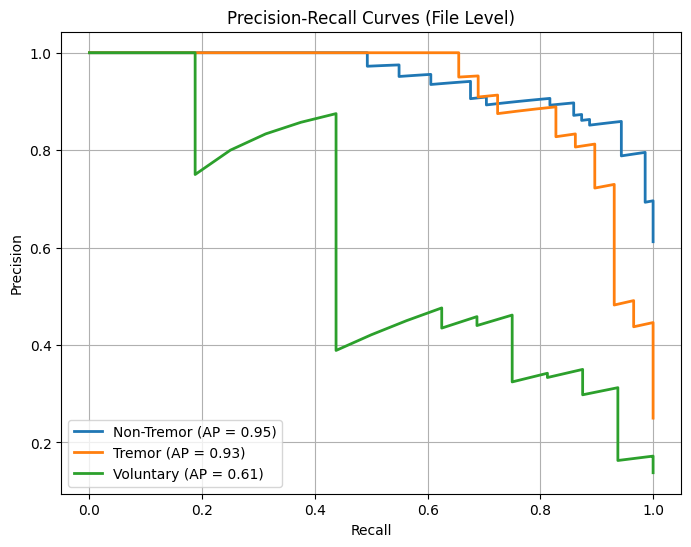


===== MLP | FILE LEVEL METRICS =====
Accuracy: 0.7328 | Log Loss: 0.6017 | Precision: 0.6617 | Recall: 0.7211 | F1: 0.6754 | FNR: 0.2789


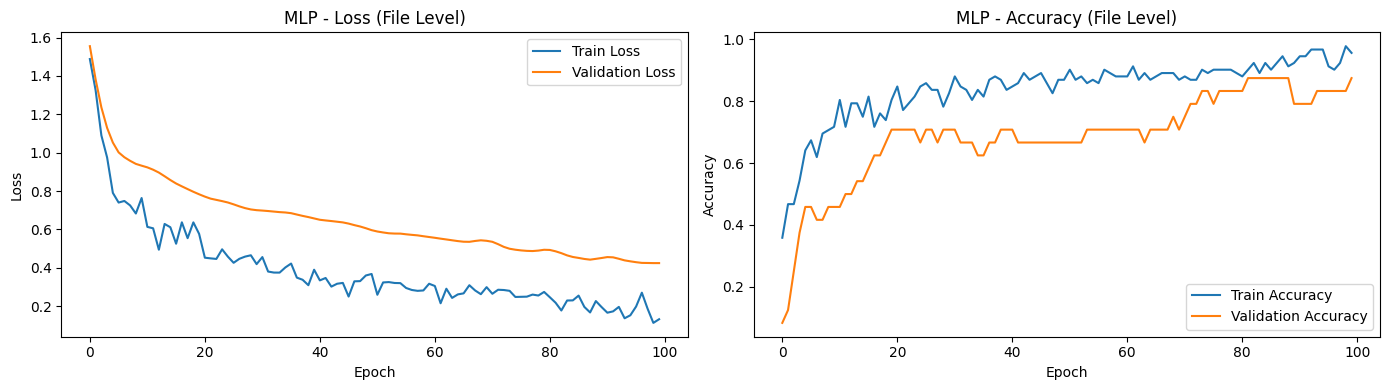

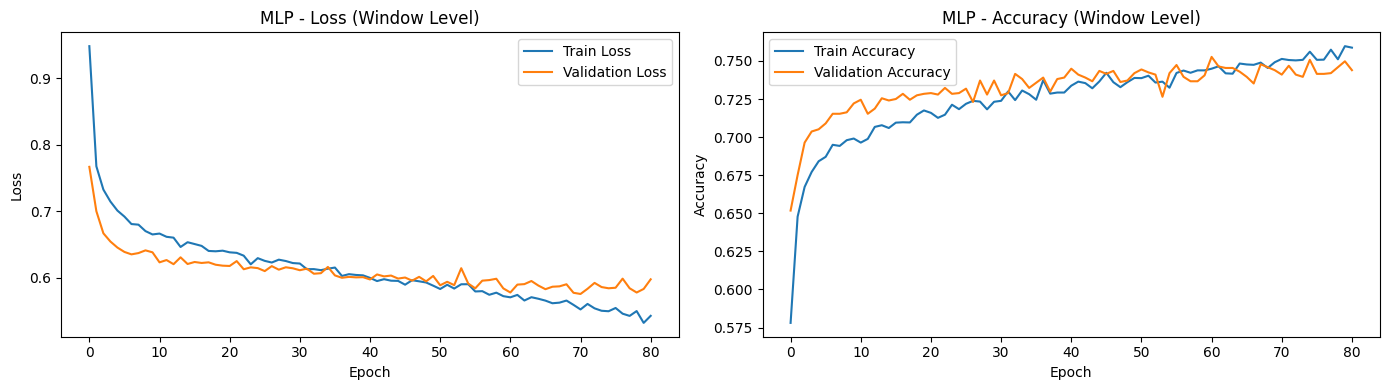

In [ ]:
#MLP
def train_mlp():
    start_time = time.time()
    best_f1 = -1
    best_model = None
    for train_idx, val_idx in cv.split(X, y, groups):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        pipe = Pipeline([("scaler", StandardScaler()), ("smote", SMOTE(random_state=RANDOM_STATE)),
                         ("mlp", MLPClassifier(hidden_layer_sizes=(256,128,64), activation='relu',
                                               max_iter=200, early_stopping=True, random_state=RANDOM_STATE))])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_val)
        f1 = f1_score(y_val, y_pred, average='macro')
        if f1 > best_f1:
            best_f1 = f1
            best_model = pipe
    elapsed = time.time() - start_time
    print(f"Training time for MLP: {elapsed:.2f} seconds")
    evaluate_model(best_model, X, y, groups, title="MLP", training_time=elapsed, history=None)
    X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
    final_mlp = train_final_and_plot(None, X_train_final, y_train_final, X_val_final, y_val_final, "MLP")
    return best_model

best_mlp = train_mlp()

Fitting 4 folds for each of 6 candidates, totalling 24 fits
Training time for LSTM: 714.66 seconds


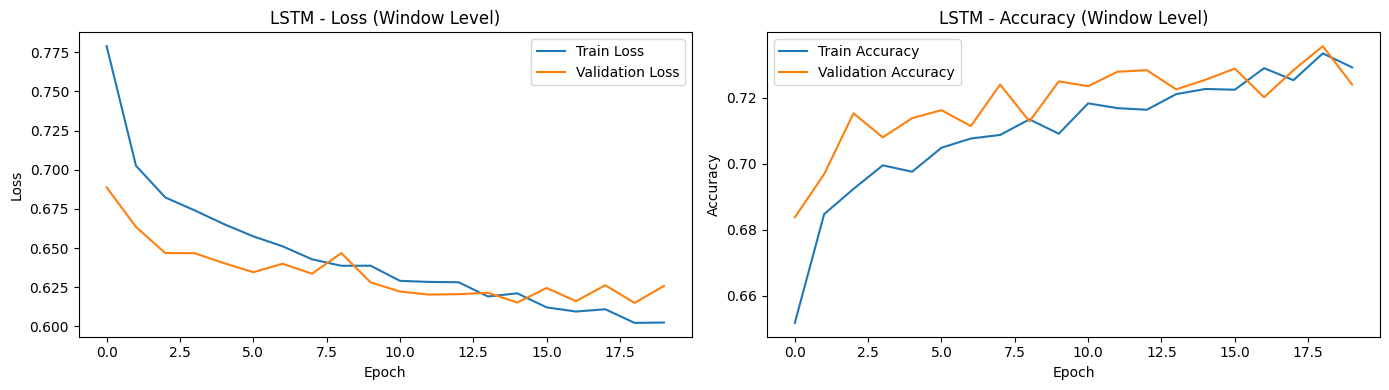


===== LSTM | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.71      0.71      0.71      4583
      Tremor       0.70      0.79      0.74      4772
   Voluntary       0.46      0.15      0.22       955

    accuracy                           0.70     10310
   macro avg       0.62      0.55      0.56     10310
weighted avg       0.68      0.70      0.68     10310



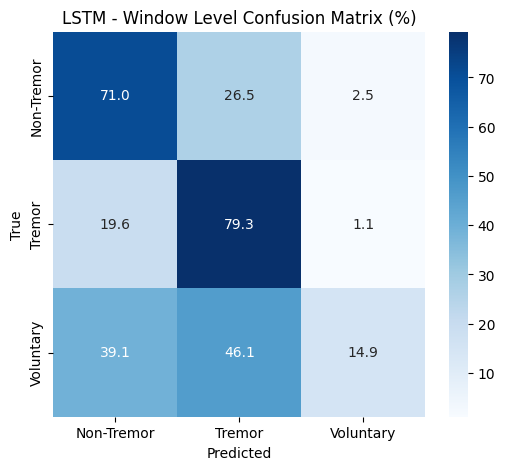

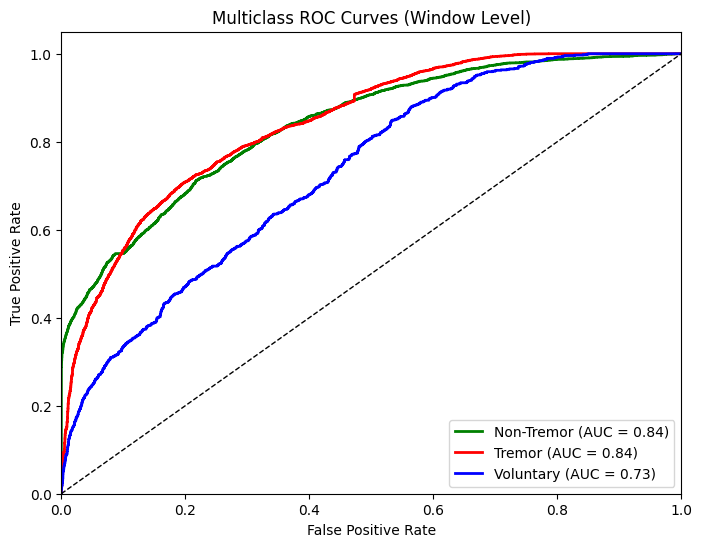

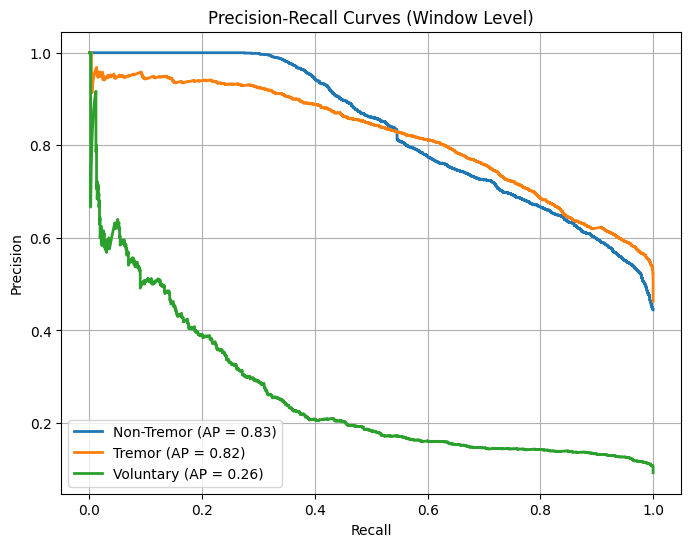


===== LSTM | WINDOW LEVEL METRICS =====
Accuracy: 0.6963 | Log Loss: 0.7009 | Precision: 0.6223 | Recall: 0.5505 | F1: 0.5591 | FNR: 0.4495

===== LSTM | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.86      0.79      0.82        71
      Tremor       0.57      0.97      0.72        29
   Voluntary       1.00      0.12      0.22        16

    accuracy                           0.74       116
   macro avg       0.81      0.63      0.59       116
weighted avg       0.81      0.74      0.71       116



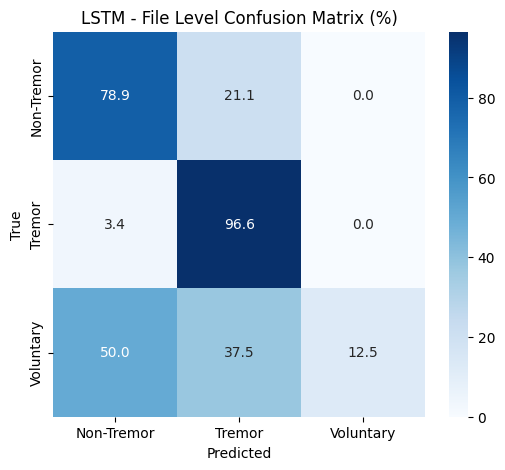

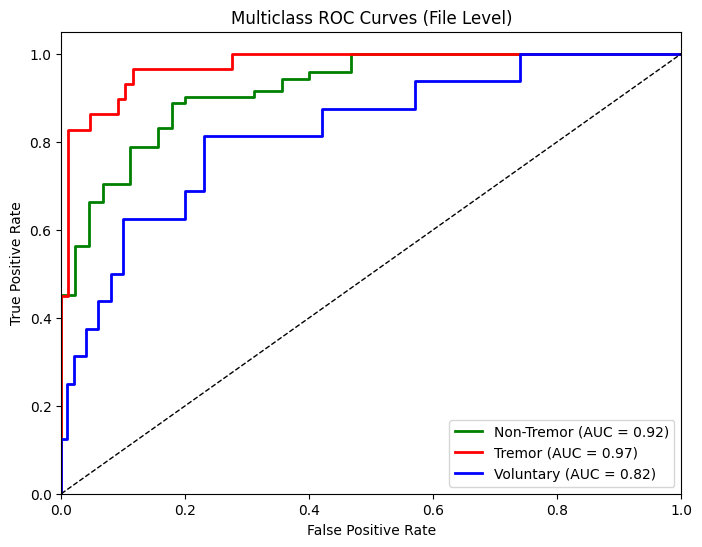

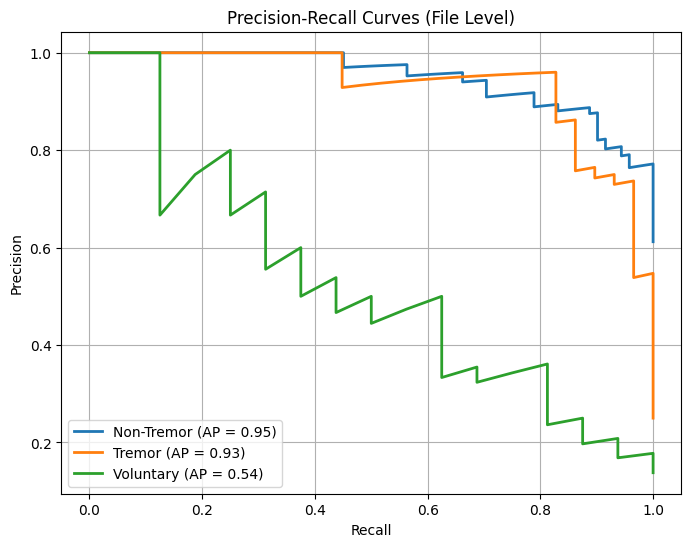


===== LSTM | FILE LEVEL METRICS =====
Accuracy: 0.7414 | Log Loss: 0.6578 | Precision: 0.8110 | Recall: 0.6264 | F1: 0.5879 | FNR: 0.3736


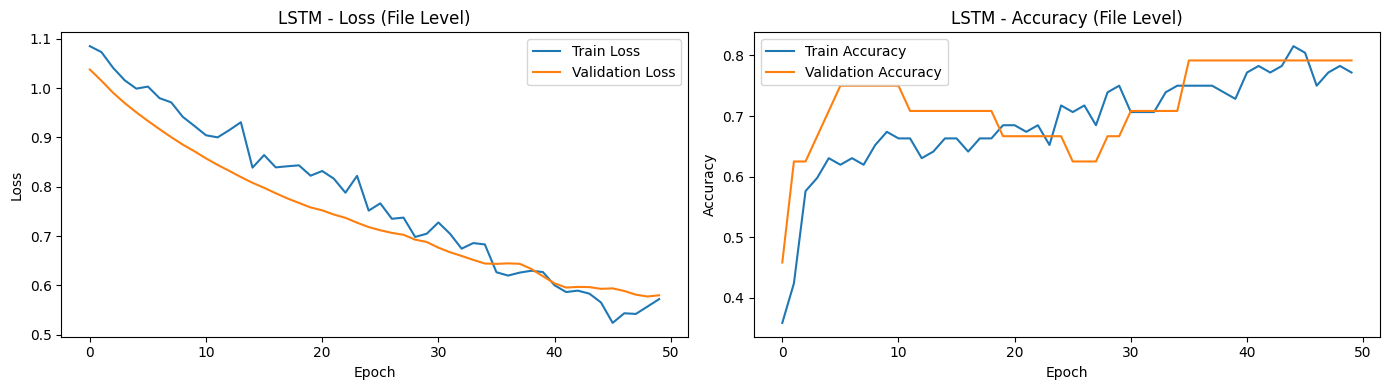

Pipeline(steps=[('clf',
                 LSTMClassifier3(batch_size=16, dropout=0.2, epochs=20,
                                 units=128))])

In [16]:
# LSTM
class LSTMClassifier3(BaseEstimator, ClassifierMixin):
    def __init__(self, units=64, dropout=0.3, batch_size=32, epochs=30, optimizer='adam'):
        self.units = units; self.dropout = dropout; self.batch_size = batch_size
        self.epochs = epochs; self.optimizer = optimizer
    def build_model(self, input_dim, n_classes=3):
        model = Sequential([
            Input(shape=(1, input_dim)),
            LSTM(self.units),
            Dropout(self.dropout),
            Dense(self.units//2, activation='relu'),
            Dropout(self.dropout),
            Dense(n_classes, activation='softmax')
        ])
        model.compile(optimizer=self.optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        return model
    def fit(self, X, y):
        X = np.array(X).reshape((X.shape[0], 1, X.shape[1]))
        self.model_ = self.build_model(X.shape[2])
        self.model_.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, verbose=0)
        return self
    def predict(self, X):
        X = np.array(X).reshape((X.shape[0], 1, X.shape[1]))
        preds = self.model_.predict(X, verbose=0)
        return np.argmax(preds, axis=1)
    def predict_proba(self, X):
        X = np.array(X).reshape((X.shape[0], 1, X.shape[1]))
        return self.model_.predict(X, verbose=0)

X_scaled = StandardScaler().fit_transform(X)
lstm_pipe = Pipeline([("clf", LSTMClassifier3())])
lstm_params = {"clf__units": [64,128], "clf__dropout": [0.2,0.3], "clf__batch_size": [16,32], "clf__epochs": [20,30]}
lstm_search = RandomizedSearchCV(lstm_pipe, lstm_params, n_iter=6, scoring='f1_macro',
                                  cv=cv, random_state=RANDOM_STATE, n_jobs=1, verbose=1)
start_time = time.time()
lstm_search.fit(X_scaled, y, groups=groups)

elapsed = time.time() - start_time
print(f"Training time for LSTM: {elapsed:.2f} seconds")

best_lstm = lstm_search.best_estimator_
best_params_lstm = lstm_search.best_params_

lstm_final_params = {
    'units': best_params_lstm.get('clf__units', 64),
    'dropout': best_params_lstm.get('clf__dropout', 0.3),
    'batch_size': best_params_lstm.get('clf__batch_size', 32),
    'epochs': best_params_lstm.get('clf__epochs', 30),
    'optimizer': best_params_lstm.get('clf__optimizer', 'adam')
}

X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
final_lstm = train_final_and_plot(None, X_train_final, y_train_final, X_val_final, y_val_final, "LSTM",
                                  units=lstm_final_params['units'],
                                  dropout=lstm_final_params['dropout'],
                                  batch_size=lstm_final_params['batch_size'],
                                  epochs=lstm_final_params['epochs'],
                                  optimizer=lstm_final_params['optimizer'])

evaluate_model(best_lstm, X_scaled, y, groups, title="LSTM", training_time=elapsed)

Fitting 4 folds for each of 4 candidates, totalling 16 fits
Training time for TabNet: 1113.32 seconds
Stop training because you reached max_epochs = 50 with best_epoch = 41 and best_val_0_accuracy = 0.73084


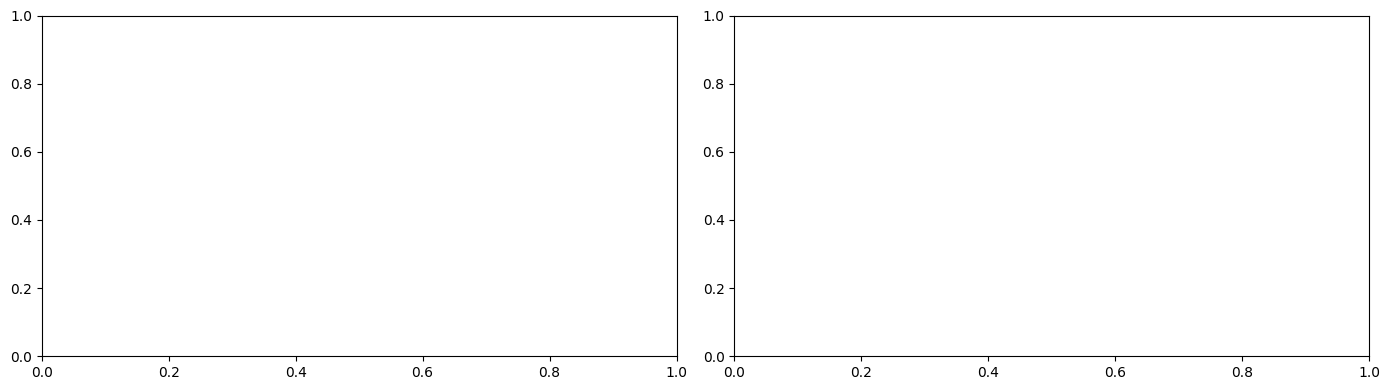


===== TabNet | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.78      0.58      0.66      4583
      Tremor       0.78      0.64      0.70      4772
   Voluntary       0.23      0.72      0.35       955

    accuracy                           0.62     10310
   macro avg       0.60      0.65      0.57     10310
weighted avg       0.73      0.62      0.65     10310



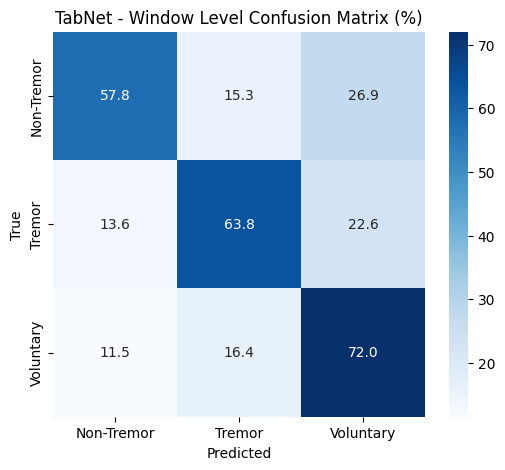

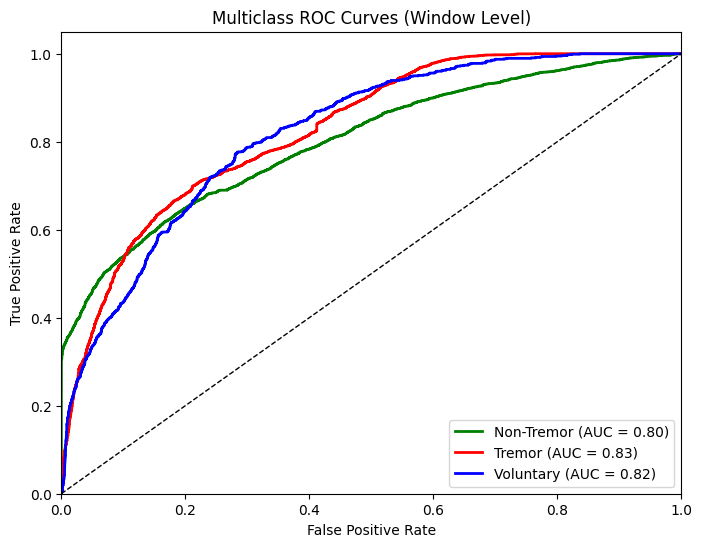

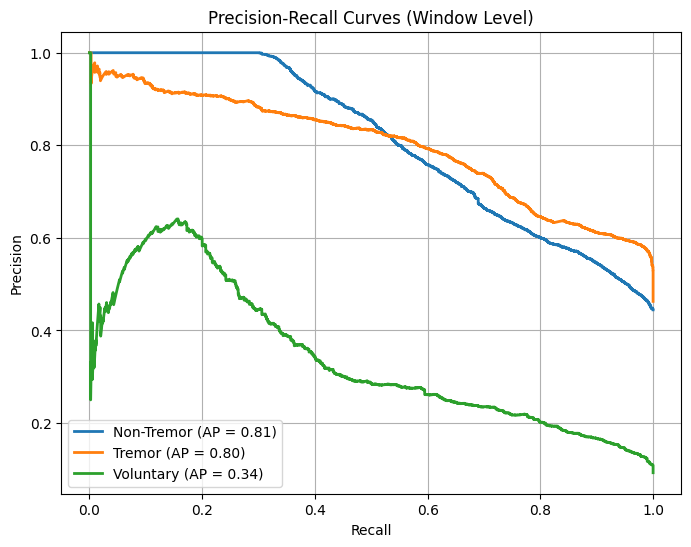


===== TabNet | WINDOW LEVEL METRICS =====
Accuracy: 0.6188 | Log Loss: 0.8286 | Precision: 0.5955 | Recall: 0.6454 | F1: 0.5708 | FNR: 0.3546

===== TabNet | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.96      0.63      0.76        71
      Tremor       0.77      0.79      0.78        29
   Voluntary       0.36      0.88      0.51        16

    accuracy                           0.71       116
   macro avg       0.69      0.77      0.68       116
weighted avg       0.83      0.71      0.73       116



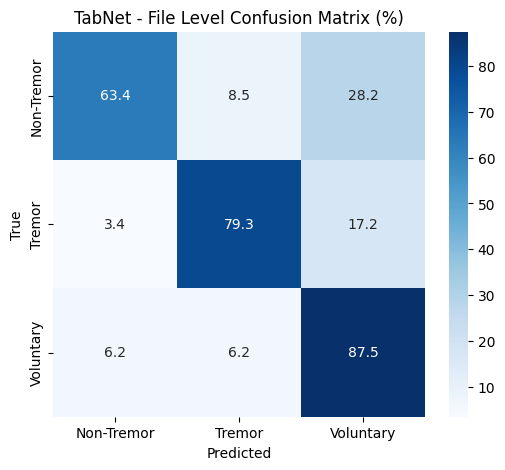

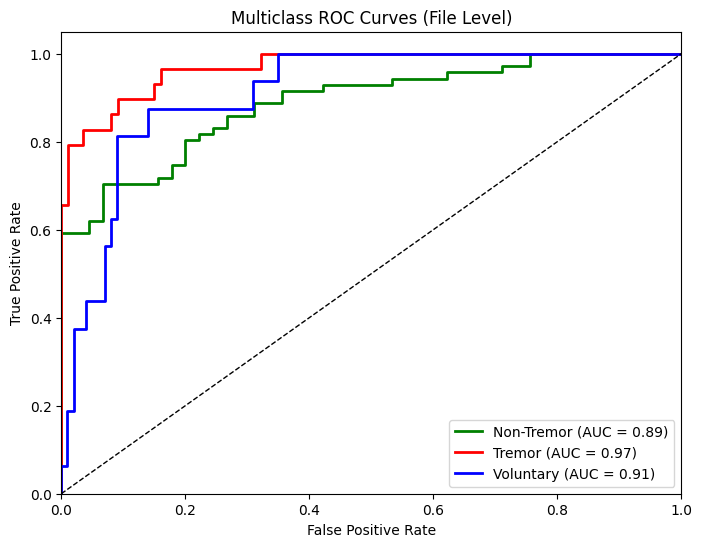

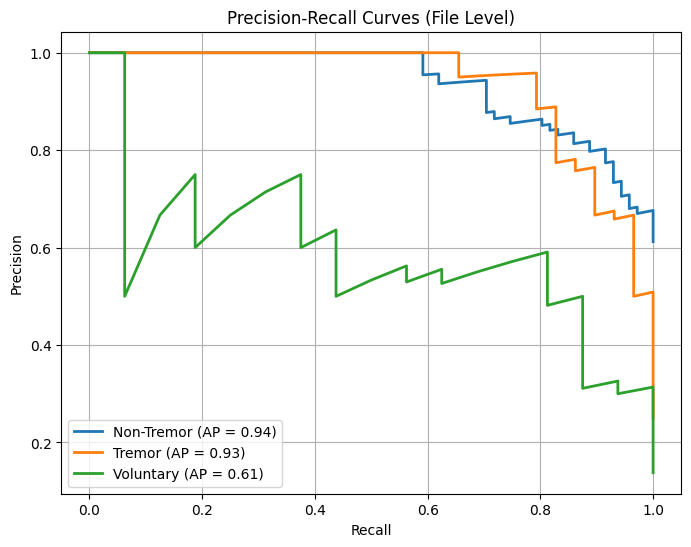


===== TabNet | FILE LEVEL METRICS =====
Accuracy: 0.7069 | Log Loss: 0.6630 | Precision: 0.6944 | Recall: 0.7673 | F1: 0.6838 | FNR: 0.2327
File-level training for TabNet completed (no history plot available for TabNet/MLP).


Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('clf', TabNetWrapper3(lr=0.01))])

In [17]:
# TabNet
class TabNetWrapper3(BaseEstimator, ClassifierMixin):
    def __init__(self, n_d=8, n_a=8, n_steps=3, gamma=1.3, lr=0.02, max_epochs=50, patience=10, seed=42):
        self.n_d=n_d; self.n_a=n_a; self.n_steps=n_steps; self.gamma=gamma; self.lr=lr
        self.max_epochs=max_epochs; self.patience=patience; self.seed=seed
    def fit(self, X, y):
        self.model_ = TabNetClassifier(n_d=self.n_d, n_a=self.n_a, n_steps=self.n_steps,
                                       gamma=self.gamma, optimizer_params=dict(lr=self.lr),
                                       seed=self.seed, verbose=0)
        self.model_.fit(X.values if hasattr(X,'values') else X, y,
                        max_epochs=self.max_epochs, patience=self.patience, batch_size=256)
        return self
    def predict(self, X):
        return self.model_.predict(X.values if hasattr(X,'values') else X)
    def predict_proba(self, X):
        return self.model_.predict_proba(X.values if hasattr(X,'values') else X)

tabnet_pipe = Pipeline([("smote", SMOTE(random_state=RANDOM_STATE)),
                        ("clf", TabNetWrapper3(seed=RANDOM_STATE))])
tabnet_params = {"clf__n_d": [8,16], "clf__n_steps": [3,5], "clf__lr": [0.01,0.02]}
tabnet_search = RandomizedSearchCV(tabnet_pipe, tabnet_params, n_iter=4, scoring='f1_macro',
                                    cv=cv, random_state=RANDOM_STATE, n_jobs=1, verbose=1)
start_time = time.time()
tabnet_search.fit(X, y, groups=groups)

elapsed = time.time() - start_time
print(f"Training time for TabNet: {elapsed:.2f} seconds")

best_tabnet = tabnet_search.best_estimator_
best_params_tabnet = tabnet_search.best_params_
tabnet_final_params = {
    'n_d': best_params_tabnet.get('clf__n_d', 8),
    'n_a': best_params_tabnet.get('clf__n_a', 8),
    'n_steps': best_params_tabnet.get('clf__n_steps', 3),
    'gamma': best_params_tabnet.get('clf__gamma', 1.3),
    'lr': best_params_tabnet.get('clf__lr', 0.02)
}

X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
final_tabnet = train_final_and_plot(None, X_train_final, y_train_final, X_val_final, y_val_final, "TabNet",
                                    n_d=tabnet_final_params['n_d'],
                                    n_a=tabnet_final_params['n_a'],
                                    n_steps=tabnet_final_params['n_steps'],
                                    gamma=tabnet_final_params['gamma'],
                                    lr=tabnet_final_params['lr'],
                                    max_epochs=50, patience=10)

evaluate_model(best_tabnet, X, y, groups, title="TabNet", training_time=elapsed)

Best CNN+LSTM F1: 0.5722321022450484 Params: {'conv_filters': 128, 'lstm_units': 128, 'dropout': 0.3}
Training final CNN+LSTM model and plotting curves...


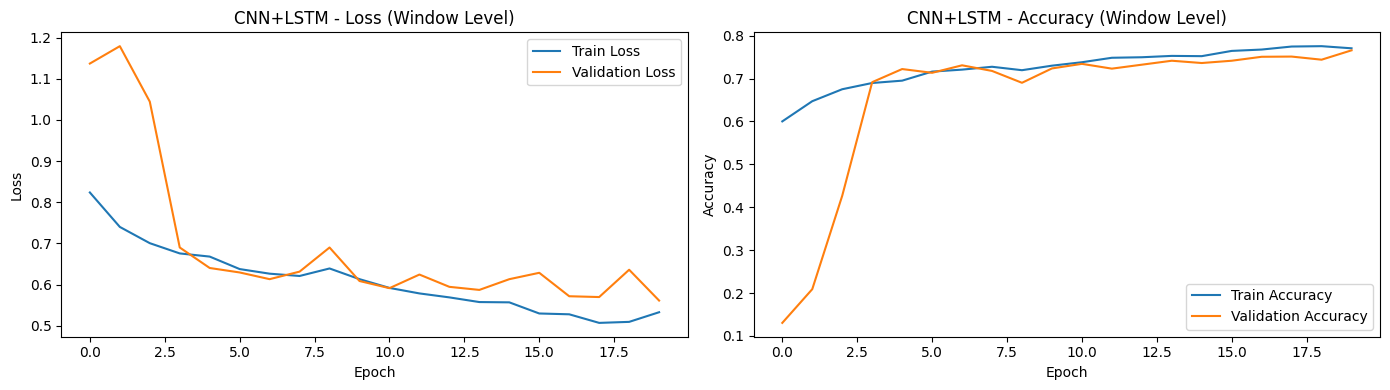

Training time for CNN+LSTM: 3646.46 seconds

===== CNN+LSTM | WINDOW LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.65      0.75      0.70      4583
      Tremor       0.72      0.69      0.70      4772
   Voluntary       0.43      0.21      0.28       955

    accuracy                           0.67     10310
   macro avg       0.60      0.55      0.56     10310
weighted avg       0.66      0.67      0.66     10310



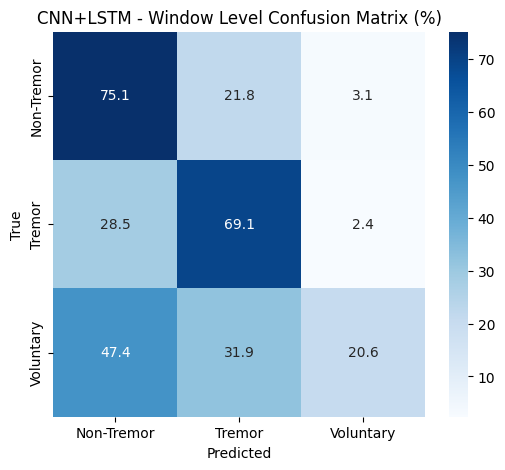

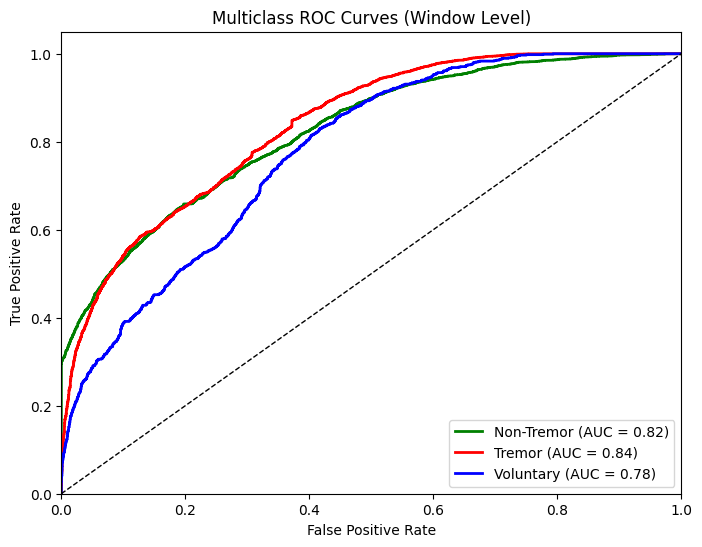

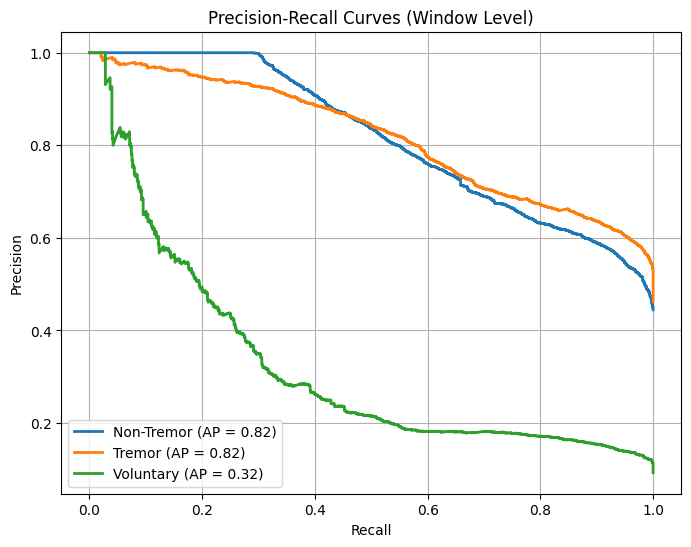


===== CNN+LSTM | WINDOW LEVEL METRICS =====
Accuracy: 0.6726 | Log Loss: 0.7406 | Precision: 0.6015 | Recall: 0.5493 | F1: 0.5608 | FNR: 0.4507

===== CNN+LSTM | FILE LEVEL =====
              precision    recall  f1-score   support

  Non-Tremor       0.86      0.87      0.87        71
      Tremor       0.65      0.90      0.75        29
   Voluntary       0.75      0.19      0.30        16

    accuracy                           0.78       116
   macro avg       0.75      0.65      0.64       116
weighted avg       0.79      0.78      0.76       116



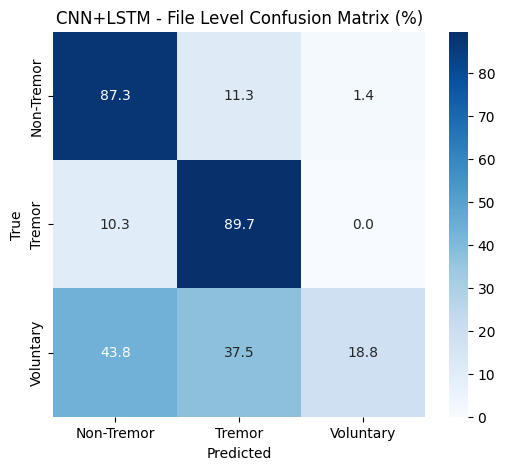

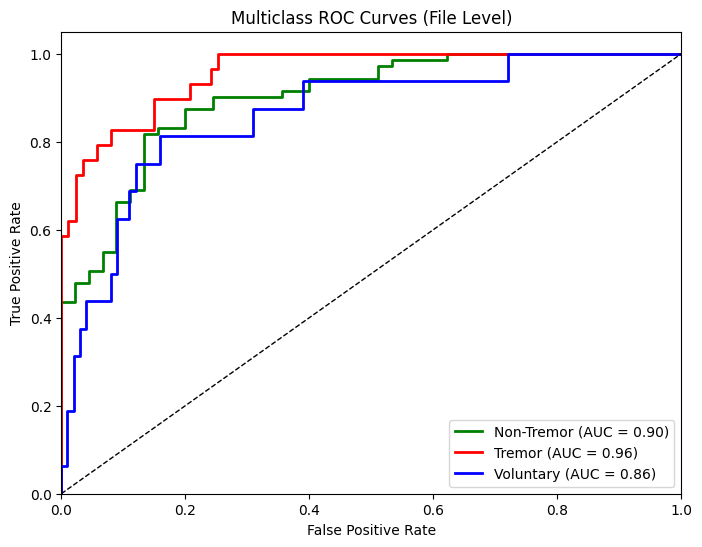

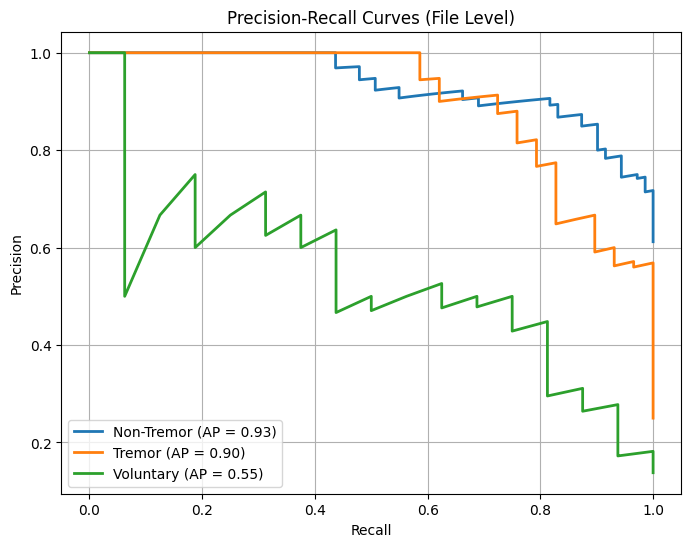


===== CNN+LSTM | FILE LEVEL METRICS =====
Accuracy: 0.7845 | Log Loss: 0.5936 | Precision: 0.7537 | Recall: 0.6524 | F1: 0.6403 | FNR: 0.3476


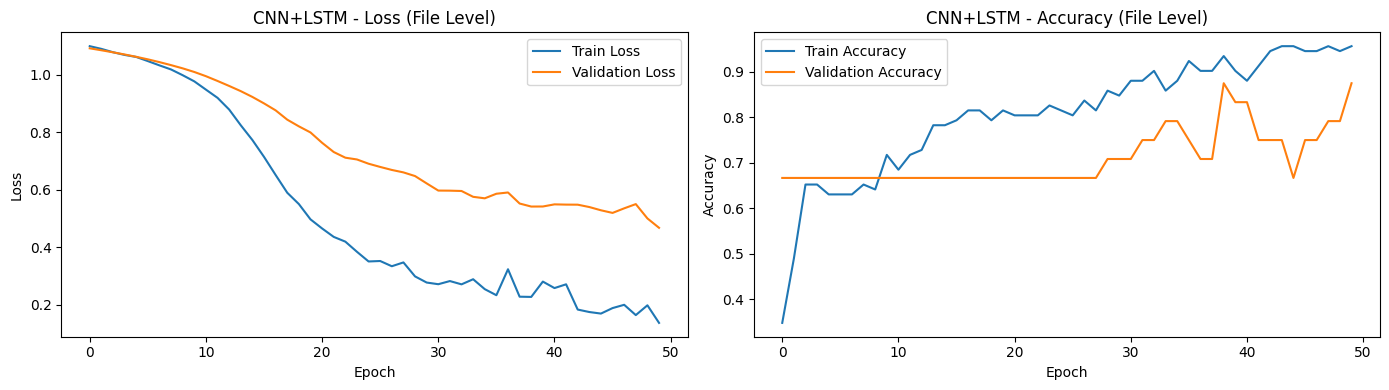

In [ ]:
# CNN + LSTM

def build_cnn_lstm_model(input_dim, conv_filters=128, lstm_units=128, dropout=0.3):
    model = Sequential([
        Conv1D(conv_filters, 3, activation="relu", padding="same", input_shape=(input_dim, 1)),
        BatchNormalization(),
        Conv1D(conv_filters//2, 3, activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling1D(2, padding='same'),   # <-- أضف padding='same'
        LSTM(lstm_units, return_sequences=True),
        Dropout(dropout),
        LSTM(lstm_units//2),
        Dropout(dropout),
        Dense(64, activation="relu"),
        Dense(3, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

# Hyperparameter grid (same as original, but adapted)
param_grid = [
    {"conv_filters": 64, "lstm_units": 64, "dropout": 0.2},
    {"conv_filters": 128, "lstm_units": 64, "dropout": 0.3},
    {"conv_filters": 128, "lstm_units": 128, "dropout": 0.3},
]

best_f1 = 0
best_model_cnn_lstm = None
best_params_cnn_lstm = None

start_time = time.time()

for params in param_grid:
    fold_f1s = []
    for train_idx, test_idx in cv.split(X, y, groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)
        X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
        X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
        model = build_cnn_lstm_model(X_train.shape[1],
                                     conv_filters=params["conv_filters"],
                                     lstm_units=params["lstm_units"],
                                     dropout=params["dropout"])
        model.fit(X_train, y_train, epochs=20, batch_size=64, verbose=0, validation_data=(X_test, y_test))
        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        fold_f1s.append(f1_score(y_test, y_pred, average='macro'))
    mean_f1 = np.mean(fold_f1s)
    if mean_f1 > best_f1:
        best_f1 = mean_f1
        best_model_cnn_lstm = model
        best_params_cnn_lstm = params

print("Best CNN+LSTM F1:", best_f1, "Params:", best_params_cnn_lstm)

print("Training final CNN+LSTM model and plotting curves...")
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
final_cnn_lstm = train_final_and_plot(None, X_train_final, y_train_final, X_val_final, y_val_final,
                                      "CNN+LSTM",
                                      conv_filters=best_params_cnn_lstm["conv_filters"],
                                      lstm_units=best_params_cnn_lstm["lstm_units"],
                                      dropout=best_params_cnn_lstm["dropout"],
                                      epochs=20, batch_size=64)

elapsed = time.time() - start_time
print(f"Training time for CNN+LSTM: {elapsed:.2f} seconds")
evaluate_cnn_lstm_model(build_cnn_lstm_model, best_params_cnn_lstm, X, y, groups, title="CNN+LSTM", training_time=elapsed)

In [14]:
import os

for f in sorted(os.listdir("/content")):
    if f.endswith(".pkl"):
        print(f)

abdelatef_ osama_best_cat.pkl
abdelatef_osama_best_gb.pkl
abdelatef_osama_best_knn.pkl
abdelatef_osama_best_lgb.pkl
abdelatef_osama_best_lstm.pkl
abdelatef_osama_best_mlp.pkl
abdelatef_osama_best_rf.pkl
abdelatef_osama_best_svm.pkl
abdelatef_osama_best_tabnet.pkl
abdelatef_osama_best_xgb.pkl


In [15]:
import joblib

for f in [
    "/content/abdelatef_osama_best_lgb.pkl",
    "/content/abdelatef_osama_best_lstm.pkl",
    "/content/abdelatef_osama_best_tabnet.pkl"
]:
    try:
        m = joblib.load(f)
        print("OK:", f)
    except Exception as e:
        print("ERROR:", f)
        print(e)

OK: /content/abdelatef_osama_best_lgb.pkl
ERROR: /content/abdelatef_osama_best_lstm.pkl
Can't get attribute 'LSTMClassifier3' on <module '__main__'>
ERROR: /content/abdelatef_osama_best_tabnet.pkl
Can't get attribute 'TabNetWrapper3' on <module '__main__'>


# **Model Comparison**


STARTING MODEL COMPARISON (3-CLASS)
✓ Loaded LightGBM
✓ Loaded CatBoost
✓ Loaded XGBoost
✓ Loaded Gradient Boosting
✓ Loaded Random Forest
✓ Loaded SVM (RBF)
✓ Loaded KNN
✓ Loaded MLP
✓ Loaded LSTM
✓ Loaded TabNet

Evaluating LightGBM...
  → Acc: 0.8766 ± 0.0361 | Macro F1: 0.8477 ± 0.0337

Evaluating CatBoost...
  → Acc: 0.8432 ± 0.0296 | Macro F1: 0.8057 ± 0.0315

Evaluating XGBoost...
  → Acc: 0.8599 ± 0.0334 | Macro F1: 0.8260 ± 0.0322

Evaluating Gradient Boosting...
  → Acc: 0.8603 ± 0.0316 | Macro F1: 0.8251 ± 0.0320

Evaluating Random Forest...
  → Acc: 0.8517 ± 0.0356 | Macro F1: 0.8128 ± 0.0357

Evaluating SVM (RBF)...
  → Acc: 0.6213 ± 0.0290 | Macro F1: 0.5482 ± 0.0367

Evaluating KNN...
  → Acc: 0.6072 ± 0.0113 | Macro F1: 0.5358 ± 0.0187

Evaluating MLP...
  → Acc: 0.6353 ± 0.0324 | Macro F1: 0.5569 ± 0.0361

Evaluating LSTM...
  → Acc: 0.8005 ± 0.0256 | Macro F1: 0.7241 ± 0.0438

Evaluating TabNet...
  → Acc: 0.6082 ± 0.0622 | Macro F1: 0.4949 ± 0.0987

FINAL MODEL COMP

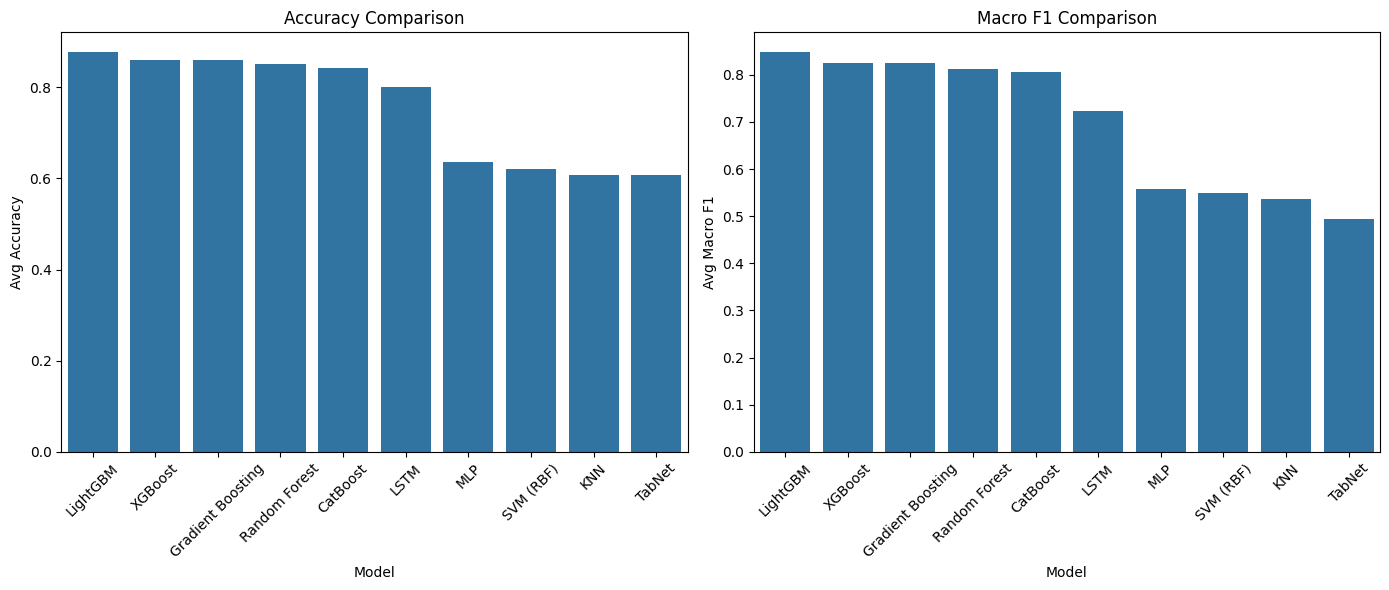


Comparison results saved to:
/content/model_comparison.csv


In [18]:
import os
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score

print("\n" + "="*80)
print("STARTING MODEL COMPARISON (3-CLASS)")
print("="*80)

# ======================
# LOAD MODELS FROM PKL
# ======================

model_files = {
    "LightGBM": "/content/abdelatef_osama_best_lgb.pkl",
    "CatBoost": "/content/abdelatef_ osama_best_cat.pkl",
    "XGBoost": "/content/abdelatef_osama_best_xgb.pkl",
    "Gradient Boosting": "/content/abdelatef_osama_best_gb.pkl",
    "Random Forest": "/content/abdelatef_osama_best_rf.pkl",
    "SVM (RBF)": "/content/abdelatef_osama_best_svm.pkl",
    "KNN": "/content/abdelatef_osama_best_knn.pkl",
    "MLP": "/content/abdelatef_osama_best_mlp.pkl",
    "LSTM": "/content/abdelatef_osama_best_lstm.pkl",
    "TabNet": "/content/abdelatef_osama_best_tabnet.pkl"
}

models_to_compare = {}

for name, path in model_files.items():
    if os.path.exists(path):
        try:
            models_to_compare[name] = joblib.load(path)
            print(f"✓ Loaded {name}")
        except Exception as e:
            print(f"✗ Failed loading {name}: {e}")
    else:
        print(f"✗ File not found: {path}")

# ======================
# CROSS VALIDATION
# ======================

gkf_compare = GroupKFold(n_splits=5)
comparison_results = []

# ======================
# EVALUATE MODELS
# ======================

for name, model in models_to_compare.items():

    print(f"\nEvaluating {name}...")

    accuracies = []
    f1_macros = []

    try:

        for train_idx, test_idx in gkf_compare.split(X, y, groups):

            X_train = X.iloc[train_idx] if hasattr(X, "iloc") else X[train_idx]
            X_test = X.iloc[test_idx] if hasattr(X, "iloc") else X[test_idx]

            y_train = y[train_idx]
            y_test = y[test_idx]

            model_copy = clone(model)

            model_copy.fit(X_train, y_train)

            y_pred = model_copy.predict(X_test)

            acc = accuracy_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average="macro")

            accuracies.append(acc)
            f1_macros.append(f1)

        comparison_results.append({
            "Model": name,
            "Avg Accuracy": np.mean(accuracies),
            "Std Accuracy": np.std(accuracies),
            "Avg Macro F1": np.mean(f1_macros),
            "Std Macro F1": np.std(f1_macros)
        })

        print(
            f"  → Acc: {np.mean(accuracies):.4f} ± {np.std(accuracies):.4f}"
            f" | Macro F1: {np.mean(f1_macros):.4f} ± {np.std(f1_macros):.4f}"
        )

    except Exception as e:

        print(f"  → Error evaluating {name}: {e}")

# ======================
# RESULTS TABLE
# ======================

comparison_df = (
    pd.DataFrame(comparison_results)
    .sort_values(by="Avg Macro F1", ascending=False)
    .reset_index(drop=True)
)

print("\n" + "="*80)
print("FINAL MODEL COMPARISON RESULTS")
print("="*80)

print(comparison_df.round(4))

# ======================
# PLOTS
# ======================

plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
sns.barplot(
    data=comparison_df,
    x="Model",
    y="Avg Accuracy"
)
plt.xticks(rotation=45)
plt.title("Accuracy Comparison")

plt.subplot(1,2,2)
sns.barplot(
    data=comparison_df,
    x="Model",
    y="Avg Macro F1"
)
plt.xticks(rotation=45)
plt.title("Macro F1 Comparison")

plt.tight_layout()
plt.show()

# ======================
# SAVE RESULTS
# ======================

comparison_df.to_csv(
    "/content/model_comparison.csv",
    index=False
)

print("\nComparison results saved to:")
print("/content/model_comparison.csv")


SHAP ANALYSIS (LightGBM with 3 classes)


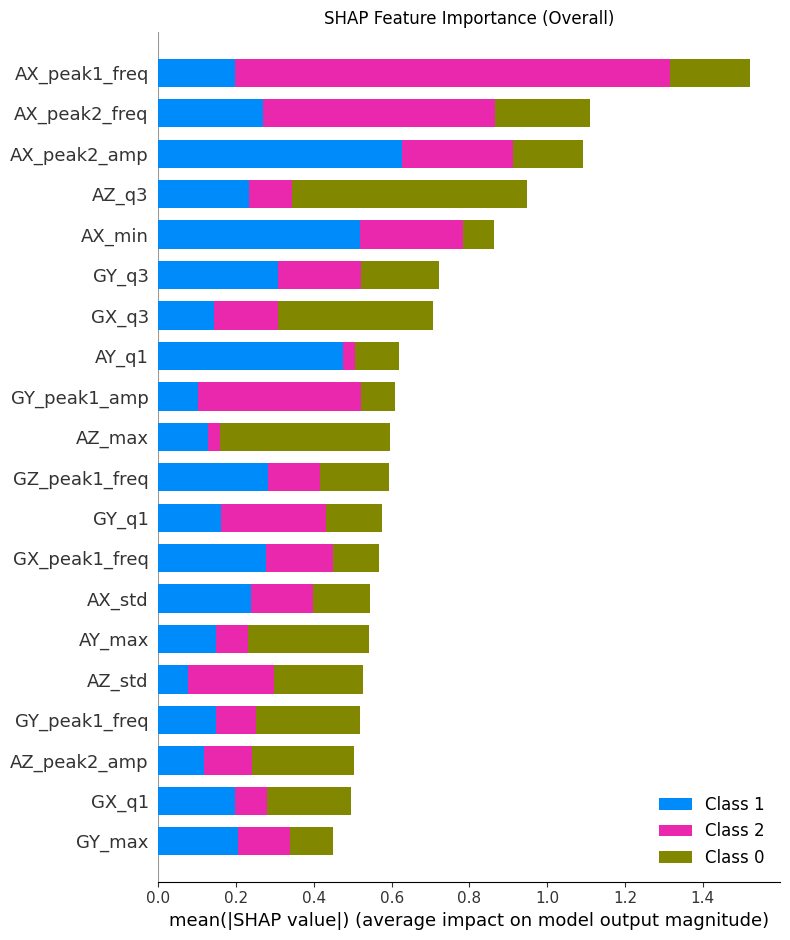

SHAP analysis completed.


In [19]:
# ====================== SHAP ANALYSIS ON BEST LIGHTGBM ======================
print("\n" + "="*80)
print("SHAP ANALYSIS (LightGBM with 3 classes)")
print("="*80)

final_lgb = joblib.load("/content/abdelatef_osama_best_lgb.pkl")
lgb_classifier = final_lgb.named_steps['clf']
X_sample = X.sample(n=min(200, len(X)), random_state=RANDOM_STATE)

explainer = shap.TreeExplainer(lgb_classifier)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_sample, plot_type="bar", show=False)
    plt.title("SHAP Feature Importance (Tremor class)")
    plt.tight_layout()
    plt.show()
else:
    shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
    plt.title("SHAP Feature Importance (Overall)")
    plt.tight_layout()
    plt.show()

print("SHAP analysis completed.")

# **Save Models**

In [ ]:
joblib.dump(best_lgb, "best_lgb.pkl")
joblib.dump(best_cat, "best_cat.pkl")
joblib.dump(best_xgb, "best_xgb.pkl")
joblib.dump(best_svm, "best_svm.pkl")
joblib.dump(best_rf, "best_rf.pkl")
joblib.dump(best_knn, "best_knn.pkl")
joblib.dump(best_mlp, "best_mlp.pkl")
joblib.dump(best_lstm, "best_lstm.pkl")
joblib.dump(best_tabnet, "best_tabnet.pkl")
best_model_cnn_lstm.save("best_cnn_lstm_3class.h5")
joblib.dump(best_gb, "best_gb.pkl")

['best_gb.pkl']

## Test function for 3-class model

This function will take raw sensor data, process it, and use the trained LightGBM model to predict whether the person has 'Non-Tremor', 'Tremor', or 'Voluntary' movement. It also performs SHAP analysis to show feature importance for the 'Tremor' class.

In [58]:
def test_tremor_model(sensor_data_raw, global_X_df, model_path="/content/abdelatef_osama_best_lgb.pkl"):
    import matplotlib.pyplot as plt
    cols = ["AX", "AY", "AZ", "GX", "GY", "GZ"]
    df = pd.DataFrame(sensor_data_raw, columns=cols).astype(float)

    # Apply scaling factors as per original notebook's data loading
    df[["AX", "AY", "AZ"]] = (df[["AX", "AY", "AZ"]] / 16384.0) * 9.81
    df[["GX", "GY", "GZ"]] = np.radians(df[["GX", "GY", "GZ"]] / 131.0)

    # Load the best LightGBM model
    model = joblib.load(model_path)

    results = []
    file_predictions = []
    all_features = []
    class_names = {0: "Non-Tremor", 1: "Tremor", 2: "Voluntary"}

    # Iterate through each sample, creating windows and extracting features
    for i in range(len(df)):
        start = max(0, i - 10)
        end = min(len(df), i + 20)
        window = df.iloc[start:end].copy()

        # Ensure a fixed window size (e.g., by repeating/padding if too small)
        if len(window) < WINDOW_SIZE:
            # Simple repetition to meet minimum size, or pad with zeros/mean
            repeat_count = (WINDOW_SIZE // len(window)) + 1
            window = pd.concat([window] * repeat_count, ignore_index=True)[:WINDOW_SIZE]

        try:
            # Extract features using the notebook's defined function
            features = extract_features(window)
            features_df = pd.DataFrame([features])

            # Handle NaN/Inf values, as done during training
            features_df = features_df.replace([np.inf, -np.inf], np.nan)
            features_df = features_df.fillna(0) # Or use a more sophisticated imputer if preferred

            # Reindex to ensure feature order and presence match the trained model
            # Use global_X_df.columns.tolist() as a robust fallback for feature names
            model_features = model.named_steps['clf'].feature_name_ if hasattr(model.named_steps['clf'], 'feature_name_') else global_X_df.columns.tolist()
            features_df = features_df.reindex(columns=model_features, fill_value=0.0)

            all_features.append(features_df)

            # Predict and get probabilities
            pred_class = model.predict(features_df)[0]
            proba = model.predict_proba(features_df)[0]

            # Get predicted label and confidence
            predicted_label = class_names.get(pred_class, "Unknown")
            confidence = proba[pred_class] * 100

            file_predictions.append(pred_class)

            results.append({
                "Sample": i,
                "Prediction": predicted_label,
                "Confidence %": round(confidence, 2),
                "Non-Tremor %": round(proba[0] * 100, 2),
                "Tremor %": round(proba[1] * 100, 2),
                "Voluntary %": round(proba[2] * 100, 2)
            })

        except Exception as e:
            print(f"Error at sample {i}: {e}")
            results.append({
                "Sample": i,
                "Prediction": "Error",
                "Confidence %": 0,
                "Non-Tremor %": 0,
                "Tremor %": 0,
                "Voluntary %": 0
            })

    # Determine final file-level prediction by majority voting
    if len(file_predictions) > 0:
        from collections import Counter
        final_pred_class = Counter(file_predictions).most_common(1)[0][0]
        final_label = class_names.get(final_pred_class, "Unknown")
    else:
        final_label = "Unknown"

    print("\n" + "="*25)
    print(f"FINAL FILE PREDICTION: {final_label}")
    print("="*25 + "\n")

    # SHAP Analysis
    # ==========================SHAP Analysis==========================
    shap_importance_df = pd.DataFrame()

    if len(all_features) > 0:
        try:
            full_features_df = pd.concat(all_features, ignore_index=True)
            full_features_df.columns = [str(c) for c in full_features_df.columns]
            real_model = model.named_steps["clf"]
            explainer = shap.TreeExplainer(real_model)
            shap_values = explainer.shap_values(full_features_df)

            # Define class names for SHAP plot for consistent labeling
            shap_class_names = [class_names[0], class_names[1], class_names[2]]

            # Plot SHAP summary for all classes with a stacked bar plot
            plt.figure(figsize=(12, 8)) # Increased figure size for better readability
            shap.summary_plot(shap_values, full_features_df, plot_type="bar", show=False,
                              class_names=shap_class_names)
            plt.title("SHAP Feature Importance (All Classes)")
            plt.tight_layout()
            plt.show()

            # Calculate overall feature importance for shap_importance_df
            # shap_values is a list of arrays, each (n_samples, n_features). Stack them.
            shap_values_stacked = np.stack(shap_values, axis=0) # Shape: (n_classes, n_samples, n_features)

            # Calculate mean absolute SHAP value for each feature, averaged across all samples and classes
            mean_shap_overall = np.mean(np.abs(shap_values_stacked), axis=(0, 1))

            feature_names = [str(c) for c in full_features_df.columns]

            shap_importance_df = pd.DataFrame({
                "feature": feature_names,
                "mean_shap": mean_shap_overall
            })

            shap_importance_df = (
                shap_importance_df
                .sort_values("mean_shap", ascending=False)
                .head(10) # Display top 10 overall features
                .reset_index(drop=True)
            )

            print("\nDEBUG SHAP")
            print("Shape:", shap_importance_df.shape)
            print(shap_importance_df.head())

            # Plot top 10 overall features based on mean absolute SHAP values
            plt.figure(figsize=(10, 6))
            sns.barplot(
                data=shap_importance_df,
                x="mean_shap",
                y="feature",
                palette='viridis' # Using a general palette for overall importance
            )
            plt.title("Top 10 Overall SHAP Feature Importance")
            plt.xlabel("Mean |SHAP| Value (Overall)")
            plt.ylabel("Feature")
            plt.tight_layout()
            plt.show()

            print("\n" + "="*25)
            print("TOP FILE-LEVEL FEATURES (Overall SHAP)")
            print("="*25)

        except Exception as e:
            print("\nSHAP ERROR:")
            print(e)
            print("\nFeature columns sample:")
            print(full_features_df.columns[:10])
            print("\nSHAP type:")
            print(type(shap_values))
            try:
                print("SHAP shape:", np.array(shap_values).shape)
            except:
                pass

    results_df = pd.DataFrame(results)
    return results_df, shap_importance_df


FINAL FILE PREDICTION: Non-Tremor



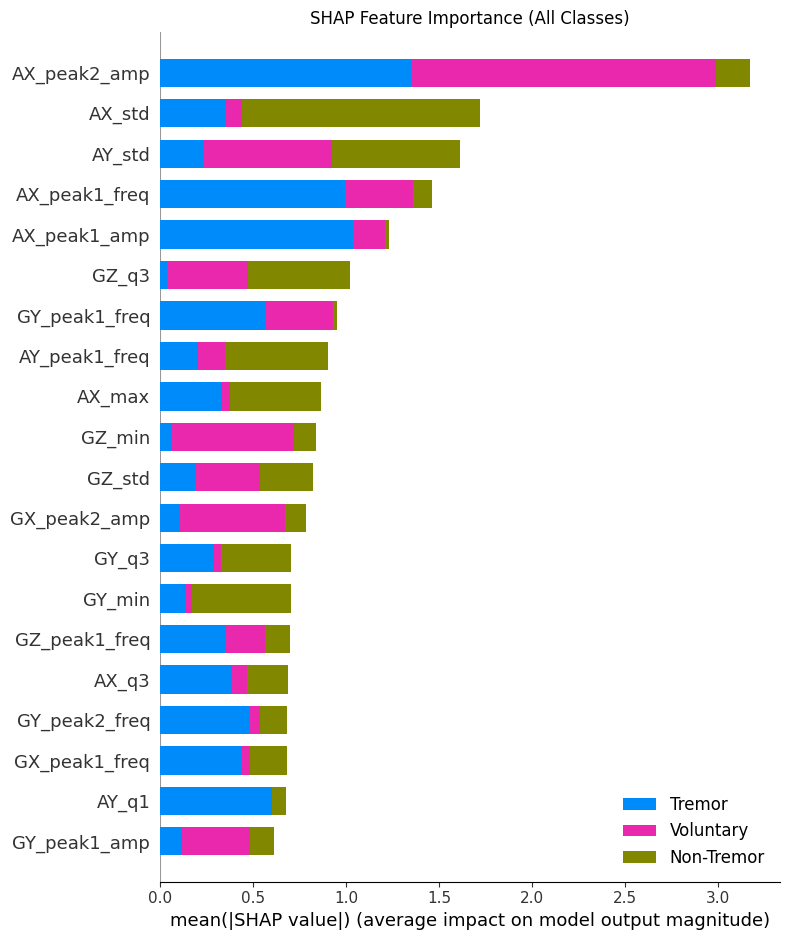


SHAP ERROR:
All arrays must be of the same length

Feature columns sample:
Index(['AX_mean', 'AX_std', 'AX_median', 'AX_q1', 'AX_q3', 'AX_min', 'AX_max',
       'AX_peak1_freq', 'AX_peak1_amp', 'AX_peak2_freq'],
      dtype='object')

SHAP type:
<class 'numpy.ndarray'>
SHAP shape: (6, 66, 3)


,Sample,Prediction,Confidence %,Non-Tremor %,Tremor %,Voluntary %
0,0,Non-Tremor,95.39,95.39,4.56,0.04
1,1,Non-Tremor,95.39,95.39,4.56,0.04
2,2,Non-Tremor,95.39,95.39,4.56,0.04
3,3,Non-Tremor,95.39,95.39,4.56,0.04
4,4,Non-Tremor,95.39,95.39,4.56,0.04
5,5,Non-Tremor,95.39,95.39,4.56,0.04


In [59]:
# Example sensor data (replace with your actual sensor data)
# Each row: AX, AY, AZ, GX, GY, GZ
sample_sensor_data = [
    [0.907402, -8.767567, 6.663063, -0.027446, 0.016787, -0.000533], # Non-tremor like
    [-4.924, -1.288, -11.940, -3.728, 10.504, -10.259], # Tremor like
    [-4.838682, -3.28245, -5.781997, -0.047564, 0.156014, 0.054492],
    [-4.249708, 0.186748, -6.698976, 0.012657, 0.057156, -0.022516],
    [-7.345411, 6.964733, 4.168305, 0.536789, -0.645505, 1.701629],
    [7.917625, 3.74932, -2.815581, -0.106985, 0.049562, -0.048363]
]

# Run the test function, passing the global X DataFrame
test_results_df, _ = test_tremor_model(sample_sensor_data, X)
display(test_results_df)


FINAL FILE PREDICTION: Tremor



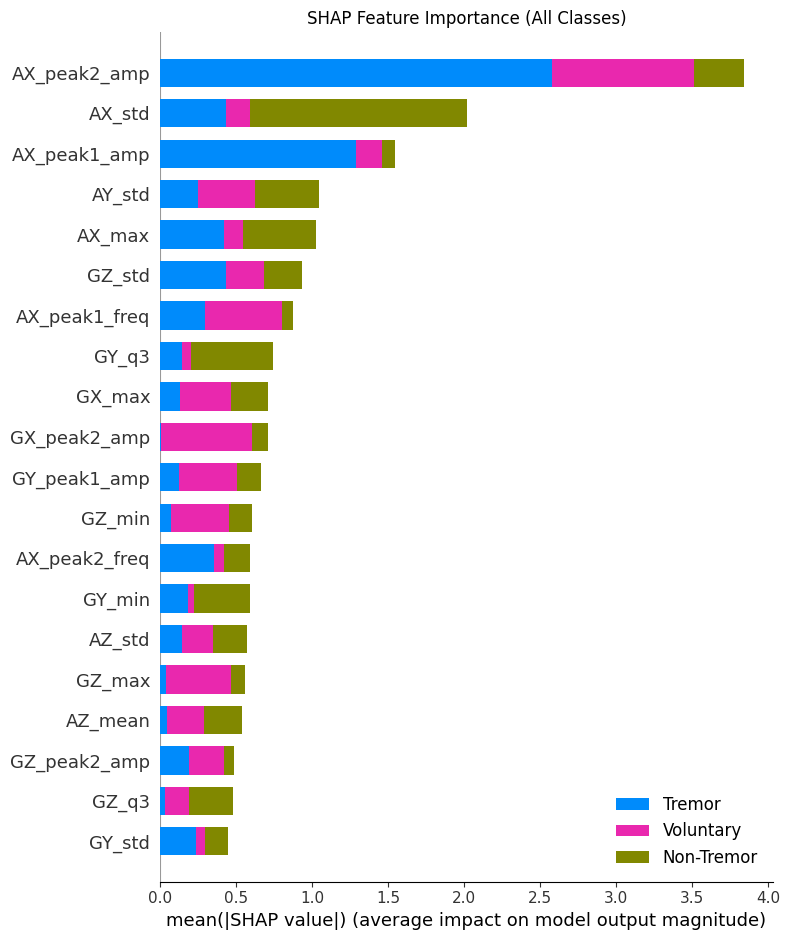


SHAP ERROR:
All arrays must be of the same length

Feature columns sample:
Index(['AX_mean', 'AX_std', 'AX_median', 'AX_q1', 'AX_q3', 'AX_min', 'AX_max',
       'AX_peak1_freq', 'AX_peak1_amp', 'AX_peak2_freq'],
      dtype='object')

SHAP type:
<class 'numpy.ndarray'>
SHAP shape: (25, 66, 3)


,Sample,Prediction,Confidence %,Non-Tremor %,Tremor %,Voluntary %
0,0,Tremor,99.33,0.67,99.33,0.00
1,1,Tremor,99.22,0.78,99.22,0.00
2,2,Tremor,97.96,2.03,97.96,0.00
3,3,Tremor,98.80,1.20,98.80,0.01
4,4,Tremor,99.46,0.54,99.46,0.00
5,5,Tremor,99.58,0.42,99.58,0.00
6,6,Tremor,99.58,0.42,99.58,0.00
7,7,Tremor,99.58,0.42,99.58,0.00
8,8,Tremor,99.58,0.42,99.58,0.00
9,9,Tremor,99.58,0.42,99.58,0.00


In [61]:
# Example sensor data (replace with your actual sensor data)
# Each row: AX, AY, AZ, GX, GY, GZ
sample_sensor_data = [
    [-1516.49, 176.93, 795.35, -8.5, -8.07, 1.31],
    [-1516.01, 176.93, 797.75, -8.63, -6.61, 1.25],
    [-1518.16, 175.49, 800.62, -8.69, -5.6, 1.12],
    [-1520.08, 174.78, 806.37, -8.23, -5.6, 0.93],
    [-1519.12, 176.45, 807.09, -8.34, -6.21, 0.69],
    [-1522.23, 177.65, 805.17, -7.46, -6.48, 0.51],
    [-1520.8, 180.52, 804.21, -7.41, -6.63, 0.64],
    [-1514.33, 180.52, 797.03, -7.27, -5.97, 0.51],
    [-1513.61, 179.33, 791.04, -7.01, -5.2, 0.51],
    [-1517.21, 179.09, 783.86, -7.35, -4.61, 0.67],
    [-1523.19, 179.57, 784.34, -7.19, -3.22, 0.69],
    [-1526.06, 180.76, 782.66, -7.73, -1.92, 0.93],
    [-1528.7, 178.13, 780.51, -8.15, -0.88, 0.96],
    [-1530.85, 179.33, 781.71, -8.42, -0.64, 0.93],
    [-1537.56, 175.97, 779.55, -8.95, -1.81, 0.88],
    [-1539.23, 174.3, 783.38, -8.93, -3.06, 1.09],
    [-1543.06, 171.66, 780.75, -9.51, -4.96, 1.36],
    [-1542.11, 171.19, 782.66, -9.46, -5.97, 1.41],
    [-1545.7, 168.55, 781.23, -9.91, -6.85, 1.57],
    [-1544.02, 167.35, 778.59, -10.02, -7.09, 1.6],
    [-1545.22, 167.59, 780.75, -9.78, -7.19, 1.6],
    [-1549.53, 168.31, 781.23, -10.1, -7.81, 1.65],
    [-1544.74, 168.79, 782.9, -9.99, -8.61, 1.79],
    [-1546.41, 170.71, 785.3, -9.54, -9.46, 1.97],
    [-1544.02, 171.19, 784.1, -9.54, -10.15, 2.0]
]

# Run the test function, passing the global X DataFrame
test_results_df, _ = test_tremor_model(sample_sensor_data, X)
display(test_results_df)


FINAL FILE PREDICTION: Tremor



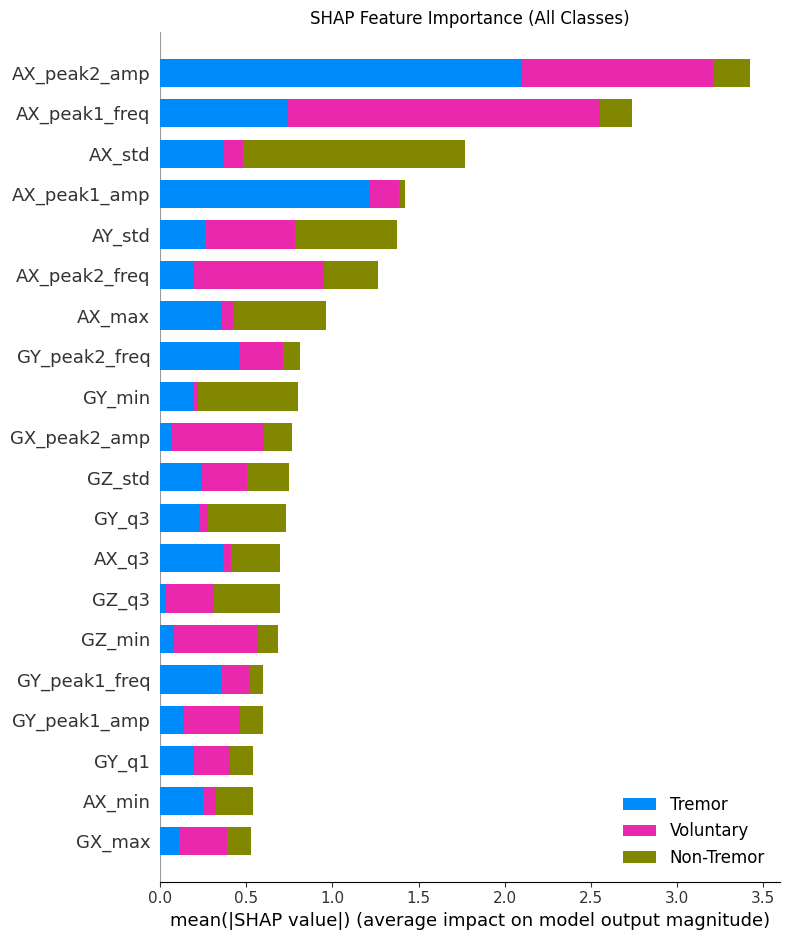


SHAP ERROR:
All arrays must be of the same length

Feature columns sample:
Index(['AX_mean', 'AX_std', 'AX_median', 'AX_q1', 'AX_q3', 'AX_min', 'AX_max',
       'AX_peak1_freq', 'AX_peak1_amp', 'AX_peak2_freq'],
      dtype='object')

SHAP type:
<class 'numpy.ndarray'>
SHAP shape: (46, 66, 3)


,Sample,Prediction,Confidence %,Non-Tremor %,Tremor %,Voluntary %
0,0,Tremor,58.86,40.88,58.86,0.26
1,1,Tremor,63.08,36.86,63.08,0.05
2,2,Tremor,72.61,27.34,72.61,0.06
3,3,Tremor,72.61,27.34,72.61,0.06
4,4,Tremor,56.84,43.09,56.84,0.07
5,5,Tremor,75.15,24.55,75.15,0.30
6,6,Tremor,58.36,41.52,58.36,0.11
7,7,Non-Tremor,64.04,64.04,35.70,0.26
8,8,Tremor,61.67,38.09,61.67,0.24
9,9,Tremor,62.93,36.65,62.93,0.42


In [62]:
# Example sensor data (replace with your actual sensor data)
# Each row: AX, AY, AZ, GX, GY, GZ
sample_sensor_data = [
#From Hamdy_read_save_3

    [-19.27, -3.96, 0.87, -0.31, 0.07, -0.07],
    [-19.61, -4.19, 0.96, 0.33, 0.08, 0.19],
    [-10.92, -2.7, 8.9, 0.78, 0.25, 0.07],
    [-10.64, -2.54, 6.82, 4.37, 2.76, 3.93],
    [-9.19, 4.42, 6.39, 0.46, 0.7, -0.45],
    [-16.77, 4.5, 6.33, 0.61, 1.12, -0.49],
    [-19.61, 1.3, 0.78, 0.06, -1.85, 0.94],
    [-19.47, 1.3, 1.65, 0.35, -0.34, 0.16],
    [-19.61, 1.92, 2.16, -0.13, -0.51, 0.19],
    [-19.34, 2.07, 2.77, 0.01, -0.15, 0.16],
    [-18.94, -0.84, -2.9, 0.35, -1.27, 0.97],
    [-19.61, -0.18, -1.58, 0.2, 1.12, -0.49],
    [-19.61, 0.05, -0.91, -0.14, 1.56, -0.8],
    [-18.47, -0.04, -1.59, -0.16, -2.32, 2.21],
    [-19.61, 2.55, 0.65, 0.02, -1.1, 0.79],
    [-19.61, -1.44, -0.87, -0.04, -0.41, 0.46],
    [-18.76, -0.67, -3.84, 0.05, 0.52, -0.34],
    [-19.61, -1.63, -3.92, 0.26, -0.07, 0.4],
    [-19.18, -1.98, -1.82, 0.39, 0.11, 0.24],
    [-17.51, 0.16, -1.09, -0.1, 0.59, -0.01],
    [-19.61, -2.35, -2.67, -0.11, -0.48, 0.1],
    [-19.61, -0.07, 2.07, 0.28, -1.16, 0.08],
    [-17.83, -1.89, 5.05, 0.37, 0.41, -0.11],
    [-19.61, 1.28, 2.4, -0.14, 0.11, 0.11],
    [-19.55, 2.52, 4.58, -0.36, -0.11, -0.02],
    [-13.14, 2.67, 10.74, -0.57, -0.17, 0.21],
    [-14.5, 3.99, 7.78, 0.54, -0.54, -0.67],
    [-18.98, 1.48, -3.45, -2.49, 0.93, -1.1],
    [-19.61, 2.92, -3.1, 0.14, -0.47, 0.01],
    [-16.06, 5.61, -2.1, 0.37, 0.82, -0.55],
    [-16.82, 7.06, -2.95, -0.99, -0.06, -1.01],
    [-18.57, 4.58, -3.6, 0.09, 0.17, -0.12],
    [-18.73, 5.19, -3.19, -1.16, -0.47, 0.56],
    [-19.61, 3.62, -0.66, -0.74, -0.55, -1.09],
    [-18.3, 3.21, 3.2, 1.08, 1.81, 0.66],
    [-19.57, 2.07, -0.47, -0.66, -0.97, 0.2],
    [-16.42, -0.78, -8.51, 0.47, -1.2, -0.3],
    [-19.33, 3.45, -2.36, -0.11, -0.05, -0.05],
    [-19.61, 1.81, -0.89, 0.46, -0.66, 0.43],
    [-14.68, 6.91, 4.1, -0.38, -0.27, -0.05],
    [-19.53, 1.32, -4.15, -0.05, 0.59, 0.24],
    [-19.61, 1.75, -2.4, -0.07, -0.3, -0.16],
    [-19.61, 0.32, -1.87, -0.27, 0.61, -0.06],
    [-19.46, -0.54, -4.34, -0.42, 0.79, -0.48],
    [-19.61, 1.34, -0.86, -0.16, 0.03, -0.07],
    [-19.61, 0.19, -3.77, 0.3, 0.36, 0.42]
]


# Run the test function, passing the global X DataFrame
test_results_df, _ = test_tremor_model(sample_sensor_data, X)
display(test_results_df)


FINAL FILE PREDICTION: Tremor



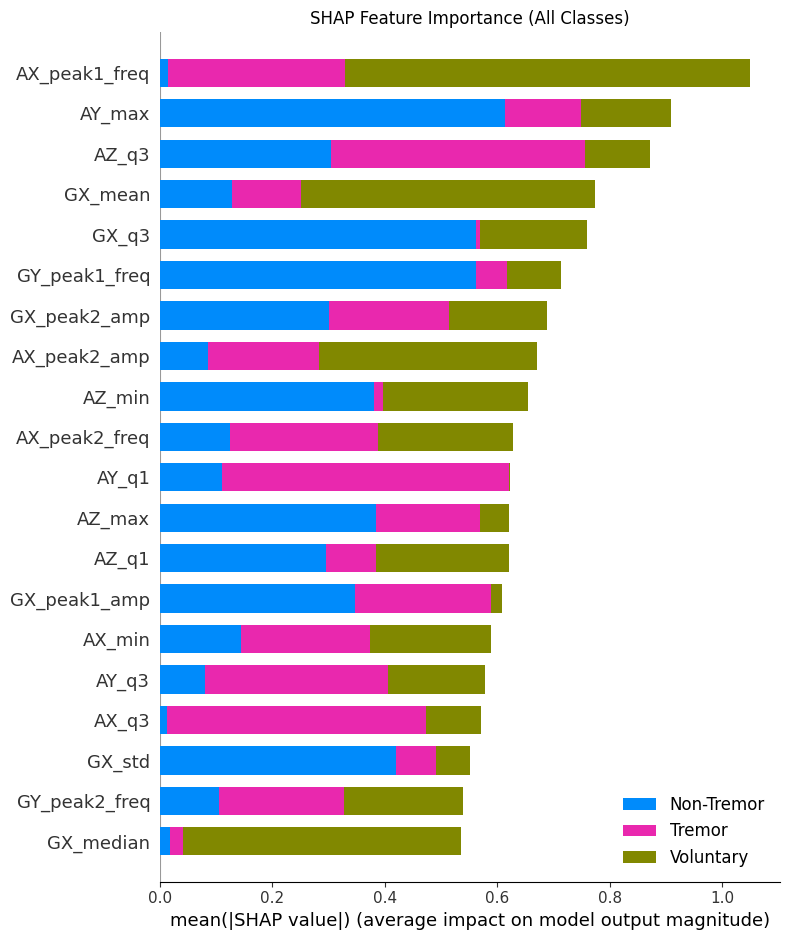


SHAP ERROR:
All arrays must be of the same length

Feature columns sample:
Index(['AX_mean', 'AX_std', 'AX_median', 'AX_q1', 'AX_q3', 'AX_min', 'AX_max',
       'AX_peak1_freq', 'AX_peak1_amp', 'AX_peak2_freq'],
      dtype='object')

SHAP type:
<class 'numpy.ndarray'>
SHAP shape: (19, 66, 3)


,Sample,Prediction,Confidence %,Non-Tremor %,Tremor %,Voluntary %
0,0,Tremor,84.60,14.23,84.60,1.17
1,1,Tremor,84.60,14.23,84.60,1.17
2,2,Tremor,84.60,14.23,84.60,1.17
3,3,Tremor,84.60,14.23,84.60,1.17
4,4,Tremor,84.60,14.23,84.60,1.17
5,5,Tremor,84.60,14.23,84.60,1.17
6,6,Tremor,84.60,14.23,84.60,1.17
7,7,Tremor,84.60,14.23,84.60,1.17
8,8,Tremor,84.60,14.23,84.60,1.17
9,9,Tremor,84.60,14.23,84.60,1.17


In [63]:
# Example sensor data (replace with your actual sensor data)
# Each row: AX, AY, AZ, GX, GY, GZ
sample_sensor_data = [
    [-2544, 14340, -6864, 3840, -335, -1518],
    [-2380, 14188, -5644, 3888, 1635, -9604],
    [-524, 14480, -7148, 3888, -1663, -1491],
    [-528, 15052, -6672, 3904, 461, -4012],
    [-2808, 14040, -5936, 3904, 595, -339],
    [152, 14872, -6996, 3936, 704, 984],
    [-636, 14988, -6836, 3936, 1622, -3290],
    [-716, 14388, -7040, 3952, 296, 179],
    [-2456, 14196, -7584, 3952, -960, -91],
    [-2008, 14092, -7136, 3952, -448, -321],
    [-1224, 14264, -6732, 3952, -1394, 2425],
    [1356, 11692, -11328, 3952, 48, 530],
    [-80, 14880, -7036, 3968, 1145, 3629],
    [-1524, 14348, -6936, 3968, 1421, -101],
    [-1784, 14440, -6996, 3968, -389, -341],
    [-1840, 14336, -7012, 3968, -834, 941],
    [-1940, 14320, -6380, 3968, -798, -113],
    [-672, 14648, -6540, 3968, 565, 3321],
    [-1832, 14900, -7552, 3968, 2363, -2584]
]

# Run the test function, passing the global X DataFrame
test_results_df, _ = test_tremor_model(sample_sensor_data, X)
display(test_results_df)


FINAL FILE PREDICTION: Non-Tremor



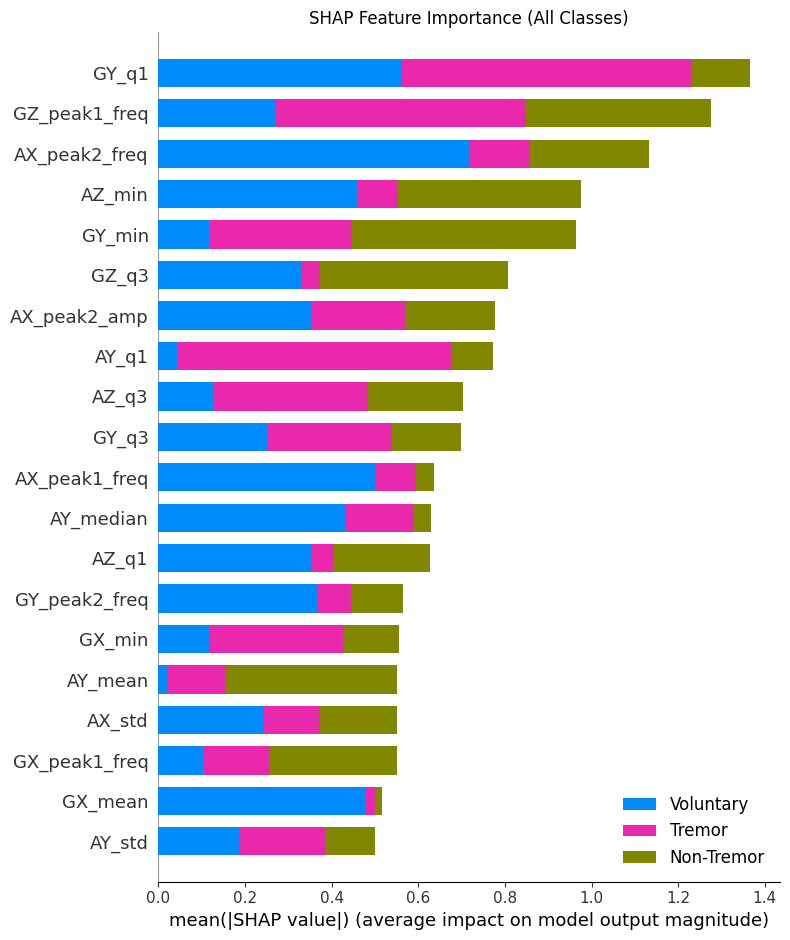


SHAP ERROR:
All arrays must be of the same length

Feature columns sample:
Index(['AX_mean', 'AX_std', 'AX_median', 'AX_q1', 'AX_q3', 'AX_min', 'AX_max',
       'AX_peak1_freq', 'AX_peak1_amp', 'AX_peak2_freq'],
      dtype='object')

SHAP type:
<class 'numpy.ndarray'>
SHAP shape: (25, 66, 3)


,Sample,Prediction,Confidence %,Non-Tremor %,Tremor %,Voluntary %
0,0,Tremor,51.97,47.74,51.97,0.29
1,1,Non-Tremor,83.84,83.84,15.39,0.78
2,2,Non-Tremor,93.79,93.79,6.10,0.11
3,3,Non-Tremor,81.99,81.99,17.05,0.97
4,4,Non-Tremor,69.10,69.10,29.91,0.99
5,5,Non-Tremor,54.67,54.67,44.41,0.92
6,6,Non-Tremor,54.67,54.67,44.41,0.92
7,7,Non-Tremor,54.67,54.67,44.41,0.92
8,8,Non-Tremor,54.67,54.67,44.41,0.92
9,9,Non-Tremor,54.67,54.67,44.41,0.92


In [65]:
# Example sensor data (replace with your actual sensor data)
# Each row: AX, AY, AZ, GX, GY, GZ
sample_sensor_data = [
    [-3176, -676, -17680, 663, 676, 32],
    [-2416, -412, -17820, 433, 1262, -1320],
    [-4820, 3500, -17464, 1420, 2962, -249],
    [-1280, -656, -17068, 3298, 2331, -1396],
    [-1456, -1332, -17520, -301, 800, -39],
    [-3960, 1716, -17416, 1350, 1476, -396],
    [-2088, -572, -17672, 2434, 1932, -1026],
    [-516, -1464, -17380, 1318, 1309, -616],
    [-4332, -368, -18744, 1541, 1420, -835],
    [-624, -1792, -17444, 635, 1921, -1003],
    [-2832, 64, -17576, 2728, 1843, -1433],
    [-856, -2576, -18212, 2300, 2485, -1310],
    [104, -1200, -16600, 704, 1783, -386],
    [-3028, -1672, -18984, 2666, 627, -1865],
    [-1240, -3108, -18132, 2867, 4557, 185],
    [2576, -3072, -16828, 92, 1364, -156],
    [-4352, 964, -17836, 8170, 6015, -1630],
    [1984, -6880, -16524, 5988, 5707, -853],
    [2880, -6468, -17300, 1021, 615, 61],
    [-644, -3220, -17608, 805, 1635, -656],
    [2024, -4884, -16820, 4363, 3968, -1148],
    [2292, -6732, -16872, 989, 640, -308],
    [216, -4868, -17440, 4507, 3409, -620],
    [2448, -7592, -17044, 740, 2639, 33],
    [2552, -4356, -16280, 481, 989, -473]
]

# Run the test function, passing the global X DataFrame
test_results_df, _ = test_tremor_model(sample_sensor_data, X)
display(test_results_df)


FINAL FILE PREDICTION: Non-Tremor



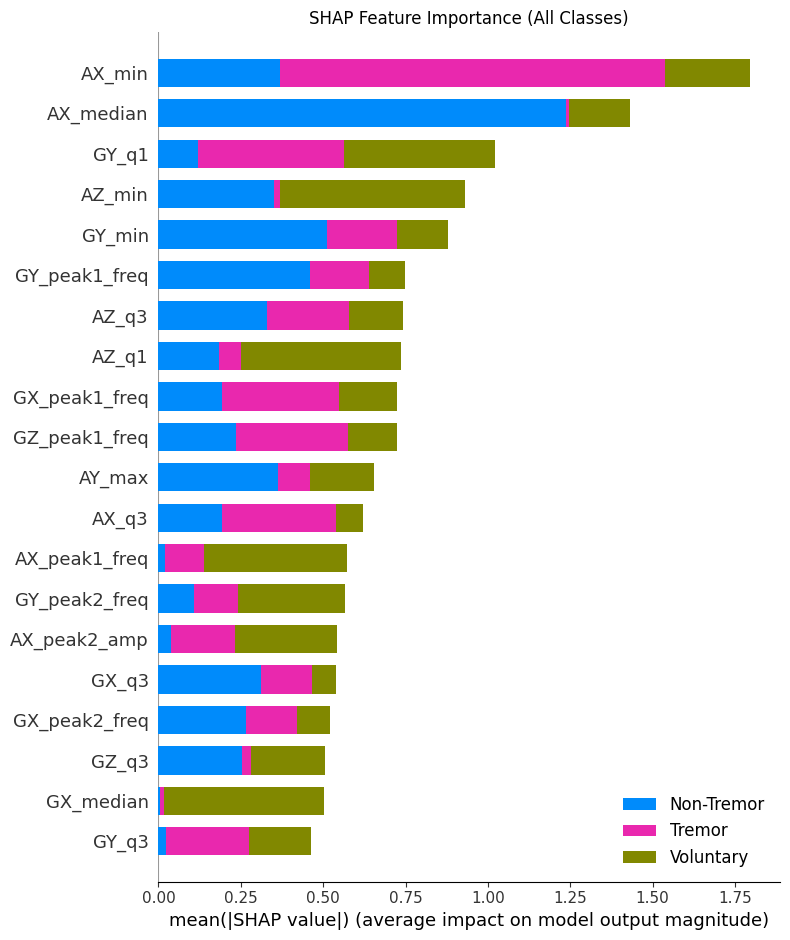


SHAP ERROR:
All arrays must be of the same length

Feature columns sample:
Index(['AX_mean', 'AX_std', 'AX_median', 'AX_q1', 'AX_q3', 'AX_min', 'AX_max',
       'AX_peak1_freq', 'AX_peak1_amp', 'AX_peak2_freq'],
      dtype='object')

SHAP type:
<class 'numpy.ndarray'>
SHAP shape: (26, 66, 3)


,Sample,Prediction,Confidence %,Non-Tremor %,Tremor %,Voluntary %
0,0,Non-Tremor,90.10,90.10,5.35,4.55
1,1,Non-Tremor,93.85,93.85,6.04,0.12
2,2,Non-Tremor,93.75,93.75,6.17,0.07
3,3,Non-Tremor,89.38,89.38,10.58,0.04
4,4,Non-Tremor,97.32,97.32,2.62,0.05
5,5,Non-Tremor,98.01,98.01,1.91,0.08
6,6,Non-Tremor,96.09,96.09,3.87,0.04
7,7,Non-Tremor,96.09,96.09,3.87,0.04
8,8,Non-Tremor,96.09,96.09,3.87,0.04
9,9,Non-Tremor,96.09,96.09,3.87,0.04


In [66]:
# Example sensor data (replace with your actual sensor data)
# Each row: AX, AY, AZ, GX, GY, GZ
sample_sensor_data = [
    [-7752, 11228, -8724, 234, 1091, 500],
    [-9720, 11880, -9060, 1387, 1432, -983],
    [-7148, 10852, -9412, 2897, 3085, -1482],
    [-8996, 11652, -9500, 2307, 2272, -30],
    [-7612, 10240, -10464, 4011, 3486, -1527],
    [-8460, 10732, -10584, 2671, 2239, -1556],
    [-7084, 9484, -11388, 3579, 2860, -1845],
    [-7240, 9424, -11272, 2809, 2280, -465],
    [-8508, 8732, -12132, 2722, 2337, -1717],
    [-7280, 9100, -12092, 1690, 2141, 109],
    [-7880, 9296, -12532, 2289, 2107, -1668],
    [-8032, 9088, -12788, 2938, 3078, -921],
    [-5460, 7480, -13136, 4150, 4109, -465],
    [-7772, 8364, -13684, 1817, 994, -2904],
    [-7632, 7760, -13540, 1489, 1543, -589],
    [-5704, 7296, -13660, 3345, 2525, -1497],
    [-8300, 8184, -13984, 2550, 2536, -1653],
    [-5380, 5872, -14500, 4162, 2611, -1542],
    [-7968, 6672, -15372, 3525, 2707, -1999],
    [-4556, 5340, -15056, 2699, 2625, -1501],
    [-7592, 6196, -15872, 3662, 2816, -1504],
    [-4792, 3948, -15792, 3373, 3712, -1426],
    [-5748, 5300, -15952, 2334, 2569, -1760],
    [-4124, 3916, -15804, 2850, 2617, -837],
    [-6116, 3648, -16800, 3943, 3538, -1496],
    [-4628, 3664, -16000, 902, 1604, -693]
]

# Run the test function, passing the global X DataFrame
test_results_df, _ = test_tremor_model(sample_sensor_data, X)
display(test_results_df)